In [107]:
# ============================================================
# 1. IMPORT LIBRARY
# Tujuan:
# - Menyiapkan library untuk membaca data,
#   analisis tren, visualisasi, dan clustering K-Modes.
# ============================================================

# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Install kmodes library if not already installed
!pip install kmodes

# Machine Learning - K-Modes
from kmodes.kmodes import KModes

# Evaluasi tambahan
from collections import Counter

# Menampilkan semua kolom dataframe tanpa terpotong
pd.set_option("display.max_columns", None)

# Menampilkan jumlah baris yang lebih mudah dibaca
pd.set_option("display.max_rows", 100)

print("Library berhasil di-import.")

Library berhasil di-import.


In [108]:
# ============================================================
# 2. LOAD DATASET
# Tujuan:
# - Menghubungkan Google Colab dengan Google Drive
# - Membaca file Excel dari folder DATA PKL
# - Melihat nama sheet yang tersedia
# - Memastikan file berhasil dibaca
# ============================================================

# Menghubungkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path file Excel di Google Drive
file_path = "/content/drive/MyDrive/DATA PKL/MONITORING TJSL UIW NTB.xlsx"

# Membaca seluruh sheet Excel
excel_file = pd.ExcelFile(file_path)

# Menampilkan nama seluruh sheet
print("Daftar sheet:")
for i, sheet in enumerate(excel_file.sheet_names, start=1):
    print(f"{i}. {sheet}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Daftar sheet:
1. DATABASE UTAMA
2. Penagihan
3. Piutang Bermasalah
4. Hapus Tagih
5. Progres PUMK Unit
6. Hapus Buku
7. EVP
8. Pelatihan
9. Mitra untuk Dilunasi
10. Piutang Bermasalah-Form D
11. Copy of DATABASE UTAMA
12. Monitoring Program


In [109]:
# ============================================================
# 3. LOAD DATABASE UTAMA
# Tujuan:
# - Mengambil sheet yang berisi data utama mitra binaan
# - Mengetahui jumlah observasi dan kolom yang tersedia
# ============================================================

df = pd.read_excel(
    file_path,
    sheet_name="DATABASE UTAMA"
)

print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")

print("\nNama kolom:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Jumlah baris   : 510
Jumlah kolom   : 47

Nama kolom:
1. NO URUT
2. NO ID
3. NAMA MITRA BINAAN
4. KONDITE
5. NAMA USAHA
6. ALAMAT
7. LOKASI
8. NO TELEPON
9. JENIS USAHA
10. TAHUN SALUR
11. TITIK KOORDINAT
12. PINJAMAN 
13. Unnamed: 12
14. UNIT
15. NOMER VIRTUAL ACCOUNT
16. LINK DOKUMEN PKS
17. PELUNASAN
18. Unnamed: 17
19. Unnamed: 18
20. Unnamed: 19
21. Unnamed: 20
22. Unnamed: 21
23. Unnamed: 22
24. USULAN MUTASI PIUTANG BERMASALAH
25. Unnamed: 24
26. Unnamed: 25
27. Unnamed: 26
28. Unnamed: 27
29. Unnamed: 28
30. Unnamed: 29
31. Unnamed: 30
32. Unnamed: 31
33. Unnamed: 32
34. Unnamed: 33
35. Unnamed: 34
36. USULAN HAPUS BUKU
37. Unnamed: 36
38. Unnamed: 37
39. Unnamed: 38
40. Unnamed: 39
41. USULAN HAPUS TAGIH
42. Unnamed: 41
43. Unnamed: 42
44. Unnamed: 43
45. Unnamed: 44
46. STATUS AKHIR MITRA BINAAN
47. CETAK


In [110]:
# ============================================================
# CEK STRUKTUR HEADER ASLI EXCEL
# Tujuan:
# Melihat beberapa baris pertama Excel tanpa menetapkan
# baris tertentu sebagai header.
# ============================================================

df_raw = pd.read_excel( # Membaca file Excel dan menyimpannya ke dalam DataFrame pandas
    file_path,        # Variabel yang berisi jalur/path lokasi file Excel
    sheet_name="DATABASE UTAMA", # Nama sheet spesifik di Excel yang ingin dibaca
    header=None       # Mengatur agar baris pertama tidak otomatis dijadikan header/nama kolom
)

print("Ukuran data mentah:", df_raw.shape) # Mencetak dimensi (jumlah baris dan kolom) dari data mentah

# Tampilkan 6 baris pertama dan 20 kolom pertama
display(df_raw.iloc[:6, :20]) # Menampilkan 6 baris pertama dan 20 kolom pertama menggunakan indeks integer (.iloc)

Ukuran data mentah: (511, 47)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NO URUT,NO ID,NAMA MITRA BINAAN,KONDITE,NAMA USAHA,ALAMAT,LOKASI,NO TELEPON,JENIS USAHA,TAHUN SALUR,TITIK KOORDINAT,PINJAMAN,NaN,UNIT,NOMER VIRTUAL ACCOUNT,LINK DOKUMEN PKS,PELUNASAN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POKOK,JASA,NaN,NaN,NaN,ANGSURAN POKOK,ANGSURAN JASA,SALDO POKOK,SALDO JASA
2,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
3,1,20-03-023/94,MEBEL YUDHA PUTRA,Normal,MEBEL YUDHA PUTRA,DESA RONTU BIMA,BIMA,NaN,Sektor Industri,1994,NaN,5000000,200000,UP3 BIMA,9880075320031201,NaN,1250000,50000,3750000,150000
4,2,20-03-059/95,MEUBEL KAYU LESTARI,Normal,MEUBEL KAYU LESTARI,KEL NAE RT05/02 BIMA,BIMA,NaN,Sektor Industri,1995,NaN,5000000,200000,UP3 BIMA,9880075320031202,NaN,0,0,5000000,200000
5,3,20-03-060/95,MEUBEL KAYU RANGGA PUTRA,Normal,MEUBEL KAYU RANGGA PUTRA,DESA JATIBARU,BIMA,NaN,Sektor Industri,1995,NaN,5000000,200000,UP3 BIMA,9880075320031203,NaN,0,0,5000000,200000


In [111]:
# ============================================================
# 4. AUDIT FITUR PENELITIAN
# Tujuan:
# - Memastikan fitur yang akan digunakan memang tersedia
# - Memeriksa tipe data
# - Memeriksa jumlah data kosong
# - Tidak memasukkan data sensitif ke dalam model
# ============================================================

# Kandidat fitur untuk penelitian
candidate_features = [ # Mendefinisikan list nama kolom yang ingin diuji keberadaannya
    "NAMA USAHA",  # Kolom pertama yang ingin diuji (nama usaha)
    "JENIS USAHA", # Kolom kedua yang ingin diuji (jenis usaha)
    "TAHUN SALUR", # Kolom ketiga yang ingin diuji (tahun salur)
    "UNIT",        # Kolom keempat yang ingin diuji (unit)
    "LOKASI"       # Kolom kelima yang ingin diuji (lokasi)
]                  # Menutup list candidate_features

# Mengecek keberadaan setiap kolom
print("Pemeriksaan kolom:\n") # Mencetak teks judul untuk proses pengecekan kolom

for col in candidate_features: # Melakukan perulangan untuk mengecek setiap nama kolom di dalam list
    if col in df.columns:    # Mengecek apakah kolom tersebut benar-benar ada di dalam DataFrame df
        print(f"✓ {col}")    # Jika ada, cetak tanda centang dan nama kolomnya
    else:                    # Jika kolom tidak ditemukan di dalam DataFrame df
        print(f"✗ {col} --> TIDAK DITEMUKAN") # Jika tidak ada, cetak tanda silang dan status tidak ditemukan

# Membuat ringkasan karakteristik kolom
available_features = [ # Membuat list baru untuk menampung kolom yang benar-benar tersedia
    col for col in candidate_features # Mengambil setiap kolom dari list kandidat
    if col in df.columns # Dengan syarat kolom tersebut ada di dalam DataFrame df
]                      # Menutup list available_features

audit = pd.DataFrame({ # Membuat DataFrame baru bernama audit untuk tabel ringkasan
    "Kolom": available_features, # Kolom tabel berisi daftar nama fitur yang tersedia
    "Tipe Data": [df[col].dtype for col in available_features], # Kolom tabel berisi tipe data dari setiap fitur
    "Jumlah Data": [df[col].notna().sum() for col in available_features], # Kolom tabel berisi jumlah baris data yang terisi (tidak kosong)
    "Missing": [df[col].isna().sum() for col in available_features], # Kolom tabel berisi jumlah data yang kosong (missing values)
    "Jumlah Unik": [df[col].nunique(dropna=True) for col in available_features] # Kolom tabel berisi jumlah data unik (berbeda) tanpa menghitung nilai kosong
})                     # Menutup dictionary dan fungsi pd.DataFrame

display(audit) # Menampilkan tabel hasil ringkasan audit ke layar

Pemeriksaan kolom:

✓ NAMA USAHA
✓ JENIS USAHA
✓ TAHUN SALUR
✓ UNIT
✓ LOKASI


,Kolom,Tipe Data,Jumlah Data,Missing,Jumlah Unik
0,NAMA USAHA,object,509,1,501
1,JENIS USAHA,object,509,1,11
2,TAHUN SALUR,float64,509,1,23
3,UNIT,object,509,1,10
4,LOKASI,object,509,1,10


In [112]:
# ============================================================
# 5. PREVIEW DATA
# Tujuan:
# - Memastikan isi setiap fitur sesuai dengan yang diharapkan
# - Mendeteksi secara awal masalah penulisan kategori
# ============================================================

display(                      # Menampilkan output ke layar
    df[available_features].head(10) # Mengambil 10 baris pertama khusus dari kolom-kolom yang tersedia
)

,NAMA USAHA,JENIS USAHA,TAHUN SALUR,UNIT,LOKASI
0,NaN,NaN,NaN,NaN,NaN
1,5,9,10.0,14,7
2,MEBEL YUDHA PUTRA,Sektor Industri,1994.0,UP3 BIMA,BIMA
3,MEUBEL KAYU LESTARI,Sektor Industri,1995.0,UP3 BIMA,BIMA
4,MEUBEL KAYU RANGGA PUTRA,Sektor Industri,1995.0,UP3 BIMA,BIMA
5,MEUBEL KAYU SUMBER REJEKI,Sektor Industri,1995.0,UP3 BIMA,BIMA
6,UPPKS TENUN MELATI,Sektor Industri,1995.0,UP3 BIMA,BIMA
7,MEBEL SERBA JADI,Sektor Industri,1996.0,UP3 BIMA,BIMA
8,GENTENG MUNCUL BARU,Sektor Industri,1996.0,UP3 BIMA,BIMA
9,MEBEL KARYA UTAMA,Sektor Industri,1996.0,UP3 BIMA,BIMA


In [113]:
# ============================================================
# 6. AUDIT KATEGORI
# Tujuan:
# - Melihat variasi nilai pada fitur kategorikal
# - Mendeteksi perbedaan penulisan seperti:
#   "LOMBOK BARAT" vs "Lombok Barat"
# - Menjadi dasar tahap standardisasi berikutnya
# ============================================================

categorical_features = [      # Mendefinisikan list penampung khusus fitur yang bersifat kategorikal
    col for col in [          # Melakukan seleksi untuk setiap kolom di dalam daftar berikut
        "JENIS USAHA",        # Kolom kategori jenis usaha
        "LOKASI",             # Kolom kategori lokasi
        "UNIT"                # Kolom kategori unit
    ]                         # Menutup daftar kandidat kolom kategorikal
    if col in df.columns      # Hanya ambil kolom jika benar-benar ada di dalam DataFrame df
]                             # Menutup list categorical_features

for col in categorical_features: # Melakukan perulangan untuk setiap kolom kategorikal yang tersedia
    print("\n" + "=" * 70)    # Mencetak garis pemisah untuk kerapian tampilan teks
    print(f"KOLOM: {col}")    # Mencetak nama kolom yang sedang diproses saat ini
    print("=" * 70)           # Mencetak garis pemisah penutup judul kolom

    print(                    # Mencetak hasil perhitungan frekuensi data ke layar
        df[col]               # Mengambil data dari kolom spesifik yang sedang diulang
        .value_counts(dropna=False) # Menghitung jumlah kemunculan setiap nilai unik, termasuk nilai kosong (NaN)
    )                         # Menutup fungsi print


KOLOM: JENIS USAHA
JENIS USAHA
Sektor Jasa           175
Sektor Perdagangan    143
Sektor Pertanian      103
Sektor Industri        78
Sektor Perikanan        3
Sektor Peternakan       2
NaN                     1
9                       1
Sektor Perkebunan       1
sektor perdagangan      1
sektor industri         1
sektor pertanian        1
Name: count, dtype: int64

KOLOM: LOKASI
LOKASI
KOTA BIMA        106
KOTA MATARAM      76
SUMBAWA           62
LOMBOK BARAT      58
BIMA              54
LOMBOK TENGAH     52
LOMBOK TIMUR      48
DOMPU             37
LOMBOK UTARA      15
7                  1
NaN                1
Name: count, dtype: int64

KOLOM: UNIT
UNIT
UP3 BIMA       105
UPK TAMBORA     92
UP3 MATARAM     64
UPK LOMBOK      63
UP3 SUMBAWA     62
UPT MATARAM     52
UP2D NTB        30
UP2B NTB        30
UP2K NTB        10
14               1
NaN              1
Name: count, dtype: int64


In [114]:
# ============================================================
# 7. AUDIT TAHUN SALUR
# Tujuan:
# - Melihat distribusi tahun salur
# - Memastikan rentang tahun
# - Mengetahui tahun yang memiliki data
# - Menjadi dasar analisis tren
# ============================================================

if "TAHUN SALUR" in df.columns: # Mengecek apakah kolom "TAHUN SALUR" benar-benar ada di dalam DataFrame df

    # Konversi sementara ke numerik.
    # Nilai yang tidak dapat dikonversi akan menjadi NaN.
    year_numeric = pd.to_numeric( # Mengonversi kolom TAHUN SALUR menjadi tipe data angka/numerik
        df["TAHUN SALUR"],        # Kolom TAHUN SALUR yang akan dikonversi nilainya
        errors="coerce"         # Mengubah nilai yang gagal dikonversi menjadi NaN (Not a Number) agar tidak error
    )                             # Menutup fungsi pd.to_numeric

    print(f"Tahun minimum : {year_numeric.min()}") # Mencetak nilai tahun paling awal/kecil
    print(f"Tahun maksimum : {year_numeric.max()}") # Mencetak nilai tahun paling akhir/besar

    print("\nJumlah mitra per tahun:") # Mencetak teks judul untuk daftar jumlah mitra tiap tahun
    year_counts = (                 # Menyimpan hasil perhitungan jumlah mitra per tahun ke variabel year_counts
        year_numeric              # Menggunakan data numerik tahun salur
        .value_counts()           # Menghitung frekuensi kemunculan setiap tahun
        .sort_index()             # Mengurutkan hasil berdasarkan urutan tahun (indeks terkecil ke terbesar)
    )                             # Menutup variabel year_counts

    display(                      # Menampilkan hasil akhir ke layar
        year_counts.rename("Jumlah Mitra").to_frame() # Mengubah Seri data menjadi DataFrame dengan mengubah nama kolom menjadi "Jumlah Mitra"
    )                             # Menutup fungsi display

Tahun minimum : 10.0
Tahun maksimum : 2020.0

Jumlah mitra per tahun:


,Jumlah Mitra
TAHUN SALUR,
10.0,1
1993.0,8
1994.0,26
1995.0,35
1996.0,162
1997.0,54
1998.0,48
1999.0,22
2000.0,21


In [115]:
# ============================================================
# 8. CLEANING STRUKTUR DATA
# Tujuan:
# - Menghapus baris kosong di awal
# - Menghapus baris nomor/kode kolom yang bukan data mitra
# - Mereset index
# - Mengubah TAHUN SALUR menjadi integer
# ============================================================

# Mengambil hanya baris data mitra
df_clean = df.iloc[2:].copy() # Memotong DataFrame dengan mengambil baris dari indeks ke-2 sampai akhir, lalu menduplikatnya ke variabel baru

# Mereset index agar kembali dari 0
df_clean.reset_index(drop=True, inplace=True) # Mengatur ulang nomor indeks baris DataFrame agar urut dari 0 kembali dan menghapus indeks lama

# Mengubah TAHUN SALUR menjadi numerik
df_clean["TAHUN SALUR"] = pd.to_numeric( # Mengonversi kolom TAHUN SALUR menjadi tipe data angka
    df_clean["TAHUN SALUR"],        # Kolom TAHUN SALUR yang akan dikonversi di dalam df_clean
    errors="coerce"                 # Mengubah nilai yang gagal dikonversi menjadi NaN agar tidak terjadi error
)                                     # Menutup fungsi pd.to_numeric

# Karena tahun berupa bilangan bulat, gunakan nullable integer
df_clean["TAHUN SALUR"] = df_clean["TAHUN SALUR"].astype("Int64") # Mengubah tipe data kolom TAHUN SALUR menjadi integer yang mendukung nilai kosong (NaN)

print("Jumlah baris setelah cleaning :", len(df_clean)) # Mencetak informasi total baris data yang tersisa setelah proses pembersihan
print("Jumlah kolom                 :", df_clean.shape[1]) # Mencetak informasi total kolom yang ada pada DataFrame bersih

display(df_clean[available_features].head(10)) # Menampilkan 10 baris pertama dari kolom-kolom yang tersedia pada data yang sudah dibersihkan

Jumlah baris setelah cleaning : 508
Jumlah kolom                 : 47


,NAMA USAHA,JENIS USAHA,TAHUN SALUR,UNIT,LOKASI
0,MEBEL YUDHA PUTRA,Sektor Industri,1994,UP3 BIMA,BIMA
1,MEUBEL KAYU LESTARI,Sektor Industri,1995,UP3 BIMA,BIMA
2,MEUBEL KAYU RANGGA PUTRA,Sektor Industri,1995,UP3 BIMA,BIMA
3,MEUBEL KAYU SUMBER REJEKI,Sektor Industri,1995,UP3 BIMA,BIMA
4,UPPKS TENUN MELATI,Sektor Industri,1995,UP3 BIMA,BIMA
5,MEBEL SERBA JADI,Sektor Industri,1996,UP3 BIMA,BIMA
6,GENTENG MUNCUL BARU,Sektor Industri,1996,UP3 BIMA,BIMA
7,MEBEL KARYA UTAMA,Sektor Industri,1996,UP3 BIMA,BIMA
8,TENUN BINTANG,Sektor Industri,1996,UP3 BIMA,BIMA
9,MEBEL ANINUP,Sektor Industri,1996,UP3 BIMA,BIMA


In [116]:
# ============================================================
# 9. VALIDASI DATA MITRA
# Tujuan:
# Memastikan dataset setelah cleaning benar-benar berisi
# 508 mitra dan tidak lagi mengandung baris metadata Excel.
# ============================================================

print("Jumlah observasi :", len(df_clean)) # Mencetak total jumlah baris/observasi data yang ada di dalam df_clean
print("Jumlah missing per kolom:\n") # Mencetak teks judul untuk informasi jumlah data kosong pada tiap kolom

display(                      # Memulai fungsi untuk menampilkan tabel ke layar
    df_clean[available_features].isna().sum().to_frame("Missing") # Menghitung total nilai kosong (NaN) di setiap kolom fitur, lalu mengubahnya menjadi DataFrame dengan nama kolom "Missing"
)                             # Menutup fungsi display

print("\nJumlah nilai unik:") # Mencetak teks judul untuk informasi jumlah nilai unik tiap kolom
display(                      # Memulai fungsi untuk menampilkan tabel jumlah nilai unik ke layar
    df_clean[available_features].nunique(dropna=True).to_frame("Unique") # Menghitung jumlah nilai unik (berbeda) pada setiap kolom fitur (tanpa menghitung nilai kosong), lalu mengubahnya menjadi DataFrame dengan nama kolom "Unique"
)                             # Menutup fungsi display

Jumlah observasi : 508
Jumlah missing per kolom:



,Missing
NAMA USAHA,0
JENIS USAHA,0
TAHUN SALUR,0
UNIT,0
LOKASI,0



Jumlah nilai unik:


,Unique
NAMA USAHA,500
JENIS USAHA,10
TAHUN SALUR,22
UNIT,9
LOKASI,9


In [117]:
# ============================================================
# 10. ANALISIS TREN JUMLAH MITRA PER TAHUN
# Tujuan:
# - Menghitung jumlah mitra pada setiap tahun salur
# - Menyusun data time-based untuk analisis tren
# - Menampilkan tabel distribusi jumlah mitra per tahun
# ============================================================

# Menghitung jumlah mitra berdasarkan tahun salur
trend_tahunan = (               # Menyimpan hasil pengolahan data tren tahunan ke dalam variabel baru
    df_clean                  # Menggunakan DataFrame yang sudah dibersihkan
    .groupby("TAHUN SALUR")   # Mengelompokkan data berdasarkan nilai pada kolom "TAHUN SALUR"
    .size()                   # Menghitung jumlah baris (frekuensi) untuk setiap kelompok tahun
    .reset_index(name="JUMLAH MITRA") # Mengubah hasil grouping kembali menjadi DataFrame dan memberi nama kolom hasil hitung menjadi "JUMLAH MITRA"
    .sort_values("TAHUN SALUR") # Mengurutkan baris DataFrame berdasarkan kolom "TAHUN SALUR" secara ascending (terkecil ke terbesar)
)                             # Menutup proses rantai perintah (method chaining)

# Menampilkan hasil
display(trend_tahunan)        # Menampilkan tabel hasil analisis tren tahunan ke layar

,TAHUN SALUR,JUMLAH MITRA
0,1993,8
1,1994,26
2,1995,35
3,1996,162
4,1997,54
5,1998,48
6,1999,22
7,2000,21
8,2001,8
9,2002,4


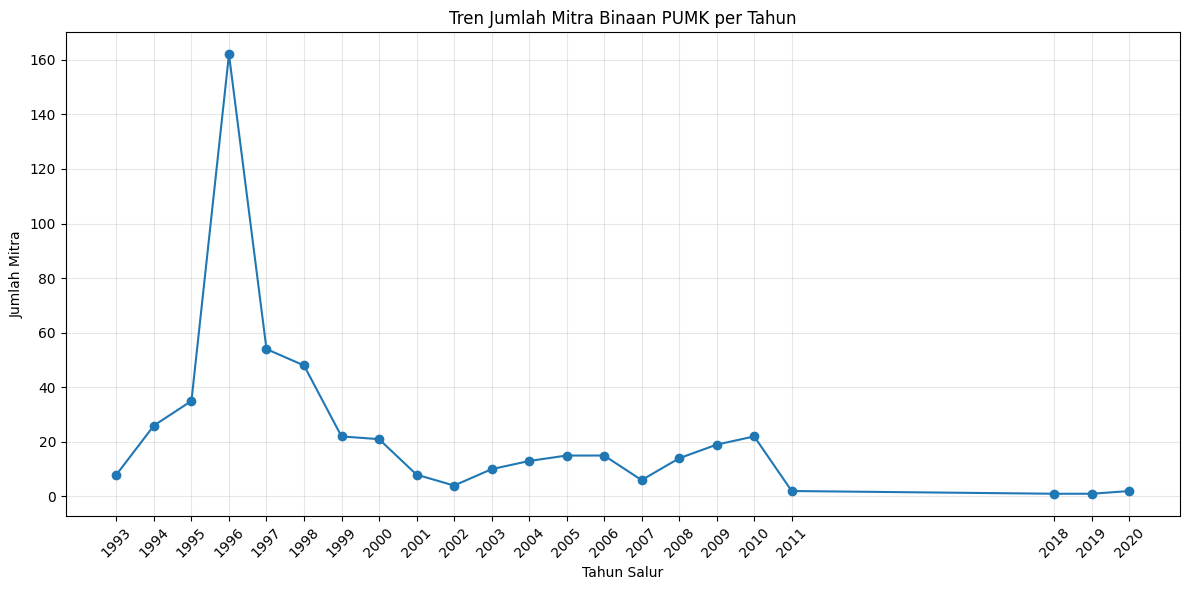

In [118]:
# ============================================================
# 11. VISUALISASI TREN JUMLAH MITRA PER TAHUN
# Tujuan:
# - Melihat pola perkembangan jumlah mitra secara visual
# - Mengidentifikasi lonjakan atau penurunan pada periode tertentu
# ============================================================

plt.figure(figsize=(12, 6)) # Membuat kanvas gambar grafik baru dengan ukuran lebar 12 inci dan tinggi 6 inci

plt.plot(                  # Membuat grafik garis (line plot)
    trend_tahunan["TAHUN SALUR"], # Nilai yang diletakkan pada sumbu X (tahun salur)
    trend_tahunan["JUMLAH MITRA"], # Nilai yang diletakkan pada sumbu Y (jumlah mitra)
    marker="o"          # Menambahkan tanda titik (marker) berbentuk lingkaran di setiap titik data pada garis
)

plt.title("Tren Jumlah Mitra Binaan PUMK per Tahun") # Memberikan judul utama pada grafik
plt.xlabel("Tahun Salur") # Memberikan label keterangan pada sumbu X
plt.ylabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu Y
plt.xticks(                # Mengatur label angka/teks yang muncul pada sumbu X
    trend_tahunan["TAHUN SALUR"], # Menyesuaikan posisi titik tick sumbu X berdasarkan data tahun salur
    rotation=45         # Memutar teks label sumbu X sebesar 45 derajat agar lebih mudah dibaca
)

plt.grid(True, alpha=0.3) # Menampilkan garis latar belakang (grid) dengan tingkat transparansi 0.3
plt.tight_layout()        # Menyesuaikan tata letak elemen grafik agar tidak terpotong atau tumpang tindih
plt.show()                # Menampilkan dan merender grafik ke layar

In [119]:
# ============================================================
# 12. STANDARDISASI SEKTOR/JENIS USAHA
# Tujuan:
# - Menyamakan penulisan kategori sektor usaha
# - Menghilangkan spasi berlebih
# - Menyamakan kapitalisasi
# - Membuat kategori yang sama tidak terbaca sebagai kategori berbeda
# ============================================================

# Membersihkan kolom JENIS USAHA
df_clean["SEKTOR_ANALISIS"] = ( # Membuat atau menimpa kolom baru bernama "SEKTOR_ANALISIS" di dalam DataFrame df_clean
    df_clean["JENIS USAHA"]   # Mengambil data dari kolom asli "JENIS USAHA"
    .astype("string")         # Mengonversi seluruh tipe data nilai pada kolom tersebut menjadi string pandas
    .str.strip()              # Menghapus spasi kosong yang berlebih di awal dan akhir teks
    .str.replace(r"\s+", " ", regex=True) # Mengganti spasi ganda atau lebih di tengah teks menjadi satu spasi tunggal menggunakan regex
    .str.title()              # Mengubah format huruf kapital di setiap awal kata (Title Case)
)                             # Menutup proses rantai perintah (method chaining)

# Melihat hasil standardisasi
print("Kategori sektor setelah standardisasi:") # Mencetak teks judul informasi hasil standardisasi ke layar
display(                      # Memulai fungsi untuk menampilkan tabel hasil ke layar
    df_clean["SEKTOR_ANALISIS"] # Mengambil data dari kolom baru "SEKTOR_ANALISIS"
    .value_counts(dropna=False) # Menghitung jumlah frekuensi kemunculan tiap kategori sektor, termasuk nilai kosong (NaN)
    .to_frame("JUMLAH MITRA") # Mengubah hasil Series menjadi DataFrame dengan nama kolom tabel "JUMLAH MITRA"
)                             # Menutup fungsi display

Kategori sektor setelah standardisasi:


,JUMLAH MITRA
SEKTOR_ANALISIS,
Sektor Jasa,175
Sektor Perdagangan,144
Sektor Pertanian,104
Sektor Industri,79
Sektor Perikanan,3
Sektor Peternakan,2
Sektor Perkebunan,1


In [120]:
# ============================================================
# 13. TREN JUMLAH MITRA BERDASARKAN SEKTOR DAN TAHUN
# Tujuan:
# - Menghitung jumlah mitra setiap sektor pada setiap tahun
# - Mengetahui perkembangan masing-masing sektor dari waktu ke waktu
# ============================================================

trend_sektor = (                # Menyimpan hasil pengolahan data tren berdasarkan sektor dan tahun ke variabel baru
    df_clean                  # Menggunakan DataFrame bersih yang berisi data mitra
    .groupby(["TAHUN SALUR", "SEKTOR_ANALISIS"]) # Mengelompokkan data berdasarkan kombinasi kolom tahun salur dan sektor analisis
    .size()                   # Menghitung jumlah baris (frekuensi) untuk setiap kelompok kombinasi tersebut
    .reset_index(name="JUMLAH MITRA") # Mengubah hasil grouping kembali menjadi DataFrame dan menamai kolom hasil hitung menjadi "JUMLAH MITRA"
    .sort_values(["TAHUN SALUR", "SEKTOR_ANALISIS"]) # Mengurutkan baris DataFrame berdasarkan urutan tahun salur dan sektor analisis
)                             # Menutup proses rantai perintah (method chaining)

display(trend_sektor)         # Menampilkan tabel hasil analisis tren sektor dan tahun ke layar

,TAHUN SALUR,SEKTOR_ANALISIS,JUMLAH MITRA
0,1993,Sektor Industri,2
1,1993,Sektor Jasa,6
2,1994,Sektor Industri,5
3,1994,Sektor Jasa,15
4,1994,Sektor Perdagangan,6
5,1995,Sektor Industri,17
6,1995,Sektor Jasa,11
7,1995,Sektor Perdagangan,7
8,1996,Sektor Industri,27
9,1996,Sektor Jasa,43


In [121]:
# ============================================================
# 14. PIVOT TABEL SEKTOR DAN TAHUN
# Tujuan:
# - Mengubah data menjadi format yang lebih mudah dibaca
# - Baris = tahun
# - Kolom = sektor
# - Nilai = jumlah mitra
# ============================================================

pivot_sektor = (                # Menyimpan hasil tabel pivot ke dalam variabel baru
    trend_sektor              # Menggunakan DataFrame tren sektor sebelumnya
    .pivot(                   # Mengubah bentuk DataFrame dari bentuk panjang (long) menjadi bentuk lebar (wide)
        index="TAHUN SALUR",    # Menjadikan kolom "TAHUN SALUR" sebagai indeks baris pada tabel baru
        columns="SEKTOR_ANALISIS", # Menjadikan nilai unik pada kolom "SEKTOR_ANALISIS" sebagai nama-nama kolom baru
        values="JUMLAH MITRA" # Mengisi sel tabel dengan nilai dari kolom "JUMLAH MITRA"
    )                         # Menutup fungsi pivot
    .fillna(0)                # Mengganti semua nilai kosong (NaN/tidak ada data) pada tabel pivot menjadi angka 0
    .astype(int)              # Mengonversi seluruh tipe data angka di dalam tabel pivot menjadi integer (bilangan bulat)
)                             # Menutup proses rantai perintah (method chaining)

display(pivot_sektor)         # Menampilkan tabel pivot sektor dan tahun ke layar

SEKTOR_ANALISIS,Sektor Industri,Sektor Jasa,Sektor Perdagangan,Sektor Perikanan,Sektor Perkebunan,Sektor Pertanian,Sektor Peternakan
TAHUN SALUR,,,,,,,
1993,2,6,0,0,0,0,0
1994,5,15,6,0,0,0,0
1995,17,11,7,0,0,0,0
1996,27,43,25,1,0,64,2
1997,7,25,21,0,0,1,0
1998,0,22,5,0,0,21,0
1999,1,1,2,0,0,18,0
2000,1,6,14,0,0,0,0
2001,0,5,3,0,0,0,0


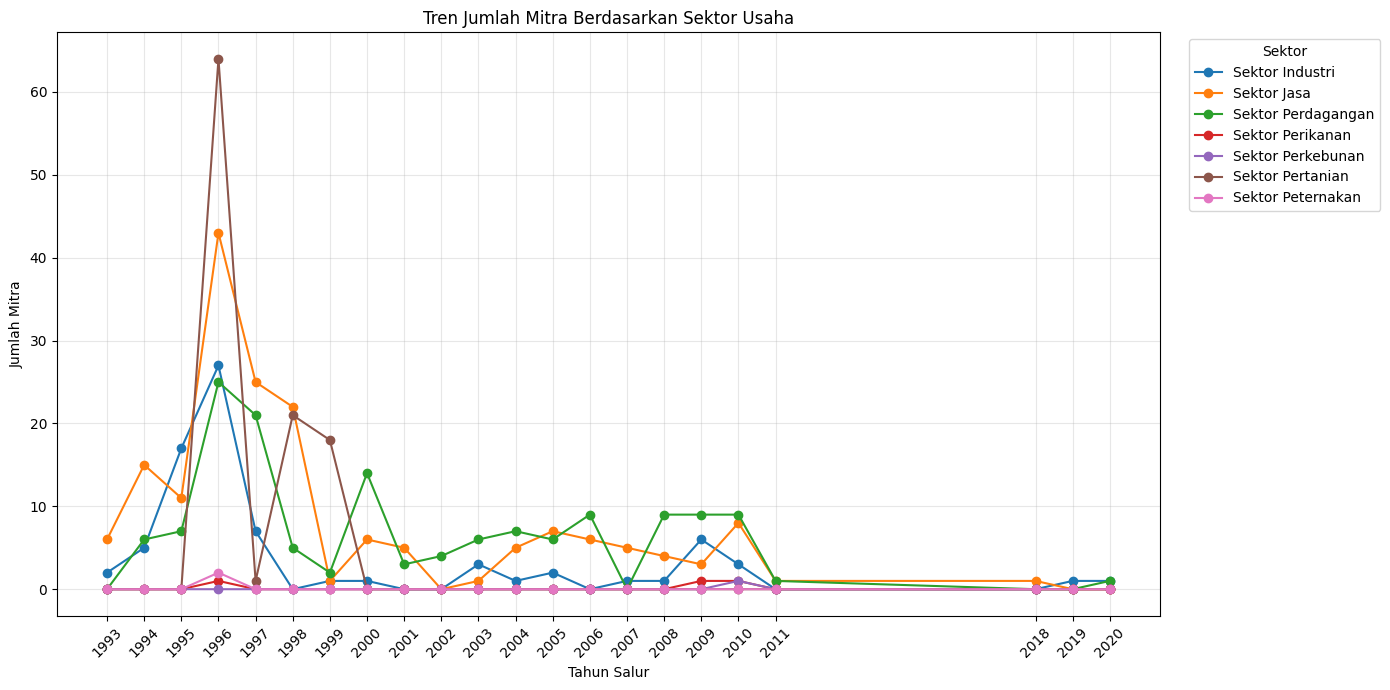

In [122]:
# ============================================================
# 15. VISUALISASI TREN SEKTOR USAHA
# Tujuan:
# - Melihat perubahan jumlah masing-masing sektor dari tahun ke tahun
# - Membandingkan pola perkembangan antar-sektor
# ============================================================

plt.figure(figsize=(14, 7)) # Membuat kanvas grafik baru dengan ukuran lebar 14 inci dan tinggi 7 inci

for sektor in pivot_sektor.columns: # Melakukan perulangan untuk setiap kolom (sektor usaha) yang ada di dalam tabel pivot
    plt.plot(                   # Membuat grafik garis (line plot) untuk setiap sektor
        pivot_sektor.index,     # Mengambil nilai indeks baris (tahun salur) sebagai koordinat sumbu X
        pivot_sektor[sektor],   # Mengambil nilai jumlah mitra dari kolom sektor tertentu sebagai koordinat sumbu Y
        marker="o",           # Menambahkan tanda titik (marker) lingkaran pada setiap titik data di garis
        label=sektor          # Memberikan label nama sektor untuk digunakan pada legenda grafik
    )                         # Menutup fungsi plt.plot

plt.title("Tren Jumlah Mitra Berdasarkan Sektor Usaha") # Memberikan judul utama pada grafik
plt.xlabel("Tahun Salur") # Memberikan label keterangan pada sumbu X
plt.ylabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu Y
plt.xticks(                # Mengatur label angka/teks yang muncul pada sumbu X
    pivot_sektor.index,     # Menyesuaikan titik tick sumbu X berdasarkan indeks tahun pada tabel pivot
    rotation=45         # Memutar teks label sumbu X sebesar 45 derajat agar lebih mudah dibaca
)

plt.legend(                # Menampilkan kotak legenda grafik
    title="Sektor",         # Memberikan judul pada kotak legenda
    bbox_to_anchor=(1.02, 1), # Mengatur posisi koordinat penempatan kotak legenda di luar area grafik (sebelah kanan atas)
    loc="upper left"        # Menentukan titik anchor pojok kiri atas dari kotak legenda
)

plt.grid(True, alpha=0.3) # Menampilkan garis latar belakang (grid) dengan tingkat transparansi 0.3
plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar tidak ada yang terpotong
plt.show()                # Menampilkan dan merender grafik ke layar

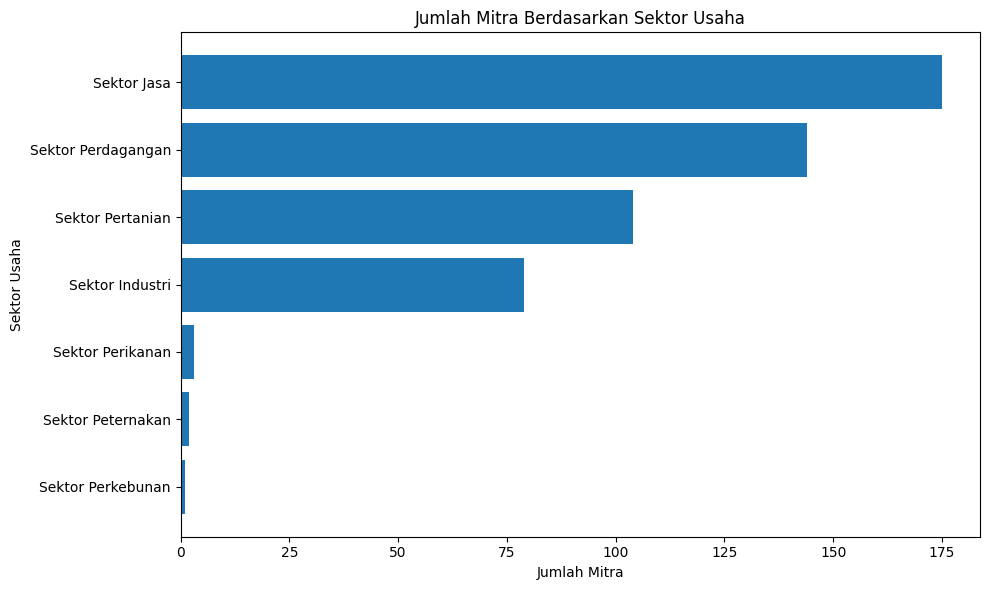

In [123]:
# ============================================================
# 16. BAR CHART TOTAL MITRA PER SEKTOR
# Tujuan:
# Melihat sektor usaha yang memiliki jumlah mitra terbesar
# secara keseluruhan pada seluruh periode data.
# ============================================================

sektor_total = (                # Menyimpan hasil perhitungan total mitra per sektor ke dalam variabel baru
    df_clean["SEKTOR_ANALISIS"] # Mengambil data dari kolom sektor yang sudah distandardisasi
    .value_counts()           # Menghitung jumlah total kemunculan setiap kategori sektor usaha
    .sort_values(ascending=True) # Mengurutkan nilai dari yang terkecil ke terbesar (agar tampil rapi dari bawah ke atas pada bar chart horizontal)
)                             # Menutup proses rantai perintah (method chaining)

plt.figure(figsize=(10, 6)) # Membuat kanvas grafik baru dengan ukuran lebar 10 inci dan tinggi 6 inci

plt.barh(                   # Membuat grafik batang horizontal (horizontal bar chart)
    sektor_total.index,     # Mengambil nama-nama sektor sebagai kategori pada sumbu Y
    sektor_total.values     # Mengambil nilai jumlah mitra sebagai panjang batang pada sumbu X
)

plt.title("Jumlah Mitra Berdasarkan Sektor Usaha") # Memberikan judul utama pada grafik
plt.xlabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu X
plt.ylabel("Sektor Usaha") # Memberikan label keterangan pada sumbu Y

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

<Figure size 1400x700 with 0 Axes>

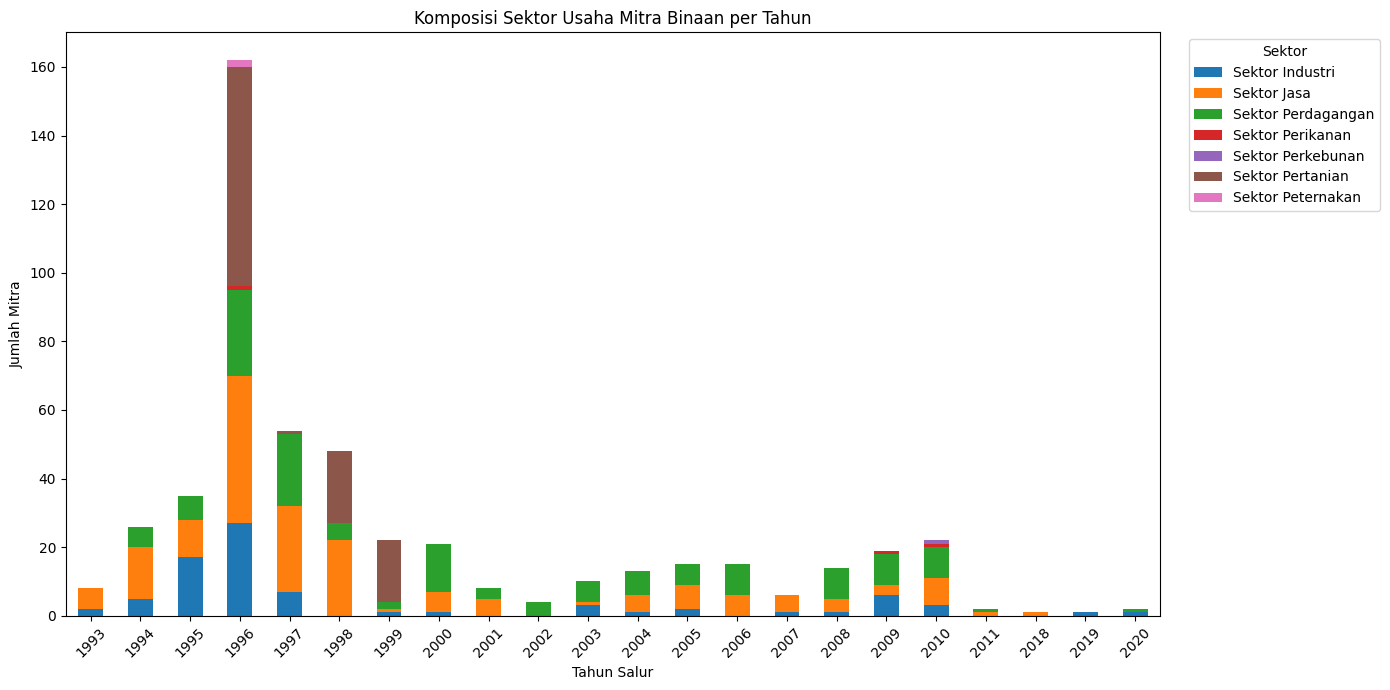

In [124]:
# ============================================================
# 17. STACKED BAR CHART SEKTOR PER TAHUN
# Tujuan:
# Melihat komposisi sektor usaha pada masing-masing tahun.
# ============================================================

plt.figure(figsize=(14, 7)) # Membuat kanvas grafik baru dengan ukuran lebar 14 inci dan tinggi 7 inci

pivot_sektor.plot(          # Membuat grafik langsung dari data tabel pivot sektor
    kind="bar",             # Menentukan jenis grafik berupa diagram batang (bar chart)
    stacked=True,           # Mengaktifkan mode bertumpuk (stacked) agar kategori sektor dalam satu tahun menumpuk dalam satu batang
    figsize=(14, 7)         # Mengatur ulang ukuran dimensi gambar grafik (lebar 14 inci, tinggi 7 inci)
)                           # Menutup fungsi pivot_sektor.plot

plt.title("Komposisi Sektor Usaha Mitra Binaan per Tahun") # Memberikan judul utama pada grafik
plt.xlabel("Tahun Salur") # Memberikan label keterangan pada sumbu X
plt.ylabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu Y
plt.xticks(rotation=45)   # Memutar teks label angka pada sumbu X sebesar 45 derajat agar lebih mudah dibaca

plt.legend(                # Menampilkan kotak legenda keterangan warna sektor
    title="Sektor",         # Memberikan judul pada kotak legenda
    bbox_to_anchor=(1.02, 1), # Mengatur koordinat posisi penempatan kotak legenda di luar area grafik (sebelah kanan atas)
    loc="upper left"        # Menentukan titik anchor pojok kiri atas dari kotak legenda
)                           # Menutup fungsi plt.legend

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional dan tidak terpotong
plt.show()                # Menampilkan dan merender grafik ke layar

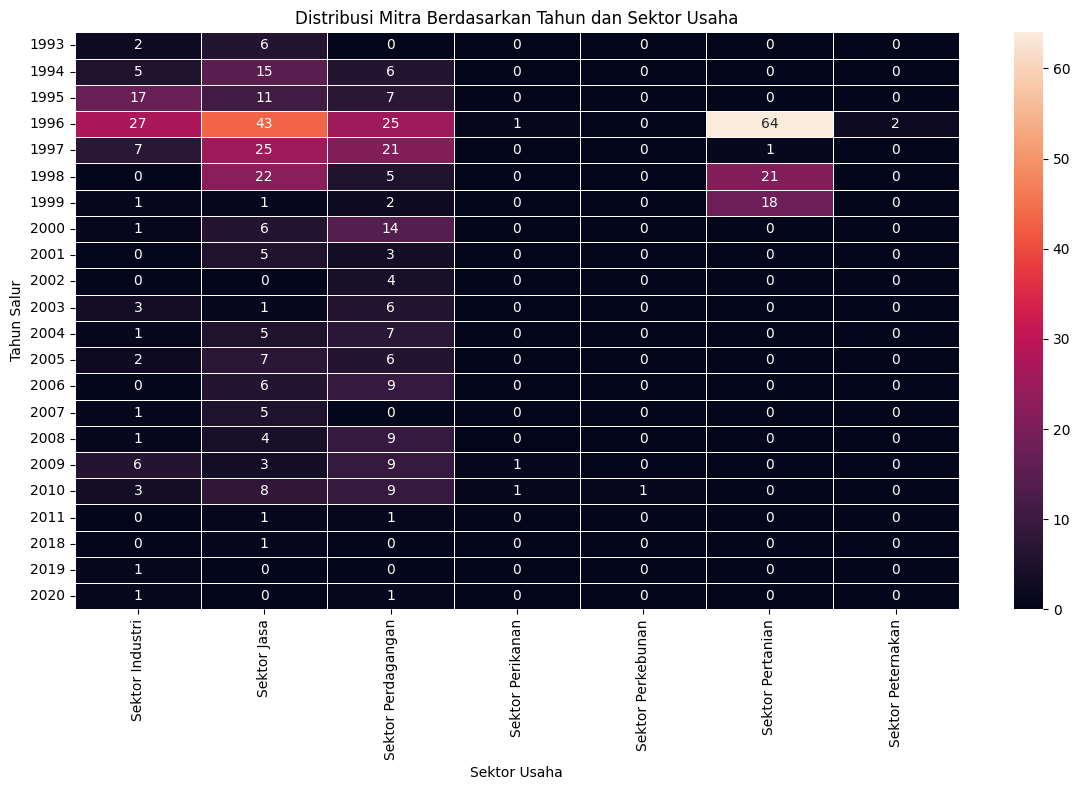

In [125]:
# ============================================================
# 18. HEATMAP TAHUN DAN SEKTOR
# Tujuan:
# Memvisualisasikan konsentrasi jumlah mitra pada kombinasi
# tahun dan sektor.
# ============================================================

plt.figure(figsize=(12, 8)) # Membuat kanvas grafik baru dengan ukuran lebar 12 inci dan tinggi 8 inci

sns.heatmap(                # Membuat grafik peta panas (heatmap) menggunakan library Seaborn
    pivot_sektor,         # Menggunakan data tabel pivot sektor yang berisi nilai jumlah mitra per tahun dan sektor
    annot=True,           # Menampilkan angka nilai numerik secara langsung di dalam setiap kotak sel heatmap
    fmt="d",              # Mengatur format angka pada anotasi menjadi bilangan bulat (integer/decimal)
    linewidths=0.5        # Menambahkan garis pemisah tipis setebal 0.5 di antara kotak-kotak sel pada heatmap
)                           # Menutup fungsi sns.heatmap

plt.title("Distribusi Mitra Berdasarkan Tahun dan Sektor Usaha") # Memberikan judul utama pada grafik
plt.xlabel("Sektor Usaha") # Memberikan label keterangan pada sumbu X
plt.ylabel("Tahun Salur") # Memberikan label keterangan pada sumbu Y

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional dan tidak terpotong
plt.show()                # Menampilkan dan merender grafik ke layar

In [126]:
# ============================================================
# 19. PERSENTASE SEKTOR PER TAHUN
# Tujuan:
# Melihat perubahan proporsi/komposisi sektor dari waktu
# ke waktu tanpa dipengaruhi oleh perbedaan total jumlah mitra.
# ============================================================

proporsi_sektor = (                # Menyimpan hasil perhitungan persentase proporsi sektor ke dalam variabel baru
    pivot_sektor                # Menggunakan DataFrame tabel pivot sektor
    .div(pivot_sektor.sum(axis=1), axis=0) # Membagi setiap nilai sel baris dengan total jumlah keseluruhan mitra pada baris (tahun) tersebut
    * 100                     # Mengalikan hasil pembagian dengan angka 100 untuk mengubahnya menjadi bentuk persentase (%)
)                             # Menutup proses rantai perintah (method chaining)

display(proporsi_sektor.round(2)) # Menampilkan tabel persentase proporsi sektor ke layar dengan pembulatan 2 angka di belakang koma

SEKTOR_ANALISIS,Sektor Industri,Sektor Jasa,Sektor Perdagangan,Sektor Perikanan,Sektor Perkebunan,Sektor Pertanian,Sektor Peternakan
TAHUN SALUR,,,,,,,
1993,25.00,75.00,0.00,0.00,0.00,0.00,0.00
1994,19.23,57.69,23.08,0.00,0.00,0.00,0.00
1995,48.57,31.43,20.00,0.00,0.00,0.00,0.00
1996,16.67,26.54,15.43,0.62,0.00,39.51,1.23
1997,12.96,46.30,38.89,0.00,0.00,1.85,0.00
1998,0.00,45.83,10.42,0.00,0.00,43.75,0.00
1999,4.55,4.55,9.09,0.00,0.00,81.82,0.00
2000,4.76,28.57,66.67,0.00,0.00,0.00,0.00
2001,0.00,62.50,37.50,0.00,0.00,0.00,0.00


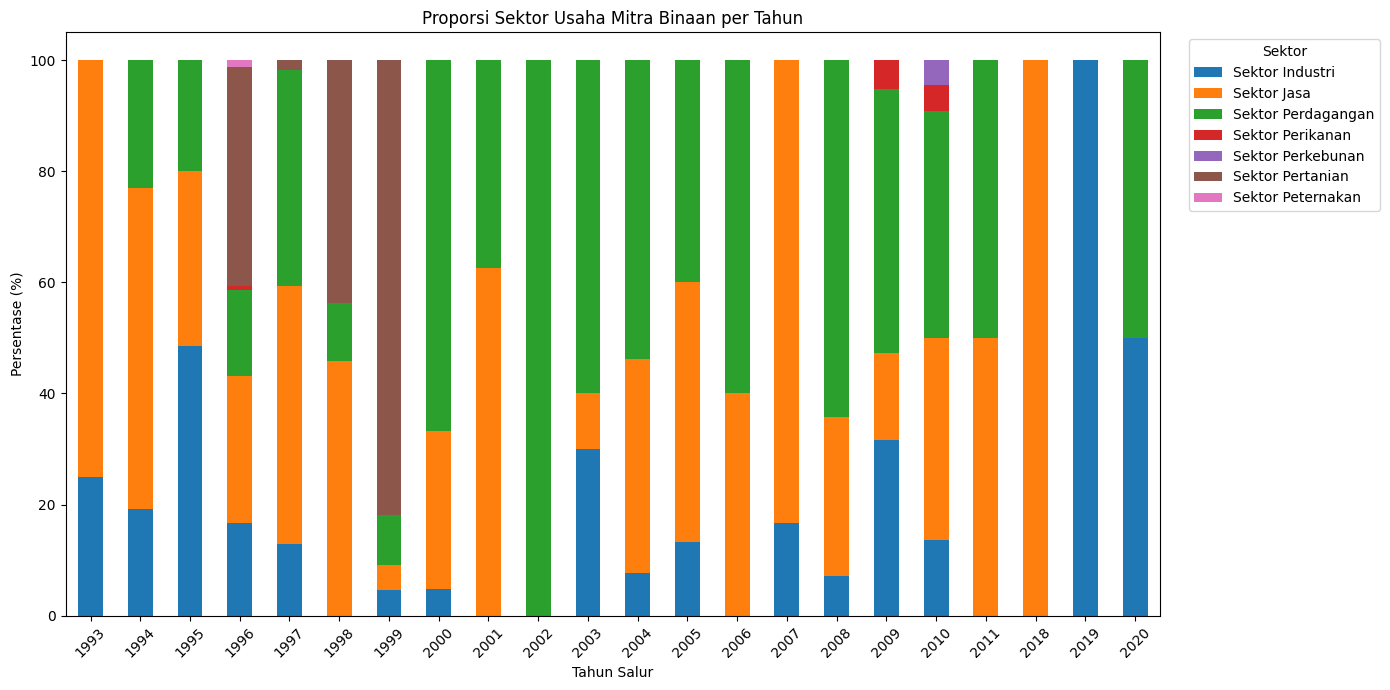

In [127]:
# ============================================================
# 20. 100% STACKED BAR CHART
# Tujuan:
# Membandingkan komposisi sektor antar-tahun dalam bentuk
# persentase.
# ============================================================

proporsi_sektor.plot(       # Membuat grafik langsung dari data tabel proporsi persentase sektor
    kind="bar",             # Menentukan jenis grafik berupa diagram batang (bar chart)
    stacked=True,           # Mengaktifkan mode bertumpuk (stacked) agar persentase sektor menumpuk hingga mencapai 100%
    figsize=(14, 7)         # Mengatur ukuran dimensi gambar grafik dengan lebar 14 inci dan tinggi 7 inci
)                           # Menutup fungsi proporsi_sektor.plot

plt.title("Proporsi Sektor Usaha Mitra Binaan per Tahun") # Memberikan judul utama pada grafik
plt.xlabel("Tahun Salur") # Memberikan label keterangan pada sumbu X
plt.ylabel("Persentase (%)") # Memberikan label keterangan pada sumbu Y
plt.xticks(rotation=45)   # Memutar teks label angka pada sumbu X sebesar 45 derajat agar lebih mudah dibaca

plt.legend(                # Menampilkan kotak legenda keterangan warna sektor
    title="Sektor",         # Memberikan judul pada kotak legenda
    bbox_to_anchor=(1.02, 1), # Mengatur koordinat posisi penempatan kotak legenda di luar area grafik (sebelah kanan atas)
    loc="upper left"        # Menentukan titik anchor pojok kiri atas dari kotak legenda
)                           # Menutup fungsi plt.legend

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional dan tidak terpotong
plt.show()                # Menampilkan dan merender grafik ke layar

In [128]:
# ============================================================
# 21. STANDARDISASI LOKASI
# Tujuan:
# - Menyamakan format penulisan lokasi
# - Menghilangkan spasi berlebih
# - Menyamakan kapitalisasi
# - Menghindari satu wilayah terbaca sebagai dua kategori
# ============================================================

df_clean["LOKASI_ANALISIS"] = ( # Membuat atau menimpa kolom baru bernama "LOKASI_ANALISIS" di df_clean
    df_clean["LOKASI"]        # Mengambil data dari kolom asli "LOKASI"
    .astype("string")         # Mengonversi seluruh isi kolom menjadi tipe data string pandas
    .str.strip()              # Menghapus spasi ekstra di awal dan akhir teks lokasi
    .str.replace(r"\s+", " ", regex=True) # Mengganti spasi ganda atau lebih di tengah teks menjadi satu spasi tunggal
    .str.upper()              # Mengubah seluruh huruf teks menjadi huruf kapital (Uppercase)
)                             # Menutup proses rantai perintah (method chaining)

# Menampilkan jumlah mitra setiap lokasi
lokasi_total = (              # Menyimpan hasil perhitungan total mitra per lokasi ke variabel lokasi_total
    df_clean["LOKASI_ANALISIS"] # Mengambil data dari kolom lokasi yang sudah distandardisasi
    .value_counts(dropna=False) # Menghitung frekuensi kemunculan setiap wilayah, termasuk nilai kosong (NaN)
)                             # Menutup proses rantai perintah

display(                      # Memulai fungsi untuk menampilkan tabel ke layar
    lokasi_total.to_frame("JUMLAH MITRA") # Mengubah Series hasil hitung menjadi DataFrame dengan nama kolom tabel "JUMLAH MITRA"
)                             # Menutup fungsi display

,JUMLAH MITRA
LOKASI_ANALISIS,
KOTA BIMA,106
KOTA MATARAM,76
SUMBAWA,62
LOMBOK BARAT,58
BIMA,54
LOMBOK TENGAH,52
LOMBOK TIMUR,48
DOMPU,37
LOMBOK UTARA,15


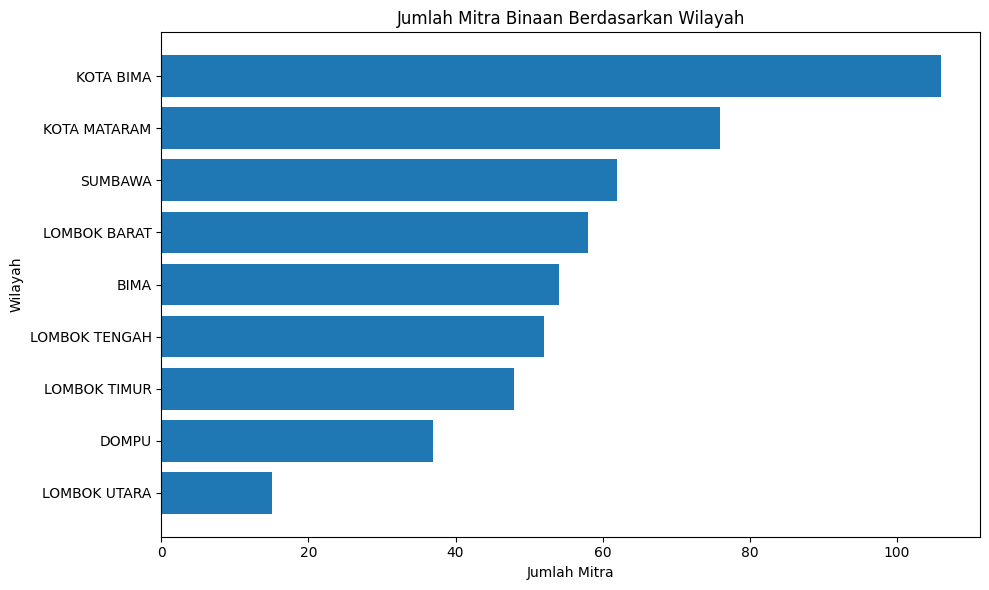

In [129]:
# ============================================================
# 22. BAR CHART JUMLAH MITRA PER WILAYAH
# Tujuan:
# Melihat wilayah dengan jumlah mitra binaan terbanyak
# secara keseluruhan.
# ============================================================

lokasi_total_sorted = lokasi_total.sort_values(ascending=True) # Mengurutkan data jumlah mitra dari yang terkecil ke terbesar untuk grafik batang horizontal

plt.figure(figsize=(10, 6)) # Membuat kanvas gambar grafik baru dengan ukuran lebar 10 inci dan tinggi 6 inci

plt.barh(                   # Membuat grafik batang horizontal (horizontal bar chart)
    lokasi_total_sorted.index, # Mengambil nama-nama wilayah sebagai kategori pada sumbu Y
    lokasi_total_sorted.values # Mengambil angka jumlah mitra sebagai panjang batang pada sumbu X
)

plt.title("Jumlah Mitra Binaan Berdasarkan Wilayah") # Memberikan judul utama pada grafik
plt.xlabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu X
plt.ylabel("Wilayah")     # Memberikan label keterangan pada sumbu Y

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

In [130]:
# ============================================================
# 23. TREN JUMLAH MITRA BERDASARKAN WILAYAH DAN TAHUN
# Tujuan:
# - Melihat perkembangan jumlah mitra pada setiap wilayah
#   dari waktu ke waktu.
# ============================================================

trend_wilayah = (             # Menyimpan hasil pengolahan data tren wilayah dan tahun ke dalam variabel baru
    df_clean                  # Menggunakan DataFrame bersih
    .groupby(["TAHUN SALUR", "LOKASI_ANALISIS"]) # Mengelompokkan data berdasarkan kombinasi tahun salur dan wilayah analisis
    .size()                   # Menghitung jumlah baris (frekuensi) untuk setiap kelompok kombinasi tersebut
    .reset_index(name="JUMLAH MITRA") # Mengubah hasil grouping kembali menjadi DataFrame dan menamai kolom hasil hitung menjadi "JUMLAH MITRA"
    .sort_values(["TAHUN SALUR", "LOKASI_ANALISIS"]) # Mengurutkan baris DataFrame berdasarkan urutan tahun salur dan wilayah analisis
)                             # Menutup proses rantai perintah (method chaining)

display(trend_wilayah)        # Menampilkan tabel hasil analisis tren wilayah dan tahun ke layar

,TAHUN SALUR,LOKASI_ANALISIS,JUMLAH MITRA
0,1993,BIMA,2
1,1993,DOMPU,3
2,1993,KOTA BIMA,3
3,1994,BIMA,5
4,1994,DOMPU,5
5,1994,KOTA BIMA,6
6,1994,SUMBAWA,10
7,1995,BIMA,7
8,1995,DOMPU,9
9,1995,KOTA BIMA,15


In [131]:
# ============================================================
# 24. PIVOT TAHUN DAN WILAYAH
# Tujuan:
# Membentuk tabel yang memudahkan analisis distribusi mitra
# antarwilayah pada setiap tahun.
# ============================================================

pivot_wilayah = (             # Menyimpan hasil tabel pivot wilayah ke dalam variabel baru
    trend_wilayah             # Menggunakan DataFrame tren wilayah sebelumnya
    .pivot(                   # Mengubah bentuk DataFrame dari panjang (long) menjadi lebar (wide)
        index="TAHUN SALUR",    # Menjadikan kolom "TAHUN SALUR" sebagai indeks baris pada tabel baru
        columns="LOKASI_ANALISIS", # Menjadikan nilai unik pada kolom "LOKASI_ANALISIS" sebagai nama-nama kolom baru
        values="JUMLAH MITRA" # Mengisi sel tabel dengan nilai dari kolom "JUMLAH MITRA"
    )                         # Menutup fungsi pivot
    .fillna(0)                # Mengganti seluruh nilai kosong (NaN) pada tabel pivot menjadi angka 0
    .astype(int)              # Mengonversi seluruh tipe data angka di dalam tabel pivot menjadi integer (bilangan bulat)
)                             # Menutup proses rantai perintah (method chaining)

display(pivot_wilayah)        # Menampilkan tabel pivot tahun dan wilayah ke layar

LOKASI_ANALISIS,BIMA,DOMPU,KOTA BIMA,KOTA MATARAM,LOMBOK BARAT,LOMBOK TENGAH,LOMBOK TIMUR,LOMBOK UTARA,SUMBAWA
TAHUN SALUR,,,,,,,,,
1993,2,3,3,0,0,0,0,0,0
1994,5,5,6,0,0,0,0,0,10
1995,7,9,15,0,0,0,0,0,4
1996,19,7,29,10,22,29,25,7,14
1997,9,7,19,4,1,0,0,0,14
1998,0,0,0,8,14,13,2,7,4
1999,1,0,0,15,3,0,0,0,3
2000,5,1,7,3,2,0,3,0,0
2001,0,0,0,2,1,3,2,0,0


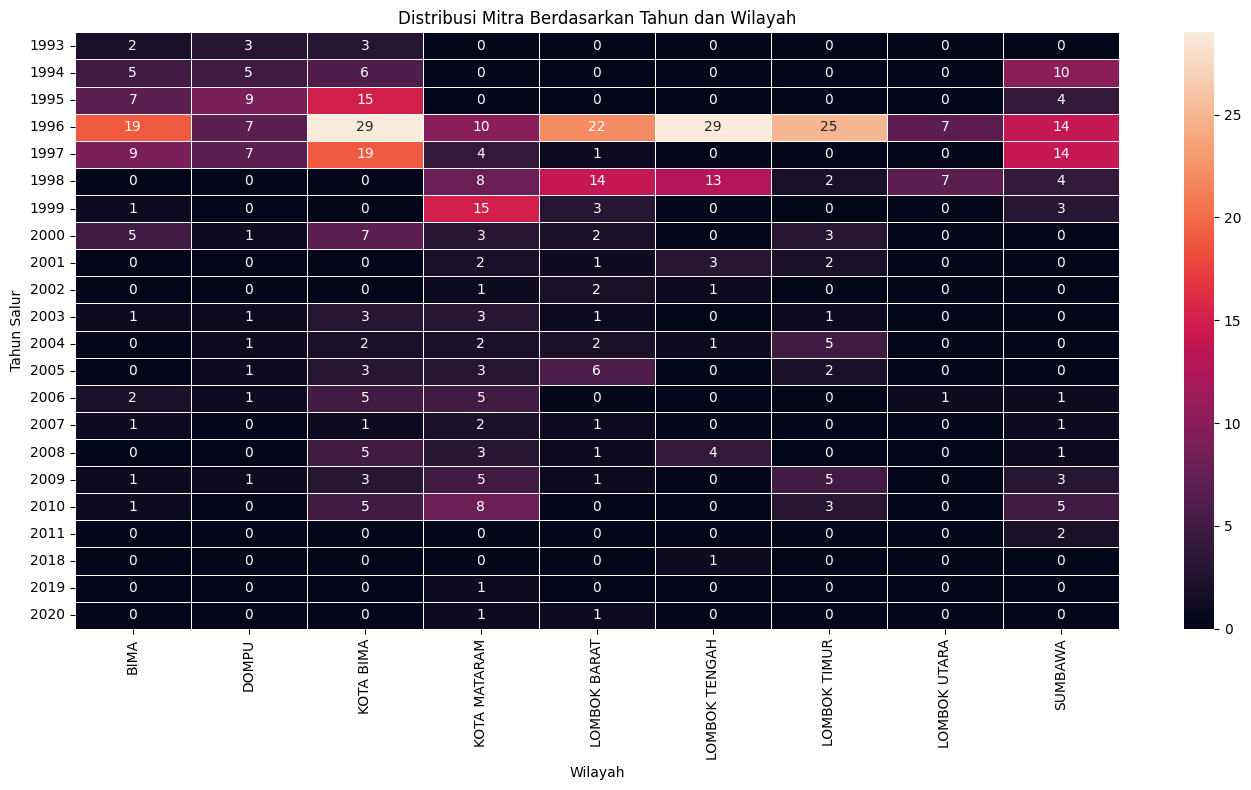

In [132]:
# ============================================================
# 25. HEATMAP TAHUN × WILAYAH
# Tujuan:
# Melihat konsentrasi jumlah mitra berdasarkan kombinasi
# tahun salur dan wilayah.
# ============================================================

plt.figure(figsize=(14, 8)) # Membuat kanvas grafik baru dengan ukuran lebar 14 inci dan tinggi 8 inci

sns.heatmap(                # Membuat grafik peta panas (heatmap) menggunakan library Seaborn
    pivot_wilayah,        # Menggunakan data tabel pivot wilayah yang berisi nilai jumlah mitra
    annot=True,           # Menampilkan angka nilai numerik secara langsung di dalam setiap kotak sel heatmap
    fmt="d",              # Mengatur format angka pada anotasi menjadi bilangan bulat (integer)
    linewidths=0.5        # Menambahkan garis pemisah tipis setebal 0.5 di antara kotak-kotak sel heatmap
)                           # Menutup fungsi sns.heatmap

plt.title("Distribusi Mitra Berdasarkan Tahun dan Wilayah") # Memberikan judul utama pada grafik
plt.xlabel("Wilayah")     # Memberikan label keterangan pada sumbu X
plt.ylabel("Tahun Salur") # Memberikan label keterangan pada sumbu Y

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

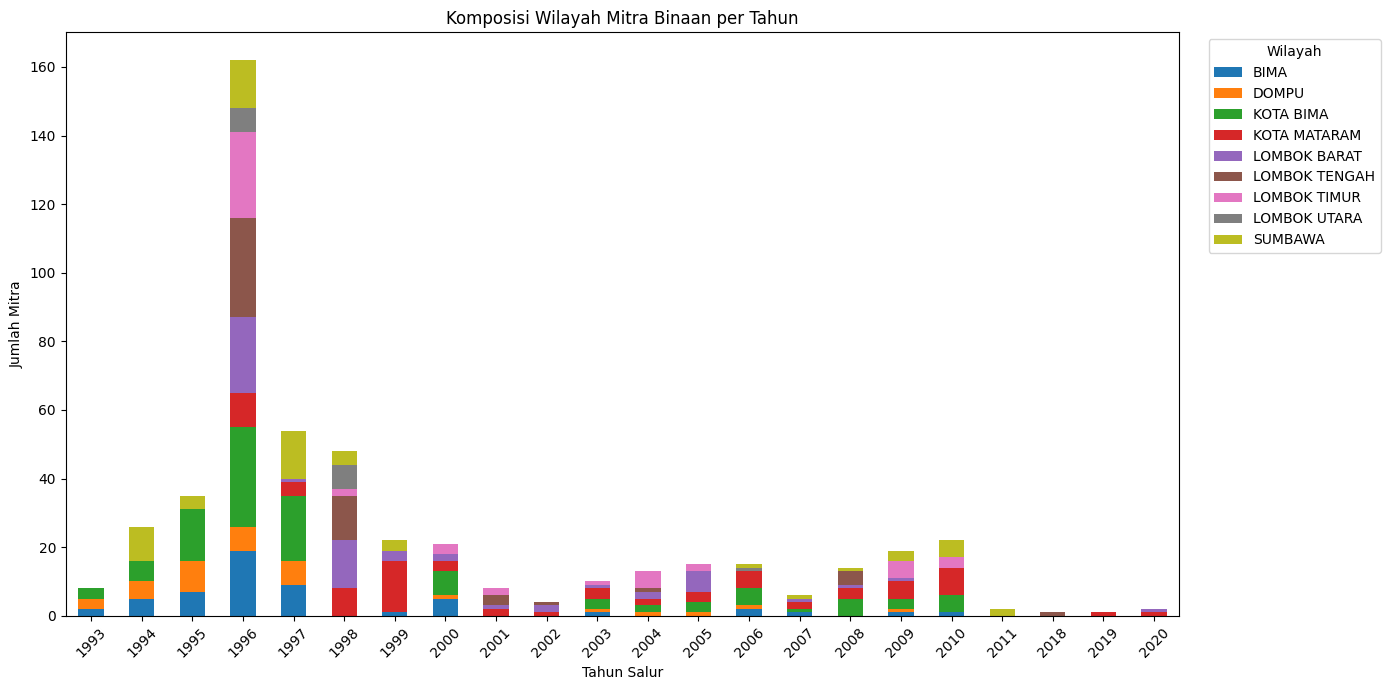

In [133]:
# ============================================================
# 26. STACKED BAR WILAYAH PER TAHUN
# Tujuan:
# Melihat komposisi wilayah pada masing-masing tahun.
# ============================================================

pivot_wilayah.plot(         # Membuat grafik langsung dari data tabel pivot wilayah
    kind="bar",             # Menentukan jenis grafik berupa diagram batang (bar chart)
    stacked=True,           # Mengaktifkan mode bertumpuk (stacked) agar kategori wilayah dalam satu tahun menumpuk dalam satu batang
    figsize=(14, 7)         # Mengatur ukuran dimensi gambar grafik dengan lebar 14 inci dan tinggi 7 inci
)                           # Menutup fungsi pivot_wilayah.plot

plt.title("Komposisi Wilayah Mitra Binaan per Tahun") # Memberikan judul utama pada grafik
plt.xlabel("Tahun Salur") # Memberikan label keterangan pada sumbu X
plt.ylabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu Y
plt.xticks(rotation=45)   # Memutar teks label angka pada sumbu X sebesar 45 derajat agar lebih mudah dibaca

plt.legend(                # Menampilkan kotak legenda keterangan warna wilayah
    title="Wilayah",        # Memberikan judul pada kotak legenda
    bbox_to_anchor=(1.02, 1), # Mengatur posisi koordinat penempatan kotak legenda di luar area grafik (sebelah kanan atas)
    loc="upper left"        # Menentukan titik anchor pojok kiri atas dari kotak legenda
)                           # Menutup fungsi plt.legend

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

In [134]:
# ============================================================
# 27. STANDARDISASI UNIT
# Tujuan:
# - Menyamakan format penulisan unit
# - Menghilangkan spasi berlebih
# - Menyamakan kapitalisasi
# ============================================================

df_clean["UNIT_ANALISIS"] = ( # Membuat atau menimpa kolom baru bernama "UNIT_ANALISIS" di df_clean
    df_clean["UNIT"]        # Mengambil data dari kolom asli "UNIT"
    .astype("string")         # Mengonversi seluruh isi kolom menjadi tipe data string pandas
    .str.strip()              # Menghapus spasi ekstra di awal dan akhir teks unit
    .str.replace(r"\s+", " ", regex=True) # Mengganti spasi ganda atau lebih di tengah teks menjadi satu spasi tunggal
    .str.upper()              # Mengubah seluruh huruf teks menjadi huruf kapital (Uppercase)
)                             # Menutup proses rantai perintah (method chaining)

# Melihat jumlah mitra berdasarkan unit
unit_total = (                # Menyimpan hasil perhitungan total mitra per unit ke variabel unit_total
    df_clean["UNIT_ANALISIS"] # Mengambil data dari kolom unit yang sudah distandardisasi
    .value_counts(dropna=False) # Menghitung frekuensi kemunculan setiap unit, termasuk nilai kosong (NaN)
)                             # Menutup proses rantai perintah

display(                      # Memulai fungsi untuk menampilkan tabel ke layar
    unit_total.to_frame("JUMLAH MITRA") # Mengubah Series hasil hitung menjadi DataFrame dengan nama kolom tabel "JUMLAH MITRA"
)                             # Menutup fungsi display

,JUMLAH MITRA
UNIT_ANALISIS,
UP3 BIMA,105
UPK TAMBORA,92
UP3 MATARAM,64
UPK LOMBOK,63
UP3 SUMBAWA,62
UPT MATARAM,52
UP2D NTB,30
UP2B NTB,30
UP2K NTB,10


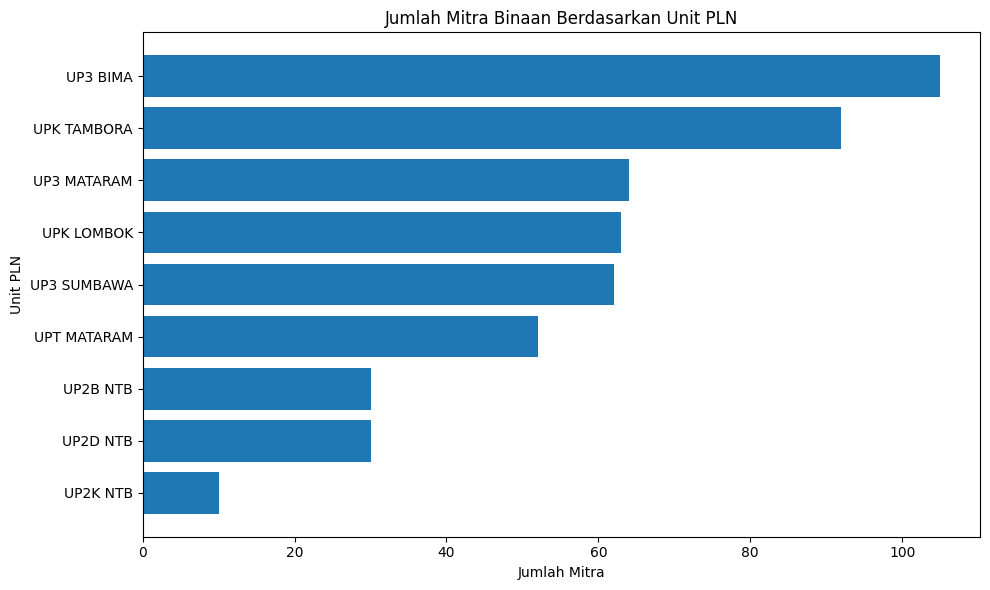

In [135]:
# ============================================================
# 28. BAR CHART JUMLAH MITRA PER UNIT
# Tujuan:
# Melihat distribusi jumlah mitra pada masing-masing unit PLN.
# ============================================================

unit_total_sorted = unit_total.sort_values(ascending=True) # Mengurutkan data jumlah mitra per unit dari yang terkecil ke terbesar

plt.figure(figsize=(10, 6)) # Membuat kanvas grafik baru dengan ukuran lebar 10 inci dan tinggi 6 inci

plt.barh(                   # Membuat grafik batang horizontal (horizontal bar chart)
    unit_total_sorted.index, # Mengambil nama-nama unit sebagai kategori pada sumbu Y
    unit_total_sorted.values # Mengambil angka jumlah mitra sebagai panjang batang pada sumbu X
)

plt.title("Jumlah Mitra Binaan Berdasarkan Unit PLN") # Memberikan judul utama pada grafik
plt.xlabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu X
plt.ylabel("Unit PLN")    # Memberikan label keterangan pada sumbu Y

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

In [136]:
# ============================================================
# 29. TREN JUMLAH MITRA BERDASARKAN UNIT DAN TAHUN
# Tujuan:
# Melihat perkembangan jumlah mitra yang dikelola setiap unit
# dari waktu ke waktu.
# ============================================================

trend_unit = (                # Menyimpan hasil pengolahan data tren unit dan tahun ke dalam variabel baru
    df_clean                  # Menggunakan DataFrame bersih
    .groupby(["TAHUN SALUR", "UNIT_ANALISIS"]) # Mengelompokkan data berdasarkan kombinasi tahun salur dan unit analisis
    .size()                   # Menghitung jumlah baris (frekuensi) untuk setiap kelompok kombinasi tersebut
    .reset_index(name="JUMLAH MITRA") # Mengubah hasil grouping kembali menjadi DataFrame dan menamai kolom hasil hitung menjadi "JUMLAH MITRA"
    .sort_values(["TAHUN SALUR", "UNIT_ANALISIS"]) # Mengurutkan baris DataFrame berdasarkan urutan tahun salur dan unit analisis
)                             # Menutup proses rantai perintah (method chaining)

display(trend_unit)           # Menampilkan tabel hasil analisis tren unit dan tahun ke layar

,TAHUN SALUR,UNIT_ANALISIS,JUMLAH MITRA
0,1993,UP3 BIMA,4
1,1993,UPK TAMBORA,4
2,1994,UP3 BIMA,9
3,1994,UP3 SUMBAWA,10
4,1994,UPK TAMBORA,7
5,1995,UP3 BIMA,15
6,1995,UP3 SUMBAWA,4
7,1995,UPK TAMBORA,16
8,1996,UP2B NTB,4
9,1996,UP2D NTB,6


In [137]:
# ============================================================
# 30. PIVOT TAHUN DAN UNIT
# Tujuan:
# Membentuk tabel distribusi jumlah mitra berdasarkan tahun
# dan unit PLN.
# ============================================================

pivot_unit = (                # Menyimpan hasil tabel pivot unit ke dalam variabel baru
    trend_unit                # Menggunakan DataFrame tren unit sebelumnya
    .pivot(                   # Mengubah bentuk DataFrame dari panjang (long) menjadi lebar (wide)
        index="TAHUN SALUR",    # Menjadikan kolom "TAHUN SALUR" sebagai indeks baris pada tabel baru
        columns="UNIT_ANALISIS", # Menjadikan nilai unik pada kolom "UNIT_ANALISIS" sebagai nama-nama kolom baru
        values="JUMLAH MITRA" # Mengisi sel tabel dengan nilai dari kolom "JUMLAH MITRA"
    )                         # Menutup fungsi pivot
    .fillna(0)                # Mengganti seluruh nilai kosong (NaN) pada tabel pivot menjadi angka 0
    .astype(int)              # Mengonversi seluruh tipe data angka di dalam tabel pivot menjadi integer (bilangan bulat)
)                             # Menutup proses rantai perintah (method chaining)

display(pivot_unit)           # Menampilkan tabel pivot tahun dan unit ke layar

UNIT_ANALISIS,UP2B NTB,UP2D NTB,UP2K NTB,UP3 BIMA,UP3 MATARAM,UP3 SUMBAWA,UPK LOMBOK,UPK TAMBORA,UPT MATARAM
TAHUN SALUR,,,,,,,,,
1993,0,0,0,4,0,0,0,4,0
1994,0,0,0,9,0,10,0,7,0
1995,0,0,0,15,0,4,0,16,0
1996,4,6,0,28,22,14,32,27,29
1997,2,2,0,15,1,14,0,20,0
1998,3,5,0,0,14,4,9,0,13
1999,1,0,10,1,7,3,0,0,0
2000,2,1,0,7,2,0,3,6,0
2001,1,1,0,0,1,0,2,0,3


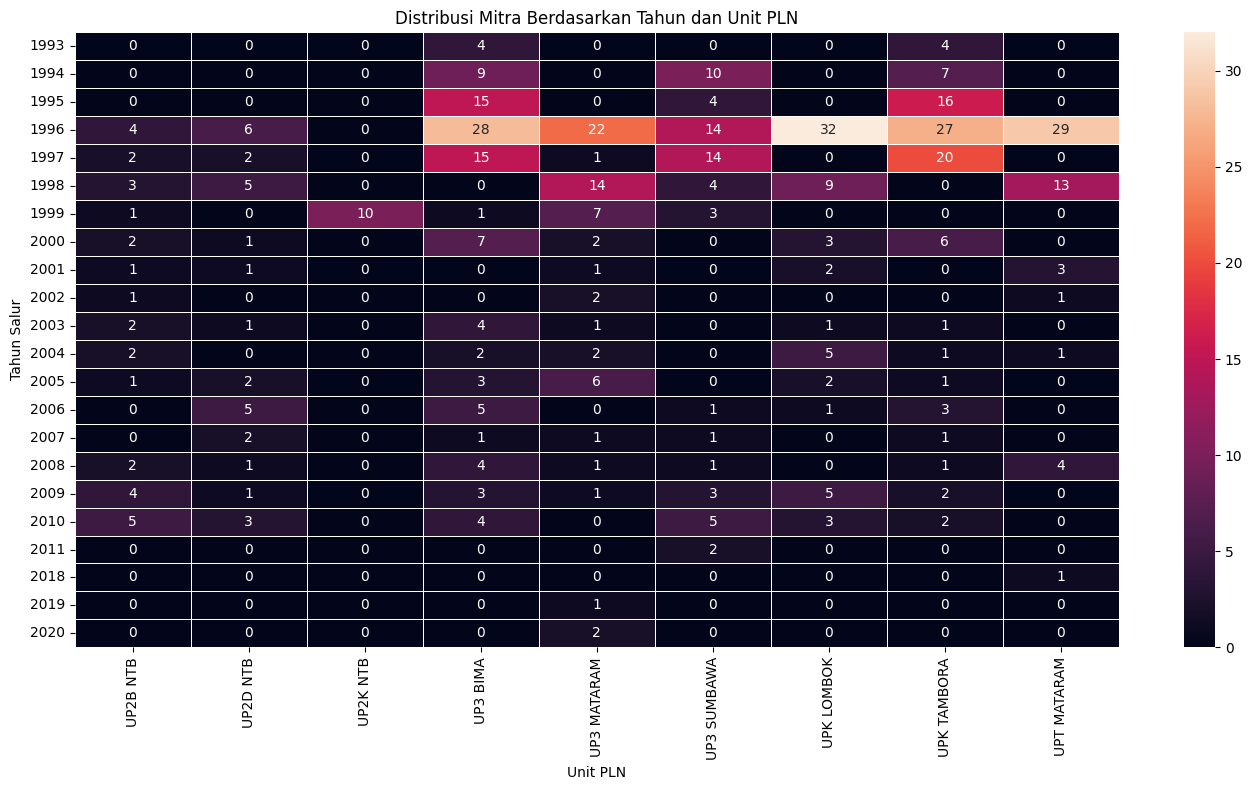

In [138]:
# ============================================================
# 31. HEATMAP TAHUN × UNIT
# Tujuan:
# Melihat konsentrasi jumlah mitra berdasarkan tahun dan unit.
# ============================================================

plt.figure(figsize=(14, 8)) # Membuat kanvas grafik baru dengan ukuran lebar 14 inci dan tinggi 8 inci

sns.heatmap(                # Membuat grafik peta panas (heatmap) menggunakan library Seaborn
    pivot_unit,           # Menggunakan data tabel pivot unit yang berisi nilai jumlah mitra
    annot=True,           # Menampilkan angka nilai numerik secara langsung di dalam setiap kotak sel heatmap
    fmt="d",              # Mengatur format angka pada anotasi menjadi bilangan bulat (integer)
    linewidths=0.5        # Menambahkan garis pemisah tipis setebal 0.5 di antara kotak-kotak sel heatmap
)                           # Menutup fungsi sns.heatmap

plt.title("Distribusi Mitra Berdasarkan Tahun dan Unit PLN") # Memberikan judul utama pada grafik
plt.xlabel("Unit PLN")    # Memberikan label keterangan pada sumbu X
plt.ylabel("Tahun Salur") # Memberikan label keterangan pada sumbu Y

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

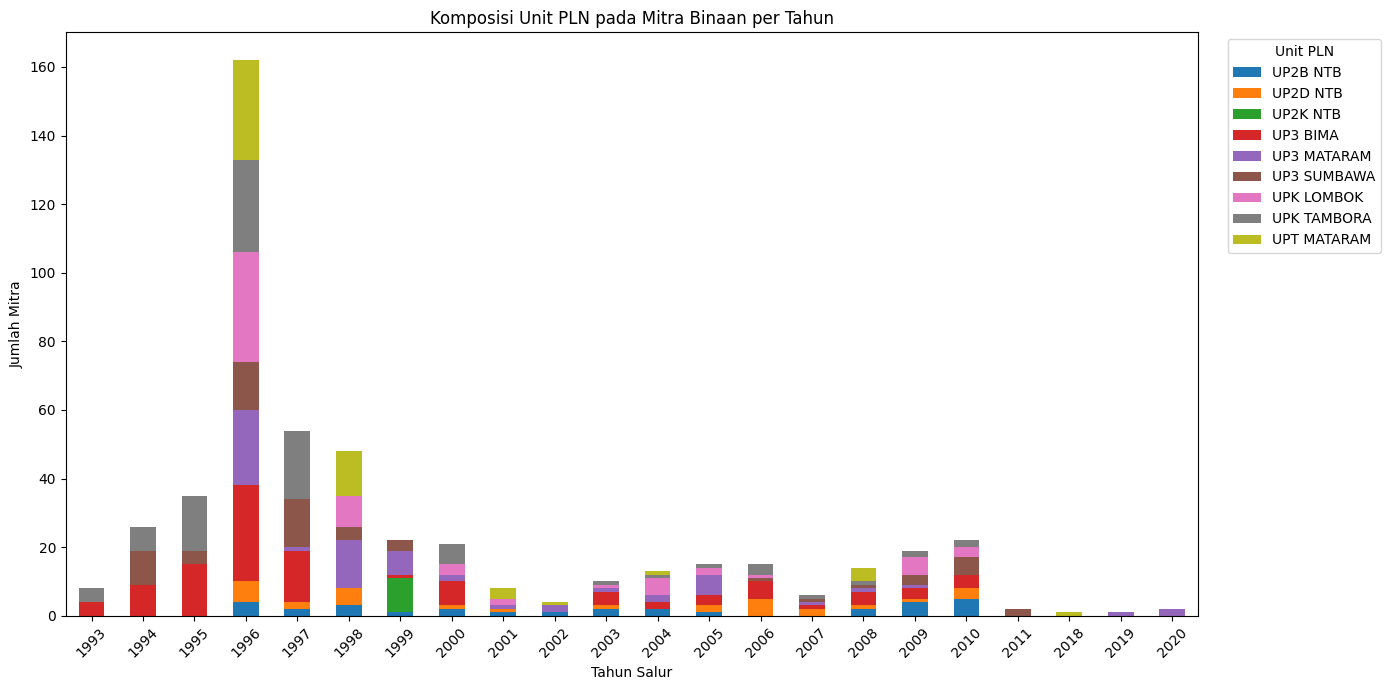

In [139]:
# ============================================================
# 32. STACKED BAR UNIT PER TAHUN
# Tujuan:
# Melihat komposisi unit pada masing-masing tahun.
# ============================================================

pivot_unit.plot(            # Membuat grafik langsung dari data tabel pivot unit
    kind="bar",             # Menentukan jenis grafik berupa diagram batang (bar chart)
    stacked=True,           # Mengaktifkan mode bertumpuk (stacked) agar kategori unit dalam satu tahun menumpuk dalam satu batang
    figsize=(14, 7)         # Mengatur ukuran dimensi gambar grafik dengan lebar 14 inci dan tinggi 7 inci
)                           # Menutup fungsi pivot_unit.plot

plt.title("Komposisi Unit PLN pada Mitra Binaan per Tahun") # Memberikan judul utama pada grafik
plt.xlabel("Tahun Salur") # Memberikan label keterangan pada sumbu X
plt.ylabel("Jumlah Mitra") # Memberikan label keterangan pada sumbu Y
plt.xticks(rotation=45)   # Memutar teks label angka pada sumbu X sebesar 45 derajat agar lebih mudah dibaca

plt.legend(                # Menampilkan kotak legenda keterangan warna unit PLN
    title="Unit PLN",       # Memberikan judul pada kotak legenda
    bbox_to_anchor=(1.02, 1), # Mengatur posisi koordinat penempatan kotak legenda di luar area grafik (sebelah kanan atas)
    loc="upper left"        # Menentukan titik anchor pojok kiri atas dari kotak legenda
)                           # Menutup fungsi plt.legend

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

In [140]:
# ============================================================
# 33. PROPORSI SEKTOR PER TAHUN
# Tujuan:
# Menghitung persentase kontribusi setiap sektor pada
# masing-masing tahun.
# ============================================================

proporsi_sektor = (         # Menyimpan hasil perhitungan persentase proporsi sektor ke dalam variabel baru
    pivot_sektor            # Menggunakan DataFrame tabel pivot sektor
    .div(pivot_sektor.sum(axis=1), axis=0) # Membagi setiap nilai sel baris dengan total keseluruhan mitra pada baris (tahun) tersebut
    .mul(100)               # Mengalikan hasil pembagian dengan angka 100 untuk mengubahnya menjadi bentuk persentase (%)
)                             # Menutup proses rantai perintah (method chaining)

display(                      # Memulai fungsi untuk menampilkan tabel ke layar
    proporsi_sektor.round(2) # Menampilkan tabel proporsi sektor dengan pembulatan 2 angka di belakang koma
)                             # Menutup fungsi display

SEKTOR_ANALISIS,Sektor Industri,Sektor Jasa,Sektor Perdagangan,Sektor Perikanan,Sektor Perkebunan,Sektor Pertanian,Sektor Peternakan
TAHUN SALUR,,,,,,,
1993,25.00,75.00,0.00,0.00,0.00,0.00,0.00
1994,19.23,57.69,23.08,0.00,0.00,0.00,0.00
1995,48.57,31.43,20.00,0.00,0.00,0.00,0.00
1996,16.67,26.54,15.43,0.62,0.00,39.51,1.23
1997,12.96,46.30,38.89,0.00,0.00,1.85,0.00
1998,0.00,45.83,10.42,0.00,0.00,43.75,0.00
1999,4.55,4.55,9.09,0.00,0.00,81.82,0.00
2000,4.76,28.57,66.67,0.00,0.00,0.00,0.00
2001,0.00,62.50,37.50,0.00,0.00,0.00,0.00


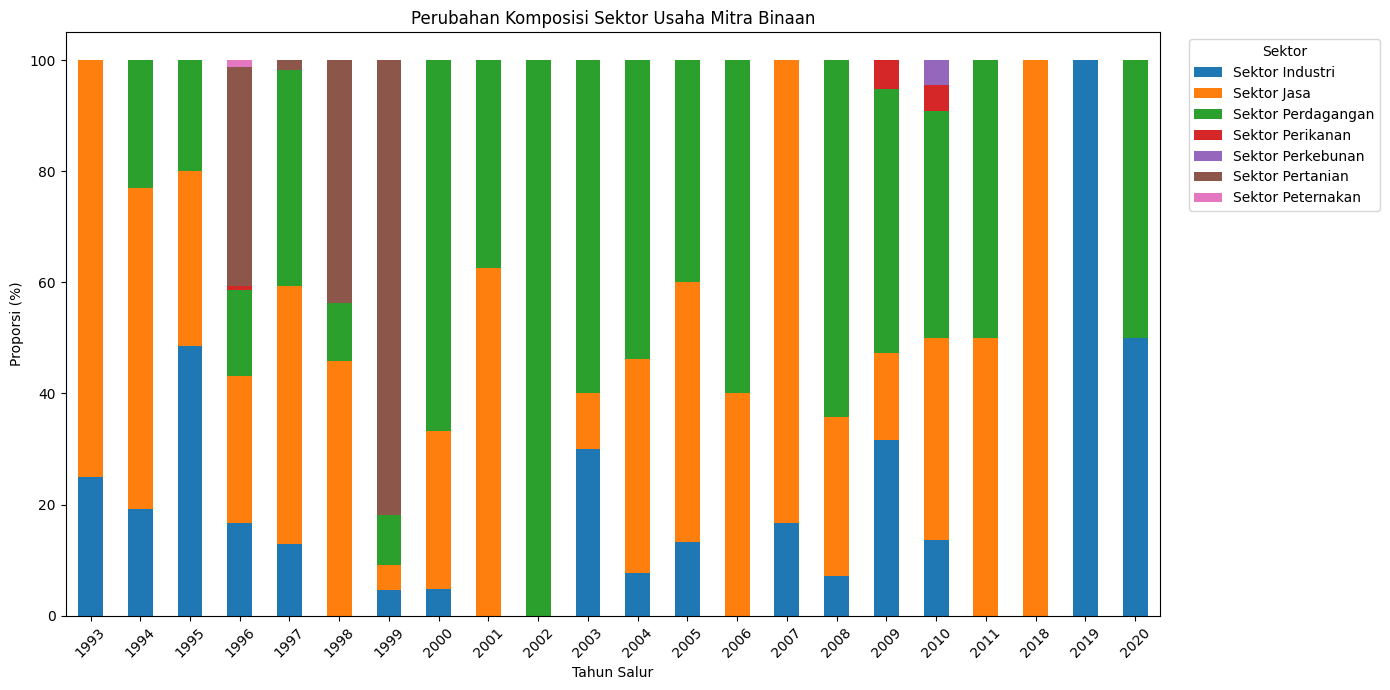

In [141]:
# ============================================================
# 34. VISUALISASI KOMPOSISI SEKTOR
# Tujuan:
# Melihat perubahan proporsi sektor usaha dari tahun ke tahun.
# ============================================================

proporsi_sektor.plot(       # Membuat grafik langsung dari data tabel proporsi persentase sektor
    kind="bar",             # Menentukan jenis grafik berupa diagram batang (bar chart)
    stacked=True,           # Mengaktifkan mode bertumpuk (stacked) agar persentase sektor menumpuk hingga mencapai 100%
    figsize=(14, 7)         # Mengatur ukuran dimensi gambar grafik dengan lebar 14 inci dan tinggi 7 inci
)                           # Menutup fungsi proporsi_sektor.plot

plt.title("Perubahan Komposisi Sektor Usaha Mitra Binaan") # Memberikan judul utama pada grafik
plt.xlabel("Tahun Salur") # Memberikan label keterangan pada sumbu X
plt.ylabel("Proporsi (%)") # Memberikan label keterangan pada sumbu Y
plt.xticks(rotation=45)   # Memutar teks label angka pada sumbu X sebesar 45 derajat agar lebih mudah dibaca

plt.legend(                # Menampilkan kotak legenda keterangan warna sektor
    title="Sektor",         # Memberikan judul pada kotak legenda
    bbox_to_anchor=(1.02, 1), # Mengatur koordinat posisi penempatan kotak legenda di luar area grafik (sebelah kanan atas)
    loc="upper left"        # Menentukan titik anchor pojok kiri atas dari kotak legenda
)                           # Menutup fungsi plt.legend

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

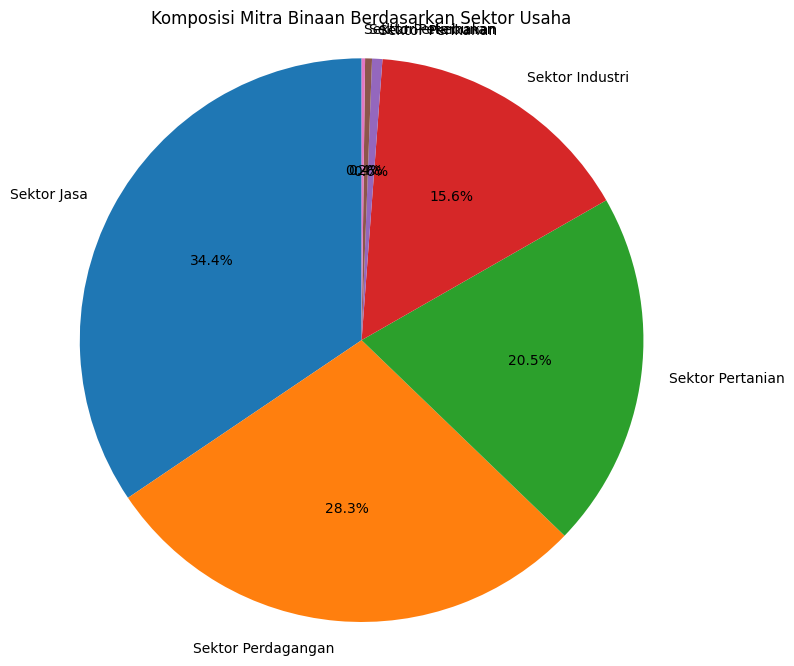

In [142]:
# ============================================================
# CELL 35 — DIAGRAM LINGKAR KOMPOSISI SEKTOR USAHA
# ============================================================

# Hitung jumlah mitra berdasarkan sektor
komposisi_sektor = df_clean['SEKTOR_ANALISIS'].value_counts() # Menghitung jumlah total mitra untuk setiap kategori sektor usaha

# Buat diagram lingkar
plt.figure(figsize=(8, 8)) # Membuat kanvas grafik baru dengan ukuran lebar dan tinggi 8 inci

plt.pie(                    # Membuat diagram lingkar (pie chart)
    komposisi_sektor.values, # Mengambil nilai angka jumlah mitra sebagai ukuran porsi lingkaran
    labels=komposisi_sektor.index, # Mengambil nama-nama sektor sebagai label teks keterangan porsi
    autopct='%1.1f%%',      # Menampilkan teks persentase nilai di dalam potongan lingkaran dengan 1 angka dibelakang koma
    startangle=90           # Mengatur sudut awal rotasi diagram lingkar mulai dari 90 derajat
)

plt.title('Komposisi Mitra Binaan Berdasarkan Sektor Usaha') # Memberikan judul utama pada diagram
plt.axis('equal')           # Menyamakan skala sumbu X dan Y agar bentuk lingkaran terlihat bulat sempurna
plt.show()                  # Menampilkan dan merender grafik ke layar

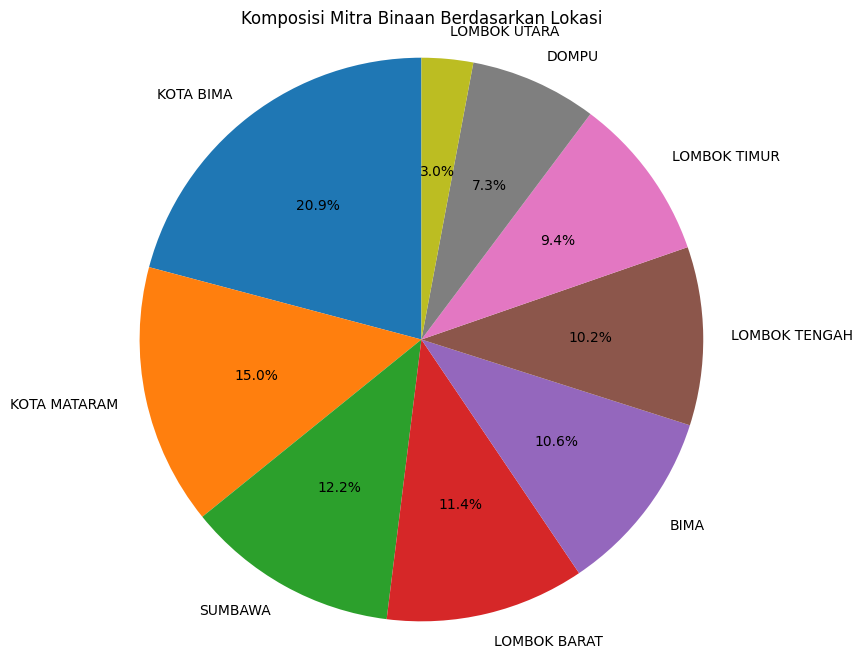

In [143]:
# ============================================================
# CELL 36 — DIAGRAM LINGKAR KOMPOSISI MITRA BERDASARKAN LOKASI
# ============================================================

# Hitung jumlah mitra berdasarkan lokasi
komposisi_lokasi = df_clean['LOKASI_ANALISIS'].value_counts() # Menghitung jumlah total mitra untuk setiap kategori lokasi wilayah

# Buat diagram lingkar
plt.figure(figsize=(8, 8)) # Membuat kanvas grafik baru dengan ukuran lebar dan tinggi 8 inci

plt.pie(                    # Membuat diagram lingkar (pie chart)
    komposisi_lokasi.values, # Mengambil nilai angka jumlah mitra sebagai ukuran porsi lingkaran
    labels=komposisi_lokasi.index, # Mengambil nama-nama lokasi sebagai label teks keterangan porsi
    autopct='%1.1f%%',      # Menampilkan teks persentase nilai di dalam potongan lingkaran dengan 1 angka dibelakang koma
    startangle=90           # Mengatur sudut awal rotasi diagram lingkar mulai dari 90 derajat
)

plt.title('Komposisi Mitra Binaan Berdasarkan Lokasi') # Memberikan judul utama pada diagram
plt.axis('equal')           # Menyamakan skala sumbu X dan Y agar bentuk lingkaran terlihat bulat sempurna
plt.show()                  # Menampilkan dan merender grafik ke layar

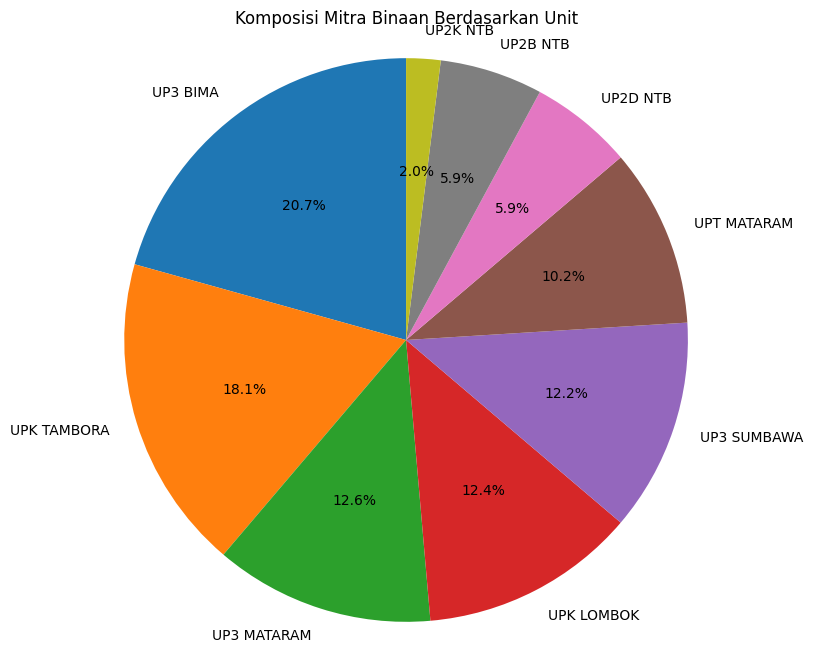

In [144]:
# ============================================================
# CELL 37 — DIAGRAM LINGKAR KOMPOSISI MITRA BERDASARKAN UNIT
# ============================================================

# Hitung jumlah mitra berdasarkan unit
komposisi_unit = df_clean['UNIT_ANALISIS'].value_counts() # Menghitung jumlah total mitra untuk setiap kategori unit PLN

# Buat diagram lingkar
plt.figure(figsize=(8, 8)) # Membuat kanvas grafik baru dengan ukuran lebar dan tinggi 8 inci

plt.pie(                    # Membuat diagram lingkar (pie chart)
    komposisi_unit.values,  # Mengambil nilai angka jumlah mitra sebagai ukuran porsi lingkaran
    labels=komposisi_unit.index, # Mengambil nama-nama unit sebagai label teks keterangan porsi
    autopct='%1.1f%%',      # Menampilkan teks persentase nilai di dalam potongan lingkaran dengan 1 angka dibelakang koma
    startangle=90           # Mengatur sudut awal rotasi diagram lingkar mulai dari 90 derajat
)

plt.title('Komposisi Mitra Binaan Berdasarkan Unit') # Memberikan judul utama pada diagram
plt.axis('equal')           # Menyamakan skala sumbu X dan Y agar bentuk lingkaran terlihat bulat sempurna
plt.show()                  # Menampilkan dan merender grafik ke layar

# Segmentasi K-Modes

In [145]:
# ============================================================
# CELL 38 — PERSIAPAN FITUR UNTUK K-MODES
# ============================================================

# Fitur yang digunakan untuk segmentasi
fitur_kmodes = [            # Mendefinisikan list nama kolom fitur yang akan digunakan dalam proses clustering K-Modes
    'SEKTOR_ANALISIS',      # Kolom fitur sektor usaha
    'LOKASI_ANALISIS',      # Kolom fitur lokasi wilayah
    'UNIT_ANALISIS'         # Kolom fitur unit PLN
]                           # Menutup list fitur_kmodes

# Membuat dataframe khusus clustering
df_cluster = df_clean[fitur_kmodes].copy() # Menyalin kolom-kolom fitur terpilih dari df_clean ke DataFrame baru khusus clustering

# Tampilkan 5 data pertama
df_cluster.head()           # Menampilkan 5 baris pertama dari DataFrame kluster untuk verifikasi awal

,SEKTOR_ANALISIS,LOKASI_ANALISIS,UNIT_ANALISIS
0,Sektor Industri,BIMA,UP3 BIMA
1,Sektor Industri,BIMA,UP3 BIMA
2,Sektor Industri,BIMA,UP3 BIMA
3,Sektor Industri,BIMA,UP3 BIMA
4,Sektor Industri,BIMA,UP3 BIMA


In [146]:
# ============================================================
# CELL 39 — CEK MISSING VALUE FITUR CLUSTERING
# ============================================================

# Cek jumlah data kosong pada setiap fitur
missing_cluster = df_cluster.isnull().sum() # Menghitung total nilai kosong (NaN) pada masing-masing kolom DataFrame kluster

print("Jumlah missing value:") # Mencetak teks label informasi ke layar
print(missing_cluster)      # Mencetak hasil penghitungan missing value per kolom

print("\nTotal baris data:", len(df_cluster)) # Mencetak informasi total keseluruhan baris data di dalam DataFrame kluster

Jumlah missing value:
SEKTOR_ANALISIS    0
LOKASI_ANALISIS    0
UNIT_ANALISIS      0
dtype: int64

Total baris data: 508


In [147]:
# ============================================================
# CELL 40 — CEK JUMLAH KATEGORI SETIAP FITUR
# ============================================================

for kolom in fitur_kmodes:  # Melakukan perulangan untuk setiap nama kolom fitur dalam daftar fitur_kmodes
    print(f"\n{kolom}")     # Mencetak nama kolom fitur yang sedang diperiksa dengan baris baru di depannya
    print("Jumlah kategori unik:", df_cluster[kolom].nunique()) # Mencetak jumlah variasi nilai unik yang ada pada kolom tersebut
    print("Daftar kategori:") # Mencetak teks label daftar kategori
    print(df_cluster[kolom].unique()) # Mencetak rincian seluruh nilai unik apa saja yang terkandung di dalam kolom tersebut


SEKTOR_ANALISIS
Jumlah kategori unik: 7
Daftar kategori:
<StringArray>
[   'Sektor Industri',        'Sektor Jasa', 'Sektor Perdagangan',
  'Sektor Perkebunan',   'Sektor Pertanian',   'Sektor Perikanan',
  'Sektor Peternakan']
Length: 7, dtype: string

LOKASI_ANALISIS
Jumlah kategori unik: 9
Daftar kategori:
<StringArray>
[         'BIMA',     'KOTA BIMA',  'KOTA MATARAM',  'LOMBOK BARAT',
       'SUMBAWA', 'LOMBOK TENGAH',  'LOMBOK TIMUR',  'LOMBOK UTARA',
         'DOMPU']
Length: 9, dtype: string

UNIT_ANALISIS
Jumlah kategori unik: 9
Daftar kategori:
<StringArray>
[   'UP3 BIMA',    'UP2D NTB',    'UP2B NTB',    'UP2K NTB', 'UP3 MATARAM',
 'UP3 SUMBAWA', 'UPT MATARAM',  'UPK LOMBOK', 'UPK TAMBORA']
Length: 9, dtype: string


In [148]:
# ============================================================
# CELL 41 — DISTRIBUSI KATEGORI FITUR CLUSTERING
# ============================================================

for kolom in fitur_kmodes:  # Melakukan perulangan untuk setiap kolom fitur dalam daftar fitur_kmodes
    print(f"\n{'='*50}")     # Mencetak garis pemisah estetika di konsol
    print(f"DISTRIBUSI {kolom}") # Mencetak judul nama kolom fitur yang sedang diperiksa
    print(f"{'='*50}")     # Mencetak garis pemisah penutup judul

    print(df_cluster[kolom].value_counts()) # Menghitung dan mencetak frekuensi kemunculan setiap kategori nilai pada kolom tersebut


DISTRIBUSI SEKTOR_ANALISIS
SEKTOR_ANALISIS
Sektor Jasa           175
Sektor Perdagangan    144
Sektor Pertanian      104
Sektor Industri        79
Sektor Perikanan        3
Sektor Peternakan       2
Sektor Perkebunan       1
Name: count, dtype: Int64

DISTRIBUSI LOKASI_ANALISIS
LOKASI_ANALISIS
KOTA BIMA        106
KOTA MATARAM      76
SUMBAWA           62
LOMBOK BARAT      58
BIMA              54
LOMBOK TENGAH     52
LOMBOK TIMUR      48
DOMPU             37
LOMBOK UTARA      15
Name: count, dtype: Int64

DISTRIBUSI UNIT_ANALISIS
UNIT_ANALISIS
UP3 BIMA       105
UPK TAMBORA     92
UP3 MATARAM     64
UPK LOMBOK      63
UP3 SUMBAWA     62
UPT MATARAM     52
UP2D NTB        30
UP2B NTB        30
UP2K NTB        10
Name: count, dtype: Int64


In [149]:
# ============================================================
# CELL 42 — INSTALL & IMPORT K-MODES
# ============================================================

# Install library kmodes jika belum tersedia
!pip install -q kmodes     # Mengunduh dan menginstal library K-Modes secara senyap (tanpa log teks panjang)

# Import model K-Modes
from kmodes.kmodes import KModes # Mengimpor kelas KModes untuk melakukan kluster data kategorikal

# Import metrik evaluasi
from sklearn.metrics import silhouette_score # Mengimpor fungsi silhouette_score untuk mengukur kualitas kluster

print("Library K-Modes berhasil disiapkan.") # Mencetak pesan konfirmasi bahwa proses impor pustaka sukses

Library K-Modes berhasil disiapkan.


In [150]:
# ============================================================
# CELL 43 — UJI JUMLAH CLUSTER (K) + SILHOUETTE
# ============================================================

# Data kategorikal asli untuk K-Modes
X_kmodes = df_cluster.values # Mengambil nilai array dari DataFrame kluster untuk diproses oleh K-Modes

# Membuat salinan untuk perhitungan silhouette
# Setiap kategori diubah menjadi kode numerik
X_silhouette = df_cluster.copy() # Membuat salinan DataFrame untuk dikonversi menjadi angka agar bisa dihitung skor siluetnya

for kolom in fitur_kmodes:  # Melakukan perulangan untuk setiap kolom fitur
    X_silhouette[kolom] = X_silhouette[kolom].astype('category').cat.codes # Mengubah tipe data teks menjadi kode angka kategori (integer)

# Konversi menjadi array numerik
X_silhouette = X_silhouette.to_numpy() # Mengubah DataFrame salinan kode angka menjadi format NumPy array

# Menyimpan hasil evaluasi
hasil_k = []                # Membuat list kosong untuk menampung kamus (dictionary) hasil evaluasi nilai K

# Uji K dari 2 sampai 6
for k in range(2, 7):       # Melakukan perulangan pengujian jumlah kluster (K) dari angka 2 sampai 6

    # Membuat model K-Modes
    model = KModes(         # Inisialisasi objek model K-Modes
        n_clusters=k,       # Menentukan jumlah kluster (K) yang diuji pada iterasi ini
        init='Huang',       # Menggunakan metode inisialisasi pusat kluster "Huang" yang efisien untuk data kategorikal
        n_init=10,          # Menentukan jumlah percobaan ulang inisialisasi model sebanyak 10 kali
        random_state=42,    # Mengunci seed acak agar hasil eksperimen konsisten/reprodusibel
        verbose=0           # Menonaktifkan log teks proses pelatihan model saat berjalan
    )

    # Melatih model dan mendapatkan label cluster
    cluster_labels = model.fit_predict(X_kmodes) # Melatih model K-Modes dan menghasilkan label kluster untuk setiap baris data

    # Cost dari K-Modes
    cost = model.cost_      # Mengambil nilai biaya (cost/dissimilarity) total dari model K-Modes

    # Silhouette Score menggunakan Hamming Distance
    silhouette = silhouette_score( # Menghitung skor kualitas kluster menggunakan jarak Hamming
        X_silhouette,       # Menggunakan array data numerik hasil encoding
        cluster_labels,     # Menggunakan label hasil prediksi kluster
        metric='hamming'    # Menentukan metrik jarak Hamming khusus untuk data kategori
    )

    # Simpan hasil
    hasil_k.append({        # Menambahkan kamus data hasil metrik evaluasi ke dalam list hasil_k
        'K': k,           # Menyimpan angka nilai K saat ini
        'Cost': cost,     # Menyimpan nilai cost model
        'Silhouette': silhouette # Menyimpan nilai silhouette score
    })

# Membuat tabel hasil evaluasi
hasil_k_df = pd.DataFrame(hasil_k) # Mengubah list hasil evaluasi menjadi DataFrame pandas

# Tampilkan hasil
hasil_k_df                  # Menampilkan tabel hasil pengujian nilai K (2-6) ke layar

,K,Cost,Silhouette
0,2,932.0,0.172339
1,3,721.0,0.291697
2,4,612.0,0.303902
3,5,563.0,0.348814
4,6,499.0,0.385260


In [151]:
# ============================================================
# CELL 44 — PERLUAS UJI JUMLAH CLUSTER
# ============================================================

# Menyimpan hasil pengujian K
hasil_k_luas = []           # Membuat list kosong untuk menampung hasil pengujian K dalam rentang yang lebih luas

# Uji K dari 2 sampai 10
for k in range(2, 11):      # Melakukan perulangan pengujian jumlah kluster dari angka 2 hingga 10

    # Membuat model K-Modes
    model = KModes(         # Inisialisasi objek model K-Modes untuk setiap iterasi K
        n_clusters=k,       # Menentukan jumlah kluster (K)
        init='Huang',       # Menggunakan metode inisialisasi pusat kluster "Huang"
        n_init=10,          # Mengatur jumlah percobaan ulang inisialisasi sebanyak 10 kali
        random_state=42,    # Mengunci seed acak agar hasil stabil
        verbose=0           # Menyembunyikan teks log proses pelatihan
    )

    # Training model
    cluster_labels = model.fit_predict(X_kmodes) # Melatih model K-Modes dan mendapatkan label prediksi kluster

    # Cost model
    cost = model.cost_      # Mengambil nilai cost model K-Modes saat ini

    # Silhouette Score
    silhouette = silhouette_score( # Menghitung skor kualitas siluet kluster
        X_silhouette,       # Menggunakan data array numerik
        cluster_labels,     # Menggunakan label hasil kluster
        metric='hamming'    # Menggunakan jarak Hamming untuk data kategorikal
    )

    # Simpan hasil
    hasil_k_luas.append({   # Menambahkan kamus hasil evaluasi ke dalam list hasil_k_luas
        'K': k,           # Menyimpan nilai K
        'Cost': cost,     # Menyimpan nilai cost
        'Silhouette': silhouette # Menyimpan nilai silhouette score
    })

# Jadikan dataframe
hasil_k_luas_df = pd.DataFrame(hasil_k_luas) # Mengubah list hasil pengujian luas menjadi DataFrame pandas

# Tampilkan hasil
hasil_k_luas_df             # Menampilkan tabel ringkasan pengujian K (2-10) ke layar

,K,Cost,Silhouette
0,2,932.0,0.172339
1,3,721.0,0.291697
2,4,612.0,0.303902
3,5,563.0,0.348814
4,6,499.0,0.385260
5,7,436.0,0.436180
6,8,393.0,0.460342
7,9,318.0,0.502200
8,10,286.0,0.554522


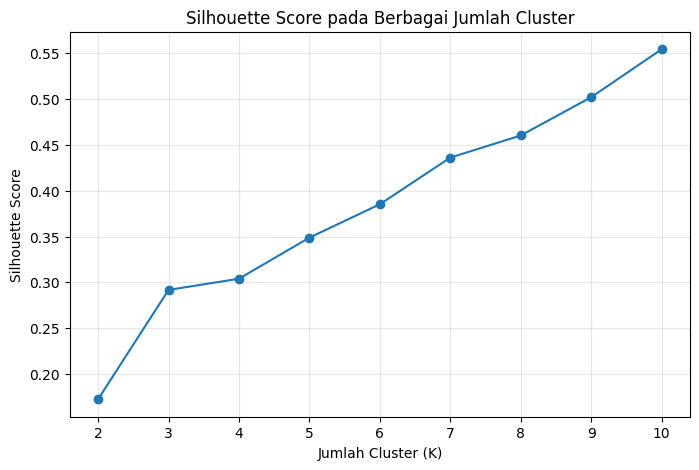

In [152]:
# ============================================================
# CELL 45 — GRAFIK SILHOUETTE SCORE
# ============================================================

plt.figure(figsize=(8, 5)) # Membuat kanvas grafik baru dengan ukuran lebar 8 inci dan tinggi 5 inci

plt.plot(                   # Membuat grafik garis (line plot)
    hasil_k_luas_df['K'], # Mengambil nilai jumlah K sebagai koordinat sumbu X
    hasil_k_luas_df['Silhouette'], # Mengambil nilai Silhouette Score sebagai koordinat sumbu Y
    marker='o'            # Menambahkan tanda titik lingkaran pada setiap titik data garis
)

plt.xlabel('Jumlah Cluster (K)') # Memberikan label keterangan pada sumbu X
plt.ylabel('Silhouette Score') # Memberikan label keterangan pada sumbu Y
plt.title('Silhouette Score pada Berbagai Jumlah Cluster') # Memberikan judul utama pada grafik

plt.xticks(range(2, 11))    # Mengatur titik angka tick sumbu X agar tampil dari angka 2 sampai 10 secara utuh
plt.grid(True, alpha=0.3) # Menampilkan garis latar belakang (grid) dengan transparansi 0.3

plt.show()                  # Menampilkan dan merender grafik ke layar

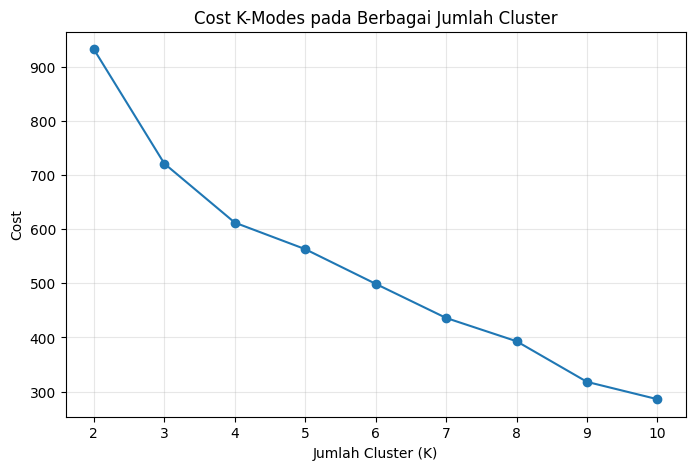

In [153]:
# ============================================================
# CELL 46 — GRAFIK COST K-MODES
# ============================================================

plt.figure(figsize=(8, 5)) # Membuat kanvas grafik baru dengan ukuran lebar 8 inci dan tinggi 5 inci

plt.plot(                   # Membuat grafik garis (line plot)
    hasil_k_luas_df['K'], # Mengambil nilai jumlah K sebagai koordinat sumbu X
    hasil_k_luas_df['Cost'], # Mengambil nilai Cost model sebagai koordinat sumbu Y
    marker='o'            # Menambahkan tanda titik lingkaran pada setiap titik data garis
)

plt.xlabel('Jumlah Cluster (K)') # Memberikan label keterangan pada sumbu X
plt.ylabel('Cost')          # Memberikan label keterangan pada sumbu Y
plt.title('Cost K-Modes pada Berbagai Jumlah Cluster') # Memberikan judul utama pada grafik

plt.xticks(range(2, 11))    # Mengatur titik angka tick sumbu X dari angka 2 sampai 10
plt.grid(True, alpha=0.3) # Menampilkan garis latar belakang (grid) dengan transparansi 0.3

plt.show()                  # Menampilkan dan merender grafik ke layar

In [154]:
# ============================================================
# CELL 47 — UJI STABILITAS K-MODES
# ============================================================

# Kandidat K yang akan diuji
k_candidates = [7, 8, 9, 10] # Menentukan daftar nilai K kandidat yang akan diuji tingkat kestabilannya

# Beberapa random state untuk menguji kestabilan hasil
random_states = [10, 20, 30, 40, 42] # Menentukan variasi seed acak untuk melihat konsistensi model

hasil_stabilitas = []       # Membuat list kosong untuk menampung ringkasan hasil uji stabilitas

for k in k_candidates:      # Melakukan perulangan untuk setiap nilai K kandidat

    silhouette_scores = []  # List penampung skor siluet dari berbagai random state
    costs = []              # List penampung nilai cost dari berbagai random state

    for seed in random_states: # Melakukan perulangan untuk setiap variasi seed acak

        # Model K-Modes
        model = KModes(     # Inisialisasi model K-Modes dengan seed acak yang berbeda-beda
            n_clusters=k,   # Menentukan jumlah kluster K
            init='Huang',   # Metode inisialisasi pusat kluster Huang
            n_init=10,      # Jumlah percobaan inisialisasi 10 kali
            random_state=seed, # Menggunakan seed acak yang sedang diiterasi
            verbose=0       # Menyembunyikan teks log proses
        )

        # Training
        labels = model.fit_predict(X_kmodes) # Melatih model dan mendapatkan label kluster

        # Cost
        costs.append(model.cost_) # Menambahkan nilai cost model ke dalam list costs

        # Silhouette
        silhouette = silhouette_score( # Menghitung skor siluet kluster
            X_silhouette,   # Data numerik untuk evaluasi
            labels,         # Label hasil kluster
            metric='hamming' # Metrik jarak Hamming
        )

        silhouette_scores.append(silhouette) # Menambahkan skor siluet ke dalam list

    # Simpan rata-rata dan standar deviasi
    hasil_stabilitas.append({ # Menyimpan ringkasan statistik (rata-rata dan deviasi) ke list hasil_stabilitas
        'K': k,           # Menyimpan angka K
        'Mean Silhouette': np.mean(silhouette_scores), # Menghitung rata-rata skor siluet dari berbagai seed
        'Std Silhouette': np.std(silhouette_scores), # Menghitung standar deviasi skor siluet
        'Mean Cost': np.mean(costs) # Menghitung rata-rata nilai cost model
    })

# Tampilkan hasil
hasil_stabilitas_df = pd.DataFrame(hasil_stabilitas) # Mengubah hasil uji stabilitas menjadi DataFrame pandas

hasil_stabilitas_df         # Menampilkan tabel ringkasan uji stabilitas ke layar

,K,Mean Silhouette,Std Silhouette,Mean Cost
0,7,0.394250,0.029960,450.4
1,8,0.444828,0.048156,383.4
2,9,0.500797,0.032032,329.0
3,10,0.526680,0.031126,301.0


In [155]:
# ============================================================
# CELL 48 — CEK UKURAN CLUSTER K=9 DAN K=10
# ============================================================

hasil_ukuran_cluster = {}   # Membuat dictionary kosong untuk menampung data ukuran anggota kluster

for k in [9, 10]:           # Melakukan perulangan khusus untuk menguji nilai K sama dengan 9 dan 10

    # Membuat model K-Modes
    model = KModes(         # Inisialisasi model K-Modes
        n_clusters=k,       # Menentukan jumlah kluster K (9 atau 10)
        init='Huang',       # Metode inisialisasi pusat kluster Huang
        n_init=10,          # Jumlah percobaan ulang inisialisasi 10 kali
        random_state=42,    # Mengunci seed acak
        verbose=0           # Menyembunyikan teks log proses
    )

    # Menentukan cluster
    labels = model.fit_predict(X_kmodes) # Melatih model dan menghasilkan label kluster

    # Hitung jumlah anggota setiap cluster
    jumlah_cluster = pd.Series(labels).value_counts().sort_index() # Menghitung total anggota data di setiap nomor kluster dan mengurutkannya

    # Simpan hasil
    hasil_ukuran_cluster[k] = jumlah_cluster # Menyimpan data Series jumlah anggota ke dalam dictionary berdasarkan K

    print(f"\n{'='*50}")     # Mencetak garis pemisah estetika di konsol
    print(f"UKURAN CLUSTER — K = {k}") # Mencetak judul informasi ukuran kluster untuk K tertentu
    print(f"{'='*50}")     # Mencetak garis pemisah penutup

    print(jumlah_cluster)   # Mencetak rincian jumlah anggota tiap nomor kluster ke layar

    print(f"\nJumlah anggota minimum : {jumlah_cluster.min()}") # Mencetak jumlah anggota terkecil dalam satu kluster
    print(f"Jumlah anggota maksimum : {jumlah_cluster.max()}") # Mencetak jumlah anggota terbesar dalam satu kluster


UKURAN CLUSTER — K = 9
0    115
1     74
2     64
3     20
4     62
5     62
6     33
7     28
8     50
Name: count, dtype: int64

Jumlah anggota minimum : 20
Jumlah anggota maksimum : 115

UKURAN CLUSTER — K = 10
0    68
1    43
2    59
3    42
4    67
5    30
6    62
7    60
8    52
9    25
Name: count, dtype: int64

Jumlah anggota minimum : 25
Jumlah anggota maksimum : 68


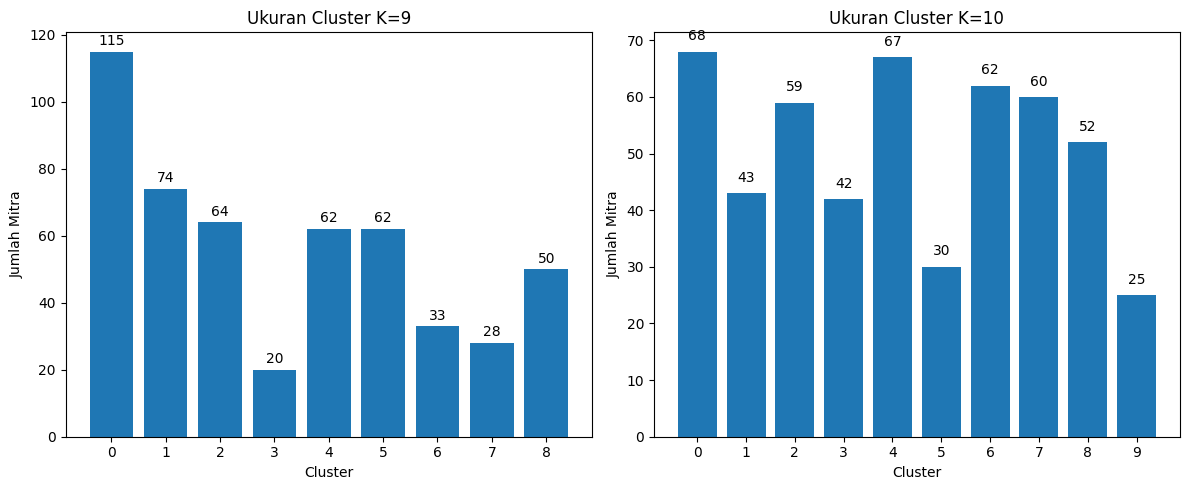

In [156]:
# ============================================================
# CELL 49 — VISUALISASI UKURAN CLUSTER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Membuat kanvas subplot dengan 1 baris dan 2 kolom grafik, ukuran 12x5 inci

for ax, k in zip(axes, [9, 10]): # Melakukan perulangan untuk menggambar grafik pada masing-masing sumbu (axis) untuk K=9 dan K=10

    jumlah_cluster = hasil_ukuran_cluster[k] # Mengambil data jumlah anggota kluster berdasarkan nilai K

    ax.bar(                 # Membuat diagram batang (bar chart) pada sumbu ax tertentu
        jumlah_cluster.index.astype(str), # Mengambil label nomor kluster sebagai kategori pada sumbu X
        jumlah_cluster.values # Mengambil angka jumlah anggota sebagai tinggi batang pada sumbu Y
    )

    ax.set_title(f'Ukuran Cluster K={k}') # Memberikan judul pada masing-masing sub-grafik
    ax.set_xlabel('Cluster') # Memberikan label keterangan pada sumbu X
    ax.set_ylabel('Jumlah Mitra') # Memberikan label keterangan pada sumbu Y

    # Tampilkan angka di atas batang
    for i, nilai in enumerate(jumlah_cluster.values): # Melakukan perulangan untuk menempatkan teks angka di atas setiap batang
        ax.text(            # Menambahkan teks anotasi angka nilai
            i,              # Koordinat posisi indeks sumbu X batang
            nilai + 2,      # Koordinat posisi sumbu Y (sedikit di atas tinggi batang)
            str(nilai),     # Teks angka jumlah mitra yang ditampilkan
            ha='center'     # Mengatur posisi teks agar berada persis di tengah secara horizontal
        )

plt.tight_layout()        # Menyesuaikan tata letak elemen grafik secara otomatis agar proporsional
plt.show()                # Menampilkan dan merender grafik ke layar

In [157]:
# ============================================================
# CELL 50 — MODEL K-MODES FINAL (K = 10)
# ============================================================

# Model K-Modes final
kmodes_final = KModes(      # Inisialisasi model K-Modes akhir dengan jumlah kluster optimal K = 10
    n_clusters=10,          # Menetapkan jumlah kluster final sebanyak 10 kelompok
    init='Huang',           # Metode inisialisasi pusat kluster Huang
    n_init=10,              # Jumlah percobaan ulang inisialisasi 10 kali
    random_state=42,        # Mengunci seed acak agar hasil akhir konsisten
    verbose=0               # Menyembunyikan teks log proses
)

# Training model dan mendapatkan label cluster
cluster_labels_final = kmodes_final.fit_predict(X_kmodes) # Melatih model final dan menghasilkan label kluster untuk seluruh data

# Tambahkan label cluster ke dataframe clustering
df_cluster['CLUSTER'] = cluster_labels_final # Menyimpan hasil label kluster ke dalam kolom baru bernama "CLUSTER" di DataFrame df_cluster

# Tampilkan 10 data pertama
df_cluster.tail(10)         # Menampilkan 10 baris data terakhir dari DataFrame kluster untuk verifikasi hasil akhir

,SEKTOR_ANALISIS,LOKASI_ANALISIS,UNIT_ANALISIS,CLUSTER
498,Sektor Perdagangan,KOTA BIMA,UPK TAMBORA,9
499,Sektor Perdagangan,KOTA BIMA,UPK TAMBORA,9
500,Sektor Perdagangan,KOTA BIMA,UPK TAMBORA,9
501,Sektor Perdagangan,KOTA BIMA,UPK TAMBORA,9
502,Sektor Perdagangan,KOTA BIMA,UPK TAMBORA,9
503,Sektor Perdagangan,KOTA BIMA,UPK TAMBORA,9
504,Sektor Perikanan,KOTA BIMA,UPK TAMBORA,9
505,Sektor Perdagangan,KOTA MATARAM,UP3 MATARAM,1
506,Sektor Industri,LOMBOK BARAT,UP3 MATARAM,6
507,Sektor Industri,KOTA MATARAM,UP3 MATARAM,1


In [158]:
# ============================================================
# CELL 51 — DISTRIBUSI CLUSTER FINAL
# ============================================================

distribusi_cluster = (      # Menyimpan hasil perhitungan jumlah anggota tiap kluster final
    df_cluster['CLUSTER'] # Mengambil data dari kolom label CLUSTER
    .value_counts()       # Menghitung frekuensi jumlah data pada setiap nomor kluster
    .sort_index()         # Mengurutkan hasil berdasarkan nomor indeks kluster (0 sampai 9)
)

# Hitung persentase
persentase_cluster = (      # Menghitung proporsi persentase anggota setiap kluster
    distribusi_cluster / len(df_cluster) * 100 # Membagi jumlah anggota kluster dengan total baris data lalu dikalikan 100
)

# Gabungkan menjadi tabel
ringkasan_cluster = pd.DataFrame({ # Membuat DataFrame ringkasan hasil akhir kluster
    'Jumlah Mitra': distribusi_cluster, # Kolom tabel berisi angka total jumlah mitra per kluster
    'Persentase (%)': persentase_cluster.round(2) # Kolom tabel berisi persentase dengan pembulatan 2 desimal
})

ringkasan_cluster           # Menampilkan tabel ringkasan distribusi kluster final ke layar

,Jumlah Mitra,Persentase (%)
CLUSTER,,
0,68,13.39
1,43,8.46
2,59,11.61
3,42,8.27
4,67,13.19
5,30,5.91
6,62,12.20
7,60,11.81
8,52,10.24


In [159]:
# ============================================================
# CELL 52 — KARAKTERISTIK / MODUS SETIAP CLUSTER
# ============================================================

# Menentukan kategori yang paling sering muncul
# pada setiap fitur di setiap cluster
profil_cluster = (          # Menyimpan tabel ringkasan modus kategori fitur untuk setiap kluster
    df_cluster              # Menggunakan DataFrame kluster utama
    .groupby('CLUSTER')[fitur_kmodes] # Mengelompokkan data berdasarkan nomor kluster lalu memilih kolom-kolom fitur K-Modes
    .agg(lambda x: x.mode().iloc[0]) # Mengambil nilai modus (kategori yang paling sering muncul) pertama untuk setiap fitur
)

# Tambahkan jumlah anggota
profil_cluster.insert(      # Menambahkan kolom baru ke dalam DataFrame profil_cluster
    1,                      # Menyisipkan kolom pada posisi indeks kolom ke-1
    'Jumlah Mitra',         # Nama judul kolom baru untuk total jumlah anggota mitra
    df_cluster['CLUSTER'].value_counts().sort_index() # Menghitung dan mengurutkan jumlah anggota setiap kluster
)

# Tambahkan persentase anggota
profil_cluster.insert(      # Menambahkan kolom kedua ke dalam DataFrame profil_cluster
    2,                      # Menyisipkan kolom pada posisi indeks kolom ke-2
    'Persentase (%)',       # Nama judul kolom baru untuk proporsi persentase anggota
    (
        df_cluster['CLUSTER'] # Mengambil data kolom kluster
        .value_counts()     # Menghitung jumlah anggota per kluster
        .sort_index()       # Mengurutkan berdasarkan nomor kluster
        / len(df_cluster) * 100 # Membagi dengan total data lalu dikalikan 100 untuk mendapatkan persentase
    ).round(2)              # Melakukan pembulatan hasil persentase hingga 2 desimal
)

profil_cluster              # Menampilkan tabel profil karakteristik modus kluster ke layar

,SEKTOR_ANALISIS,Jumlah Mitra,Persentase (%),LOKASI_ANALISIS,UNIT_ANALISIS
CLUSTER,,,,,
0,Sektor Jasa,68,13.39,SUMBAWA,UP3 SUMBAWA
1,Sektor Perdagangan,43,8.46,KOTA MATARAM,UP2B NTB
2,Sektor Industri,59,11.61,DOMPU,UPK TAMBORA
3,Sektor Industri,42,8.27,BIMA,UP3 BIMA
4,Sektor Jasa,67,13.19,KOTA BIMA,UP3 BIMA
5,Sektor Jasa,30,5.91,KOTA MATARAM,UP2D NTB
6,Sektor Pertanian,62,12.20,LOMBOK BARAT,UP3 MATARAM
7,Sektor Pertanian,60,11.81,LOMBOK TIMUR,UPK LOMBOK
8,Sektor Pertanian,52,10.24,LOMBOK TENGAH,UPT MATARAM


In [160]:
# ============================================================
# CELL 53 — KOMPOSISI FITUR DALAM SETIAP CLUSTER
# ============================================================

for kolom in fitur_kmodes:  # Melakukan perulangan untuk setiap kolom fitur dalam daftar fitur_kmodes

    print(f"\n{'='*60}")     # Mencetak garis pemisah estetika di konsol
    print(f"KOMPOSISI {kolom} PADA SETIAP CLUSTER") # Mencetak judul rincian nama fitur yang sedang diproses
    print(f"{'='*60}")     # Mencetak garis pemisah penutup judul

    tabel = pd.crosstab(    # Membuat tabel silang (crosstab) untuk melihat sebaran kategori fitur di dalam setiap kluster
        df_cluster['CLUSTER'], # Mengatur nomor kluster sebagai baris tabel
        df_cluster[kolom],  # Mengatur kategori fitur sebagai kolom tabel
        normalize='index'   # Melakukan normalisasi per baris agar nilai berubah menjadi proporsi
    ) * 100                 # Mengalikan proporsi dengan 100 untuk mengubahnya menjadi bentuk persentase (%)

    print(tabel.round(2))   # Mencetak tabel komposisi persentase dengan pembulatan 2 desimal ke layar


KOMPOSISI SEKTOR_ANALISIS PADA SETIAP CLUSTER
SEKTOR_ANALISIS  Sektor Industri  Sektor Jasa  Sektor Perdagangan  \
CLUSTER                                                             
0                           5.88        72.06               17.65   
1                           2.33         6.98               60.47   
2                          57.63        18.64               20.34   
3                          71.43         9.52               19.05   
4                           0.00        53.73               46.27   
5                          16.67        83.33                0.00   
6                           6.45        16.13               17.74   
7                           1.67        35.00               18.33   
8                           0.00        30.77               17.31   
9                           0.00         0.00               96.00   

SEKTOR_ANALISIS  Sektor Perikanan  Sektor Perkebunan  Sektor Pertanian  \
CLUSTER                                           

In [161]:
# ============================================================
# CELL 54 — KEKUATAN DOMINASI KARAKTERISTIK CLUSTER
# ============================================================

ringkasan_dominasi = []     # Membuat list kosong untuk menampung data hasil analisis kekuatan dominasi

for cluster in sorted(df_cluster['CLUSTER'].unique()): # Melakukan perulangan untuk setiap nomor kluster yang unik dan terurut

    data_cluster = df_cluster[ # Menyaring baris data yang hanya termasuk dalam nomor kluster tertentu
        df_cluster['CLUSTER'] == cluster
    ]

    hasil = {               # Membuat dictionary untuk menyimpan informasi ringkasan kluster saat ini
        'CLUSTER': cluster, # Menyimpan nomor kluster
        'JUMLAH MITRA': len(data_cluster) # Menyimpan total jumlah anggota mitra dalam kluster tersebut
    }

    for kolom in fitur_kmodes: # Melakukan perulangan untuk setiap kolom fitur

        # Kategori paling dominan
        modus = data_cluster[kolom].mode().iloc[0] # Mencari kategori nilai yang paling sering muncul (modus)

        # Persentase kategori dominan
        persentase = (      # Menghitung seberapa besar persentase kemunculan kategori dominan tersebut
            data_cluster[kolom].value_counts(normalize=True).iloc[0]
            * 100
        )

        hasil[f'{kolom} DOMINAN'] = modus # Menyimpan nama kategori dominan ke dictionary hasil
        hasil[f'% {kolom} DOMINAN'] = round(persentase, 2) # Menyimpan nilai persentase dominasi yang dibulatkan 2 desimal

    ringkasan_dominasi.append(hasil) # Menambahkan dictionary hasil kluster ke dalam list ringkasan_dominasi

ringkasan_dominasi_df = pd.DataFrame(ringkasan_dominasi) # Mengubah list ringkasan menjadi DataFrame pandas

ringkasan_dominasi_df       # Menampilkan tabel ringkasan kekuatan dominasi karakteristik kluster ke layar

,CLUSTER,JUMLAH MITRA,SEKTOR_ANALISIS DOMINAN,% SEKTOR_ANALISIS DOMINAN,LOKASI_ANALISIS DOMINAN,% LOKASI_ANALISIS DOMINAN,UNIT_ANALISIS DOMINAN,% UNIT_ANALISIS DOMINAN
0,0,68,Sektor Jasa,72.06,SUMBAWA,91.18,UP3 SUMBAWA,91.18
1,1,43,Sektor Perdagangan,60.47,KOTA MATARAM,97.67,UP2B NTB,69.77
2,2,59,Sektor Industri,57.63,DOMPU,62.71,UPK TAMBORA,100.00
3,3,42,Sektor Industri,71.43,BIMA,66.67,UP3 BIMA,100.00
4,4,67,Sektor Jasa,53.73,KOTA BIMA,100.00,UP3 BIMA,94.03
5,5,30,Sektor Jasa,83.33,KOTA MATARAM,100.00,UP2D NTB,100.00
6,6,62,Sektor Pertanian,59.68,LOMBOK BARAT,93.55,UP3 MATARAM,100.00
7,7,60,Sektor Pertanian,41.67,LOMBOK TIMUR,80.00,UPK LOMBOK,100.00
8,8,52,Sektor Pertanian,51.92,LOMBOK TENGAH,100.00,UPT MATARAM,100.00
9,9,25,Sektor Perdagangan,96.00,KOTA BIMA,64.00,UPK TAMBORA,100.00


In [162]:
# ============================================================
# CELL 55 — CEK HUBUNGAN LOKASI DAN UNIT
# ============================================================

# Tabel silang lokasi dan unit
crosstab_lokasi_unit = pd.crosstab( # Membuat tabel kontingensi (silang) frekuensi antara kolom lokasi dan unit PLN
    df_cluster['LOKASI_ANALISIS'], # Mengatur kolom lokasi sebagai sumbu baris
    df_cluster['UNIT_ANALISIS'] # Mengatur kolom unit sebagai sumbu kolom
)

print("Hubungan antara LOKASI dan UNIT:") # Mencetak label judul informasi ke konsol
display(crosstab_lokasi_unit) # Menampilkan tabel silang lokasi dan unit ke layar

Hubungan antara LOKASI dan UNIT:


UNIT_ANALISIS,UP2B NTB,UP2D NTB,UP2K NTB,UP3 BIMA,UP3 MATARAM,UP3 SUMBAWA,UPK LOMBOK,UPK TAMBORA,UPT MATARAM
LOKASI_ANALISIS,,,,,,,,,
BIMA,0,0,0,28,0,0,0,26,0
DOMPU,0,0,0,0,0,0,0,37,0
KOTA BIMA,0,0,0,77,0,0,0,29,0
KOTA MATARAM,30,30,10,0,6,0,0,0,0
LOMBOK BARAT,0,0,0,0,58,0,0,0,0
LOMBOK TENGAH,0,0,0,0,0,0,0,0,52
LOMBOK TIMUR,0,0,0,0,0,0,48,0,0
LOMBOK UTARA,0,0,0,0,0,0,15,0,0
SUMBAWA,0,0,0,0,0,62,0,0,0


In [163]:
# ============================================================
# CELL 56 — PROPORSI UNIT DALAM SETIAP LOKASI
# ============================================================

proporsi_lokasi_unit = pd.crosstab( # Membuat tabel silang untuk menghitung proporsi persentase unit di dalam tiap lokasi
    df_cluster['LOKASI_ANALISIS'], # Kolom lokasi wilayah
    df_cluster['UNIT_ANALISIS'], # Kolom unit PLN
    normalize='index'       # Melakukan normalisasi per baris (lokasi) agar total baris menjadi 1 (100%)
) * 100                       # Mengalikan dengan angka 100 untuk mengubahnya menjadi bentuk persentase (%)

display(proporsi_lokasi_unit.round(2)) # Menampilkan tabel proporsi unit per lokasi dengan pembulatan 2 desimal ke layar

UNIT_ANALISIS,UP2B NTB,UP2D NTB,UP2K NTB,UP3 BIMA,UP3 MATARAM,UP3 SUMBAWA,UPK LOMBOK,UPK TAMBORA,UPT MATARAM
LOKASI_ANALISIS,,,,,,,,,
BIMA,0.00,0.00,0.00,51.85,0.00,0.0,0.0,48.15,0.0
DOMPU,0.00,0.00,0.00,0.00,0.00,0.0,0.0,100.00,0.0
KOTA BIMA,0.00,0.00,0.00,72.64,0.00,0.0,0.0,27.36,0.0
KOTA MATARAM,39.47,39.47,13.16,0.00,7.89,0.0,0.0,0.00,0.0
LOMBOK BARAT,0.00,0.00,0.00,0.00,100.00,0.0,0.0,0.00,0.0
LOMBOK TENGAH,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,100.0
LOMBOK TIMUR,0.00,0.00,0.00,0.00,0.00,0.0,100.0,0.00,0.0
LOMBOK UTARA,0.00,0.00,0.00,0.00,0.00,0.0,100.0,0.00,0.0
SUMBAWA,0.00,0.00,0.00,0.00,0.00,100.0,0.0,0.00,0.0


In [164]:
# ============================================================
# CELL 57 — UJI ASOSIASI LOKASI DAN UNIT
# ============================================================

from scipy.stats import chi2_contingency # Mengimpor fungsi uji statistik Chi-Square contingency dari library SciPy

# Tabel kontingensi
tabel_kontingensi = pd.crosstab( # Membuat tabel frekuensi silang antara lokasi dan unit
    df_cluster['LOKASI_ANALISIS'],
    df_cluster['UNIT_ANALISIS']
)

# Uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(tabel_kontingensi) # Menjalankan uji Chi-Square untuk melihat signifikansi hubungan

# Ukuran tabel
n = tabel_kontingensi.to_numpy().sum() # Menghitung total keseluruhan sampel data pengamatan
r, k = tabel_kontingensi.shape # Menghitung jumlah baris (r) dan kolom (k) dari tabel kontingensi

# Cramer's V
cramers_v = np.sqrt(        # Menghitung koefisien ukuran asosiasi Cramer's V
    (chi2 / n) / min(r - 1, k - 1)
)

print("Hasil Uji Hubungan LOKASI dan UNIT") # Mencetak teks judul laporan hasil uji
print("=" * 50)             # Mencetak garis pemisah estetika
print(f"Chi-Square : {chi2:.4f}") # Mencetak nilai statistik Chi-Square dengan 4 desimal
print(f"p-value    : {p_value:.10f}") # Mencetak nilai signifikansi p-value dengan 10 desimal
print(f"Cramer's V : {cramers_v:.4f}") # Mencetak nilai kekuatan asosiasi Cramer's V dengan 4 desimal

Hasil Uji Hubungan LOKASI dan UNIT
Chi-Square : 2606.1230
p-value    : 0.0000000000
Cramer's V : 0.8008


In [165]:
# ============================================================
# CELL 58 — MODEL A: SEKTOR + LOKASI
# ============================================================

# Fitur Model A
fitur_model_A = [           # Mendefinisikan daftar fitur alternatif Model A yang hanya menggunakan Sektor dan Lokasi
    'SEKTOR_ANALISIS',
    'LOKASI_ANALISIS'
]

# Membuat data clustering
df_model_A = df_clean[fitur_model_A].copy() # Menyalin kolom fitur Model A dari DataFrame utama ke DataFrame baru

# Encoding numerik hanya untuk perhitungan silhouette
X_model_A_silhouette = df_model_A.copy() # Membuat salinan data untuk dikonversi menjadi angka demi evaluasi siluet

for kolom in fitur_model_A: # Melakukan perulangan untuk mengubah tipe data teks kategori menjadi kode angka integer
    X_model_A_silhouette[kolom] = (
        X_model_A_silhouette[kolom]
        .astype('category')
        .cat.codes
    )

X_model_A_silhouette = X_model_A_silhouette.to_numpy() # Mengubah DataFrame salinan kode angka menjadi NumPy array

# Data kategorikal asli untuk K-Modes
X_model_A = df_model_A.to_numpy() # Mengambil array data kategorikal asli untuk diproses oleh algoritma K-Modes

print("Fitur Model A:")        # Mencetak label informasi fitur Model A
print(fitur_model_A)

print("\nJumlah data:", len(df_model_A)) # Mencetak total jumlah baris data yang diproses pada Model A

Fitur Model A:
['SEKTOR_ANALISIS', 'LOKASI_ANALISIS']

Jumlah data: 508


In [166]:
# ============================================================
# CELL 59 — EVALUASI MODEL A
# ============================================================

hasil_model_A = []          # Membuat list kosong untuk menampung hasil metrik evaluasi Model A

for k in range(2, 11):      # Melakukan perulangan pengujian jumlah kluster K dari angka 2 sampai 10

    model = KModes(         # Inisialisasi objek model K-Modes untuk setiap iterasi K
        n_clusters=k,       # Menentukan jumlah kluster K
        init='Huang',       # Metode inisialisasi pusat kluster Huang
        n_init=10,          # Jumlah percobaan ulang inisialisasi 10 kali
        random_state=42,    # Mengunci seed acak agar hasil konsisten
        verbose=0           # Menyembunyikan teks log proses pelatihan
    )

    labels = model.fit_predict(X_model_A) # Melatih model K-Modes dan menghasilkan label prediksi kluster

    silhouette = silhouette_score( # Menghitung skor kualitas kluster menggunakan jarak Hamming
        X_model_A_silhouette,
        labels,
        metric='hamming'
    )

    hasil_model_A.append({  # Menyimpan hasil metrik evaluasi ke dalam list hasil_model_A
        'K': k,           # Nilai K
        'Cost': model.cost_, # Nilai cost model
        'Silhouette': silhouette # Nilai silhouette score
    })

hasil_model_A_df = pd.DataFrame(hasil_model_A) # Mengubah list hasil evaluasi Model A menjadi DataFrame pandas

hasil_model_A_df            # Menampilkan tabel hasil pengujian evaluasi Model A ke layar

,K,Cost,Silhouette
0,2,576.0,0.227625
1,3,460.0,0.390592
2,4,362.0,0.448923
3,5,336.0,0.373923
4,6,319.0,0.375740
5,7,280.0,0.324478
6,8,263.0,0.320799
7,9,241.0,0.357457
8,10,210.0,0.433751


In [167]:
# ============================================================
# CELL 60 — UJI STABILITAS MODEL A (K = 4)
# ============================================================

# Beberapa random state untuk menguji kestabilan
random_states = [10, 20, 30, 40, 42] # Menentukan variasi seed acak untuk melihat tingkat konsistensi model A

silhouette_scores_A = []    # List penampung skor siluet untuk berbagai seed
costs_A = []                # List penampung nilai cost untuk berbagai seed

for seed in random_states:  # Melakukan perulangan untuk setiap nilai seed acak

    # Model K-Modes dengan K=4
    model = KModes(         # Inisialisasi model K-Modes dengan K tetap bernilai 4
        n_clusters=4,
        init='Huang',
        n_init=10,
        random_state=seed,  # Menggunakan seed acak yang sedang diiterasi
        verbose=0
    )

    # Training
    labels = model.fit_predict(X_model_A) # Melatih model dan mendapatkan label kluster

    # Cost
    costs_A.append(model.cost_) # Menambahkan nilai cost ke dalam list costs_A

    # Silhouette
    silhouette = silhouette_score( # Menghitung skor siluet kluster Model A
        X_model_A_silhouette,
        labels,
        metric='hamming'
    )

    silhouette_scores_A.append(silhouette) # Menambahkan skor siluet ke dalam list

# Ringkasan stabilitas
hasil_stabilitas_A = pd.DataFrame({ # Membuat DataFrame tabel ringkasan uji stabilitas Model A
    'Random State': random_states,
    'Silhouette': silhouette_scores_A,
    'Cost': costs_A
})

display(hasil_stabilitas_A)   # Menampilkan tabel hasil uji stabilitas Model A ke layar

print("\nRINGKASAN")          # Mencetak teks label ringkasan statistik
print("=" * 50)
print(f"Mean Silhouette : {np.mean(silhouette_scores_A):.4f}") # Mencetak nilai rata-rata skor siluet
print(f"Std Silhouette  : {np.std(silhouette_scores_A):.4f}") # Mencetak nilai standar deviasi skor siluet
print(f"Mean Cost       : {np.mean(costs_A):.2f}") # Mencetak nilai rata-rata cost model

,Random State,Silhouette,Cost
0,10,0.389211,362.0
1,20,0.377999,376.0
2,30,0.301390,384.0
3,40,0.403999,362.0
4,42,0.448923,362.0



RINGKASAN
Mean Silhouette : 0.3843
Std Silhouette  : 0.0480
Mean Cost       : 369.20


In [168]:
# ============================================================
# CELL 61 — MODEL B: SEKTOR + UNIT
# ============================================================

# Fitur Model B
fitur_model_B = [           # Mendefinisikan daftar fitur alternatif Model B yang menggunakan Sektor dan Unit
    'SEKTOR_ANALISIS',
    'UNIT_ANALISIS'
]

# Data clustering
df_model_B = df_clean[fitur_model_B].copy() # Menyalin kolom fitur Model B dari DataFrame bersih utama

# Encoding numerik hanya untuk silhouette
X_model_B_silhouette = df_model_B.copy() # Membuat salinan data untuk dikonversi menjadi angka agar bisa dihitung skor siluetnya

for kolom in fitur_model_B: # Melakukan perulangan untuk mengubah tipe data teks kategori menjadi kode angka integer
    X_model_B_silhouette[kolom] = (
        X_model_B_silhouette[kolom]
        .astype('category')
        .cat.codes
    )

X_model_B_silhouette = X_model_B_silhouette.to_numpy() # Mengubah DataFrame salinan kode angka menjadi NumPy array

# Data kategorikal asli untuk K-Modes
X_model_B = df_model_B.to_numpy() # Mengambil nilai array data kategorikal asli untuk diproses oleh K-Modes

print("Fitur Model B:")        # Mencetak label informasi fitur Model B
print(fitur_model_B)

print("\nJumlah data:", len(df_model_B)) # Mencetak total jumlah baris data yang diproses pada Model B

Fitur Model B:
['SEKTOR_ANALISIS', 'UNIT_ANALISIS']

Jumlah data: 508


In [169]:
# ============================================================
# CELL 62 — EVALUASI MODEL B
# ============================================================

hasil_model_B = []          # Membuat list kosong untuk menampung hasil metrik evaluasi Model B

for k in range(2, 11):      # Melakukan perulangan pengujian jumlah kluster K dari angka 2 sampai 10

    model = KModes(         # Inisialisasi objek model K-Modes untuk setiap iterasi K
        n_clusters=k,       # Menentukan jumlah kluster K
        init='Huang',       # Metode inisialisasi pusat kluster Huang
        n_init=10,          # Jumlah percobaan ulang inisialisasi 10 kali
        random_state=42,    # Mengunci seed acak agar hasil konsisten
        verbose=0           # Menyembunyikan teks log proses pelatihan
    )

    labels = model.fit_predict(X_model_B) # Melatih model K-Modes dan menghasilkan label prediksi kluster

    silhouette = silhouette_score( # Menghitung skor kualitas kluster menggunakan jarak Hamming
        X_model_B_silhouette,
        labels,
        metric='hamming'
    )

    hasil_model_B.append({  # Menyimpan hasil metrik evaluasi ke dalam list hasil_model_B
        'K': k,           # Nilai K
        'Cost': model.cost_, # Nilai cost model
        'Silhouette': silhouette # Nilai silhouette score
    })

hasil_model_B_df = pd.DataFrame(hasil_model_B) # Mengubah list hasil evaluasi Model B menjadi DataFrame pandas

hasil_model_B_df            # Menampilkan tabel hasil pengujian evaluasi Model B ke layar

,K,Cost,Silhouette
0,2,558.0,0.227117
1,3,412.0,0.355498
2,4,361.0,0.439166
3,5,322.0,0.402815
4,6,297.0,0.393967
5,7,279.0,0.379986
6,8,229.0,0.423439
7,9,204.0,0.491834
8,10,199.0,0.493808


In [170]:
# ============================================================
# CELL 63 — UJI STABILITAS MODEL B
# ============================================================

# Kandidat K berdasarkan hasil evaluasi awal
k_candidates_B = [9, 10]    # Menentukan daftar nilai K kandidat terbaik untuk diuji kestabilannya pada Model B

# Random state untuk pengujian
random_states = [10, 20, 30, 40, 42] # Menentukan variasi seed acak untuk melihat tingkat konsistensi model

hasil_stabilitas_B = []     # Membuat list kosong untuk menampung ringkasan uji stabilitas Model B

for k in k_candidates_B:    # Melakukan perulangan untuk setiap nilai K kandidat

    silhouette_scores = []  # List penampung skor siluet dari berbagai random state
    costs = []              # List penampung nilai cost dari berbagai random state

    for seed in random_states: # Melakukan perulangan untuk setiap variasi seed acak

        # Model K-Modes
        model = KModes(     # Inisialisasi model K-Modes dengan seed acak berbeda
            n_clusters=k,
            init='Huang',
            n_init=10,
            random_state=seed,
            verbose=0
        )

        # Training
        labels = model.fit_predict(X_model_B) # Melatih model dan mendapatkan label kluster

        # Cost
        costs.append(model.cost_) # Menambahkan nilai cost model ke dalam list

        # Silhouette
        silhouette = silhouette_score( # Menghitung skor siluet kluster Model B
            X_model_B_silhouette,
            labels,
            metric='hamming'
        )

        silhouette_scores.append(silhouette) # Menambahkan skor siluet ke dalam list

    # Simpan ringkasan
    hasil_stabilitas_B.append({ # Menyimpan ringkasan statistik (rata-rata dan deviasi) ke list hasil_stabilitas_B
        'K': k,
        'Mean Silhouette': np.mean(silhouette_scores),
        'Std Silhouette': np.std(silhouette_scores),
        'Mean Cost': np.mean(costs)
    })

# Tampilkan hasil
hasil_stabilitas_B_df = pd.DataFrame(hasil_stabilitas_B) # Mengubah hasil uji stabilitas menjadi DataFrame pandas

hasil_stabilitas_B_df       # Menampilkan tabel ringkasan uji stabilitas Model B ke layar

,K,Mean Silhouette,Std Silhouette,Mean Cost
0,9,0.448674,0.039124,211.0
1,10,0.443152,0.033914,210.4


In [171]:
# ============================================================
# CELL 64 — MODEL B FINAL SEMENTARA (K = 9)
# ============================================================

# Model K-Modes dengan 9 cluster
kmodes_model_B = KModes(    # Inisialisasi model K-Modes akhir sementara dengan jumlah K = 9
    n_clusters=9,
    init='Huang',
    n_init=10,
    random_state=42,
    verbose=0
)

# Training model
labels_B = kmodes_model_B.fit_predict(X_model_B) # Melatih model dan menghasilkan label kluster untuk Model B

# Tambahkan hasil cluster
df_model_B['CLUSTER'] = labels_B # Menyimpan hasil label kluster ke kolom baru bernama "CLUSTER"

# Distribusi cluster
distribusi_B = (            # Menghitung frekuensi jumlah data pada setiap nomor kluster
    df_model_B['CLUSTER']
    .value_counts()
    .sort_index()
)

# Persentase cluster
persentase_B = (            # Menghitung persentase proporsi anggota kluster
    distribusi_B / len(df_model_B) * 100
).round(2)

# Tabel ringkasan
ringkasan_B = pd.DataFrame({ # Membuat DataFrame tabel ringkasan distribusi kluster Model B
    'Jumlah Mitra': distribusi_B,
    'Persentase (%)': persentase_B
})

ringkasan_B                 # Menampilkan tabel ringkasan distribusi Model B ke layar

,Jumlah Mitra,Persentase (%)
CLUSTER,,
0,102,20.08
1,82,16.14
2,96,18.90
3,39,7.68
4,39,7.68
5,37,7.28
6,34,6.69
7,43,8.46
8,36,7.09


In [172]:
# ============================================================
# CELL 65 — PROFIL CLUSTER MODEL B
# ============================================================

profil_B = (                # Menentukan modus kategori fitur pada setiap kluster Model B
    df_model_B
    .groupby('CLUSTER')[fitur_model_B]
    .agg(lambda x: x.mode().iloc[0])
)

# Tambahkan jumlah anggota
profil_B.insert(            # Menyisipkan kolom total jumlah anggota mitra
    1,
    'Jumlah Mitra',
    distribusi_B
)

# Tambahkan persentase
profil_B.insert(            # Menyisipkan kolom persentase anggota mitra
    2,
    'Persentase (%)',
    persentase_B
)

profil_B                    # Menampilkan tabel profil karakteristik modus kluster Model B ke layar

,SEKTOR_ANALISIS,Jumlah Mitra,Persentase (%),UNIT_ANALISIS
CLUSTER,,,,
0,Sektor Jasa,102,20.08,UP2D NTB
1,Sektor Pertanian,82,16.14,UPK LOMBOK
2,Sektor Perdagangan,96,18.90,UPK TAMBORA
3,Sektor Industri,39,7.68,UP3 BIMA
4,Sektor Perdagangan,39,7.68,UP3 BIMA
5,Sektor Pertanian,37,7.28,UP3 MATARAM
6,Sektor Industri,34,6.69,UPK TAMBORA
7,Sektor Jasa,43,8.46,UP3 SUMBAWA
8,Sektor Jasa,36,7.09,UP3 BIMA


In [173]:
# ============================================================
# CELL 66 — KEKUATAN DOMINASI CLUSTER MODEL B
# ============================================================

ringkasan_dominasi_B = []   # Membuat list kosong untuk menampung hasil analisis kekuatan dominasi Model B

for cluster in sorted(df_model_B['CLUSTER'].unique()): # Melakukan perulangan untuk setiap nomor kluster unik

    data_cluster = df_model_B[ # Menyaring baris data berdasarkan nomor kluster tertentu
        df_model_B['CLUSTER'] == cluster
    ]

    hasil = {               # Membuat dictionary informasi ringkasan kluster
        'CLUSTER': cluster,
        'JUMLAH MITRA': len(data_cluster)
    }

    for kolom in fitur_model_B: # Melakukan perulangan untuk setiap kolom fitur Model B

        # Kategori dominan
        modus = data_cluster[kolom].mode().iloc[0] # Mencari kategori nilai modus (paling sering muncul)

        # Persentase kategori dominan
        persentase = (      # Menghitung persentase kemunculan kategori dominan tersebut
            data_cluster[kolom]
            .value_counts(normalize=True)
            .iloc[0] * 100
        )

        hasil[f'{kolom} DOMINAN'] = modus
        hasil[f'% {kolom} DOMINAN'] = round(persentase, 2)

    ringkasan_dominasi_B.append(hasil) # Menambahkan dictionary hasil ke dalam list

ringkasan_dominasi_B_df = pd.DataFrame( # Mengubah list ringkasan menjadi DataFrame pandas
    ringkasan_dominasi_B
)

ringkasan_dominasi_B_df     # Menampilkan tabel ringkasan kekuatan dominasi Model B ke layar

,CLUSTER,JUMLAH MITRA,SEKTOR_ANALISIS DOMINAN,% SEKTOR_ANALISIS DOMINAN,UNIT_ANALISIS DOMINAN,% UNIT_ANALISIS DOMINAN
0,0,102,Sektor Jasa,94.12,UP2D NTB,29.41
1,1,82,Sektor Pertanian,81.71,UPK LOMBOK,48.78
2,2,96,Sektor Perdagangan,96.88,UPK TAMBORA,40.62
3,3,39,Sektor Industri,100.00,UP3 BIMA,76.92
4,4,39,Sektor Perdagangan,100.00,UP3 BIMA,100.00
5,5,37,Sektor Pertanian,100.00,UP3 MATARAM,100.00
6,6,34,Sektor Industri,100.00,UPK TAMBORA,100.00
7,7,43,Sektor Jasa,100.00,UP3 SUMBAWA,100.00
8,8,36,Sektor Jasa,100.00,UP3 BIMA,100.00


In [174]:
# ============================================================
# CELL 67 — PROFILING LOKASI SETIAP CLUSTER
# ============================================================

# Tabel jumlah lokasi pada setiap cluster
profil_lokasi_cluster = pd.crosstab( # Membuat tabel kontingensi untuk melihat sebaran jumlah lokasi di tiap kluster Model B
    df_model_B['CLUSTER'],
    df_clean.loc[df_model_B.index, 'LOKASI_ANALISIS']
)

# Tampilkan jumlah
display(profil_lokasi_cluster) # Menampilkan tabel jumlah sebaran lokasi per kluster ke layar

LOKASI_ANALISIS,BIMA,DOMPU,KOTA BIMA,KOTA MATARAM,LOMBOK BARAT,LOMBOK TENGAH,LOMBOK TIMUR,LOMBOK UTARA,SUMBAWA
CLUSTER,,,,,,,,,
0,4,11,4,34,10,16,21,2,0
1,0,0,0,12,0,27,27,13,3
2,11,12,16,25,11,9,0,0,12
3,16,0,14,1,4,0,0,0,4
4,8,0,31,0,0,0,0,0,0
5,0,0,0,4,33,0,0,0,0
6,11,14,9,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,43
8,4,0,32,0,0,0,0,0,0


In [175]:
# ============================================================
# CELL 68 — PERSENTASE LOKASI DALAM SETIAP CLUSTER
# ============================================================

proporsi_lokasi_cluster = pd.crosstab( # Membuat tabel silang proporsi persentase lokasi di dalam tiap kluster Model B
    df_model_B['CLUSTER'],
    df_clean.loc[df_model_B.index, 'LOKASI_ANALISIS'],
    normalize='index'       # Normalisasi per baris kluster menjadi proporsi 1 (100%)
) * 100                       # Mengubah proporsi menjadi bentuk persentase (%)

display(proporsi_lokasi_cluster.round(2)) # Menampilkan tabel proporsi persentase lokasi dengan pembulatan 2 desimal ke layar

LOKASI_ANALISIS,BIMA,DOMPU,KOTA BIMA,KOTA MATARAM,LOMBOK BARAT,LOMBOK TENGAH,LOMBOK TIMUR,LOMBOK UTARA,SUMBAWA
CLUSTER,,,,,,,,,
0,3.92,10.78,3.92,33.33,9.80,15.69,20.59,1.96,0.00
1,0.00,0.00,0.00,14.63,0.00,32.93,32.93,15.85,3.66
2,11.46,12.50,16.67,26.04,11.46,9.38,0.00,0.00,12.50
3,41.03,0.00,35.90,2.56,10.26,0.00,0.00,0.00,10.26
4,20.51,0.00,79.49,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,0.00,10.81,89.19,0.00,0.00,0.00,0.00
6,32.35,41.18,26.47,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00
8,11.11,0.00,88.89,0.00,0.00,0.00,0.00,0.00,0.00


In [176]:
# ============================================================
# CELL 69 — PROFILING TAHUN SALUR SETIAP CLUSTER
# ============================================================

# Gabungkan cluster dengan tahun salur
profil_tahun = pd.DataFrame({ # Membuat DataFrame sementara yang menggabungkan label kluster dan kolom tahun salur data asli
    'CLUSTER': df_model_B['CLUSTER'],
    'TAHUN SALUR': df_clean.loc[df_model_B.index, 'TAHUN SALUR'].values
})

# Ringkasan tahun minimum, maksimum, dan median
ringkasan_tahun_cluster = ( # Menghitung statistik ringkasan tahun (min, maks, median) per kluster
    profil_tahun
    .groupby('CLUSTER')['TAHUN SALUR']
    .agg(
        Tahun_Min='min',
        Tahun_Maks='max',
        Median_Tahun='median'
    )
)

ringkasan_tahun_cluster     # Menampilkan tabel ringkasan statistik tahun salur ke layar

,Tahun_Min,Tahun_Maks,Median_Tahun
CLUSTER,,,
0,1993,2018,1998.0
1,1996,2010,1996.0
2,1994,2020,2000.0
3,1993,2020,1996.0
4,1994,2010,2000.0
5,1996,1999,1996.0
6,1993,2009,1996.0
7,1994,2011,1996.0
8,1993,2010,1996.0


In [177]:
# ============================================================
# CELL 70 — TABEL PROFIL FINAL CLUSTER (PERBAIKAN)
# ============================================================

# Salin tabel hasil dominasi sektor dan unit
profil_final = ringkasan_dominasi_B_df.copy() # Menyalin DataFrame ringkasan dominasi sektor dan unit Model B

# Tambahkan persentase jumlah anggota cluster
profil_final['Persentase Cluster (%)'] = ( # Menghitung dan menambahkan kolom persentase jumlah anggota kluster
    profil_final['JUMLAH MITRA'] / len(df_model_B) * 100
).round(2)

# Ambil lokasi dominan setiap cluster
profil_lokasi = []          # Membuat list kosong untuk menampung data lokasi dominan per kluster

for cluster in sorted(df_model_B['CLUSTER'].unique()): # Melakukan perulangan untuk setiap nomor kluster unik

    data_cluster = df_model_B[ # Menyaring data anggota kluster
        df_model_B['CLUSTER'] == cluster
    ]

    lokasi = df_clean.loc[ # Mengambil data kolom lokasi dari baris anggota kluster terkait
        data_cluster.index,
        'LOKASI_ANALISIS'
    ]

    lokasi_dominan = lokasi.value_counts().idxmax() # Mencari nama lokasi yang paling sering muncul (modus lokasi)

    persentase_lokasi = ( # Menghitung persentase kemunculan lokasi dominan tersebut
        lokasi.value_counts(normalize=True).iloc[0] * 100
    )

    profil_lokasi.append({ # Menyimpan hasil informasi lokasi dominan ke dalam list
        'CLUSTER': cluster,
        'Lokasi Dominan': lokasi_dominan,
        '% Lokasi Dominan': round(persentase_lokasi, 2)
    })

profil_lokasi_df = pd.DataFrame(profil_lokasi) # Mengubah list informasi lokasi menjadi DataFrame pandas


# Gabungkan dengan profil lokasi
profil_final = profil_final.merge( # Menggabungkan tabel profil final dengan tabel informasi lokasi dominan
    profil_lokasi_df,
    on='CLUSTER',
    how='left'
)


# Gabungkan dengan profil tahun
profil_final = profil_final.merge( # Menggabungkan tabel profil final dengan tabel ringkasan tahun salur
    ringkasan_tahun_cluster.reset_index(),
    on='CLUSTER',
    how='left'
)


# Rapikan nama kolom
profil_final = profil_final.rename(columns={ # Mengubah nama judul kolom agar lebih rapi dan mudah dibaca
    'JUMLAH MITRA': 'Jumlah Mitra',
    'SEKTOR_ANALISIS DOMINAN': 'Sektor Dominan',
    '% SEKTOR_ANALISIS DOMINAN': '% Sektor Dominan',
    'UNIT_ANALISIS DOMINAN': 'Unit Dominan',
    '% UNIT_ANALISIS DOMINAN': '% Unit Dominan',
    'Tahun_Min': 'Tahun Min',
    'Tahun_Maks': 'Tahun Maks',
    'Median_Tahun': 'Median Tahun'
})


# Susun kolom
profil_final = profil_final[ # Mengatur ulang urutan posisi kolom pada DataFrame profil final
    [
        'CLUSTER',
        'Jumlah Mitra',
        'Persentase Cluster (%)',
        'Sektor Dominan',
        '% Sektor Dominan',
        'Unit Dominan',
        '% Unit Dominan',
        'Lokasi Dominan',
        '% Lokasi Dominan',
        'Tahun Min',
        'Tahun Maks',
        'Median Tahun'
    ]
]


# Tampilkan hasil
display(profil_final)       # Menampilkan tabel komprehensif profil final kluster Model B ke layar

,CLUSTER,Jumlah Mitra,Persentase Cluster (%),Sektor Dominan,% Sektor Dominan,Unit Dominan,% Unit Dominan,Lokasi Dominan,% Lokasi Dominan,Tahun Min,Tahun Maks,Median Tahun
0,0,102,20.08,Sektor Jasa,94.12,UP2D NTB,29.41,KOTA MATARAM,33.33,1993,2018,1998.0
1,1,82,16.14,Sektor Pertanian,81.71,UPK LOMBOK,48.78,LOMBOK TENGAH,32.93,1996,2010,1996.0
2,2,96,18.90,Sektor Perdagangan,96.88,UPK TAMBORA,40.62,KOTA MATARAM,26.04,1994,2020,2000.0
3,3,39,7.68,Sektor Industri,100.00,UP3 BIMA,76.92,BIMA,41.03,1993,2020,1996.0
4,4,39,7.68,Sektor Perdagangan,100.00,UP3 BIMA,100.00,KOTA BIMA,79.49,1994,2010,2000.0
5,5,37,7.28,Sektor Pertanian,100.00,UP3 MATARAM,100.00,LOMBOK BARAT,89.19,1996,1999,1996.0
6,6,34,6.69,Sektor Industri,100.00,UPK TAMBORA,100.00,DOMPU,41.18,1993,2009,1996.0
7,7,43,8.46,Sektor Jasa,100.00,UP3 SUMBAWA,100.00,SUMBAWA,100.00,1994,2011,1996.0
8,8,36,7.09,Sektor Jasa,100.00,UP3 BIMA,100.00,KOTA BIMA,88.89,1993,2010,1996.0


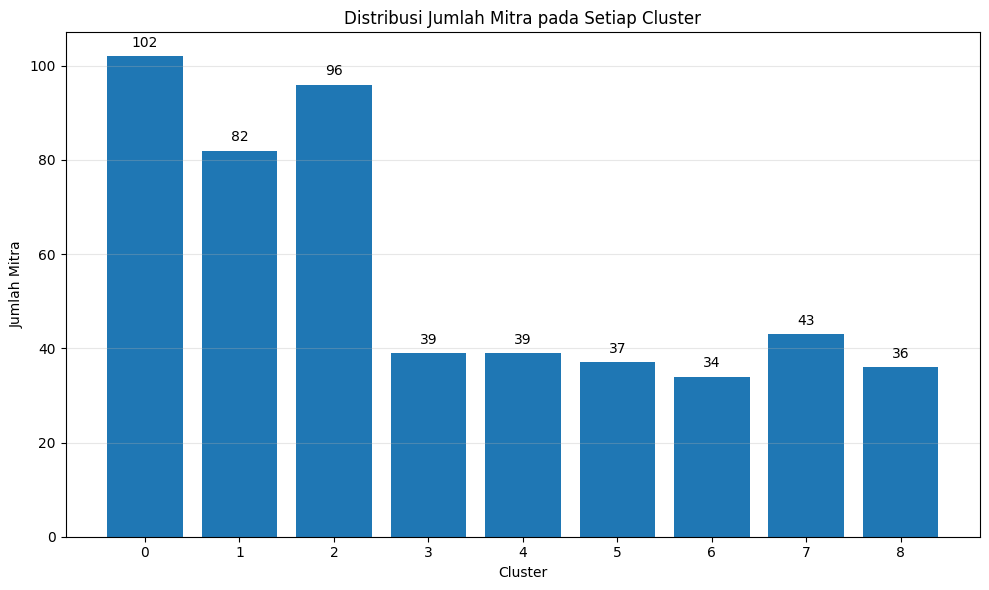

In [178]:
# ============================================================
# CELL 71 — JUMLAH MITRA PADA SETIAP CLUSTER
# ============================================================

plt.figure(figsize=(10, 6)) # Membuat kanvas grafik baru dengan ukuran lebar 10 inci dan tinggi 6 inci

bars = plt.bar(             # Membuat diagram batang (bar chart) untuk distribusi jumlah mitra per kluster
    profil_final['CLUSTER'].astype(str),
    profil_final['Jumlah Mitra']
)

plt.xlabel('Cluster')       # Memberikan label keterangan pada sumbu X
plt.ylabel('Jumlah Mitra')  # Memberikan label keterangan pada sumbu Y
plt.title('Distribusi Jumlah Mitra pada Setiap Cluster') # Memberikan judul utama pada grafik

# Tampilkan jumlah di atas batang
for bar in bars:            # Melakukan perulangan untuk menempatkan teks angka nilai tinggi di atas setiap batang
    tinggi = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        tinggi + 2,
        f'{int(tinggi)}',
        ha='center'
    )

plt.grid(axis='y', alpha=0.3) # Menampilkan garis latar belakang grid horizontal dengan transparansi 0.3
plt.tight_layout()          # Menyesuaikan tata letak grafik agar rapi secara proporsional
plt.show()                  # Menampilkan dan merender grafik ke layar

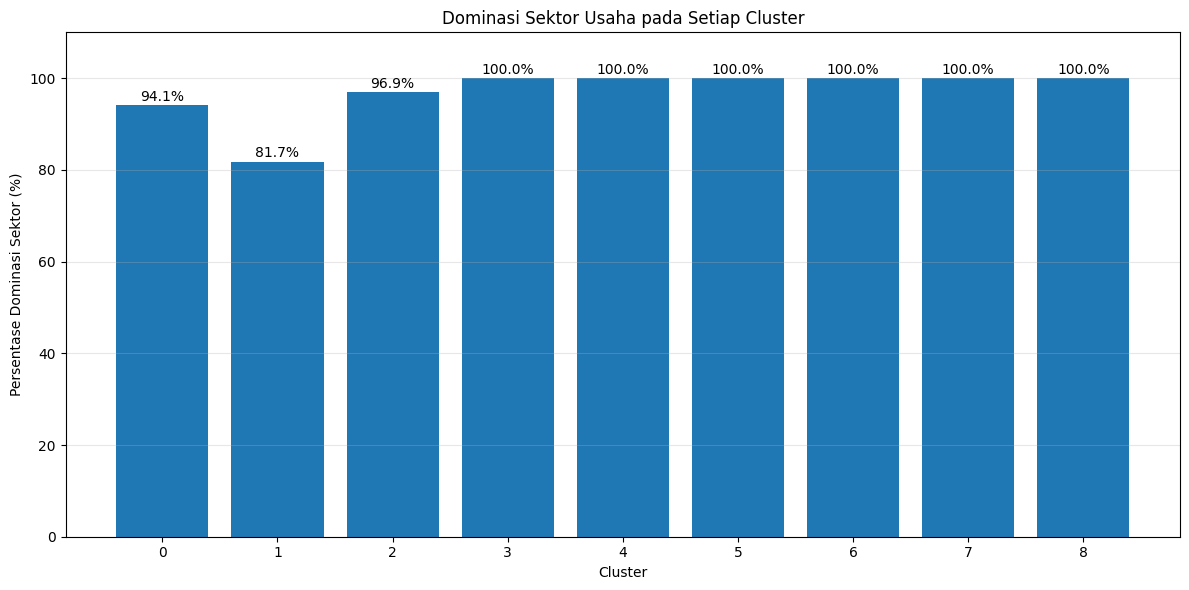

In [179]:
# ============================================================
# CELL 72 — SEKTOR DOMINAN PADA SETIAP CLUSTER
# ============================================================

plt.figure(figsize=(12, 6)) # Membuat kanvas grafik baru dengan ukuran lebar 12 inci dan tinggi 6 inci

bars = plt.bar(             # Membuat diagram batang (bar chart) untuk persentase dominasi sektor per kluster
    profil_final['CLUSTER'].astype(str),
    profil_final['% Sektor Dominan']
)

plt.xlabel('Cluster')       # Memberikan label keterangan pada sumbu X
plt.ylabel('Persentase Dominasi Sektor (%)') # Memberikan label keterangan pada sumbu Y
plt.title('Dominasi Sektor Usaha pada Setiap Cluster') # Memberikan judul utama pada grafik

# Tampilkan persentase
for bar in bars:            # Melakukan perulangan untuk menempatkan teks angka persentase di atas setiap batang
    tinggi = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        tinggi + 1,
        f'{tinggi:.1f}%',
        ha='center'
    )

plt.ylim(0, 110)            # Mengatur batas nilai sumbu Y dari angka 0 hingga 110 agar teks anotasi tidak terpotong
plt.grid(axis='y', alpha=0.3) # Menampilkan garis latar belakang grid horizontal dengan transparansi 0.3
plt.tight_layout()          # Menyesuaikan tata letak grafik agar rapi secara proporsional
plt.show()                  # Menampilkan dan merender grafik ke layar

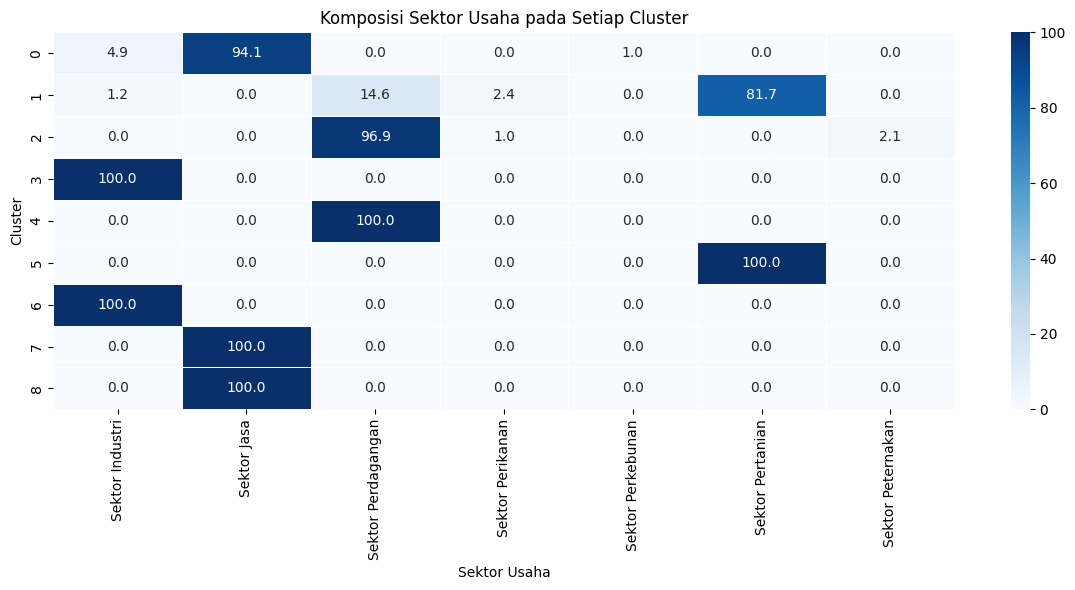

In [180]:
# ============================================================
# CELL 73 — HEATMAP KOMPOSISI SEKTOR PER CLUSTER
# ============================================================

# Menghitung persentase masing-masing sektor di setiap cluster
komposisi_sektor_cluster = pd.crosstab( # Membuat tabel silang persentase sebaran sektor usaha di tiap kluster
    df_model_B['CLUSTER'],
    df_model_B['SEKTOR_ANALISIS'],
    normalize='index'
) * 100

# Membuat heatmap
plt.figure(figsize=(12, 6)) # Membuat kanvas grafik baru berukuran 12x6 inci

sns.heatmap(                # Membuat peta panas (heatmap) untuk visualisasi matriks komposisi sektor
    komposisi_sektor_cluster,
    annot=True,           # Menampilkan angka nilai persentase di dalam kotak sel heatmap
    fmt='.1f',            # Format angka desimal dengan 1 angka di belakang koma
    cmap='Blues',         # Menggunakan palet warna gradasi biru
    linewidths=0.5        # Menambahkan garis pemisah tipis antar sel kotak
)

plt.title('Komposisi Sektor Usaha pada Setiap Cluster') # Memberikan judul utama grafik
plt.xlabel('Sektor Usaha')  # Memberikan label pada sumbu X
plt.ylabel('Cluster')       # Memberikan label pada sumbu Y

plt.tight_layout()          # Menyesuaikan tata letak grafik
plt.show()                  # Menampilkan dan merender grafik ke layar

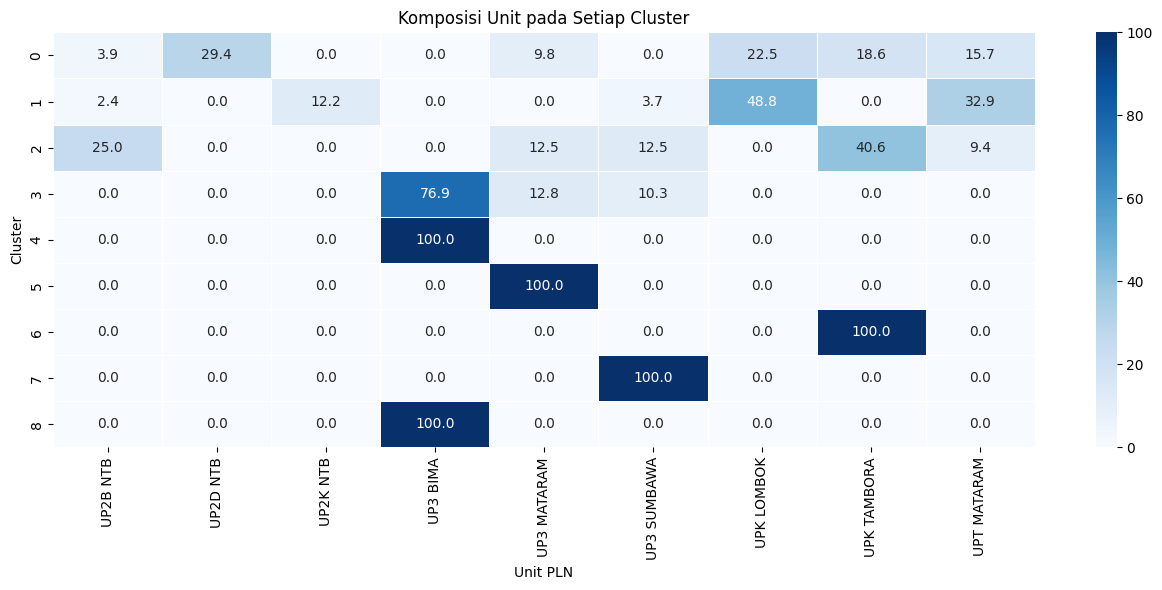

In [181]:
# ============================================================
# CELL 74 — HEATMAP KOMPOSISI UNIT PER CLUSTER
# ============================================================

# Menghitung persentase unit pada setiap cluster
komposisi_unit_cluster = pd.crosstab( # Membuat tabel silang persentase sebaran unit PLN di tiap kluster
    df_model_B['CLUSTER'],
    df_model_B['UNIT_ANALISIS'],
    normalize='index'
) * 100

# Membuat heatmap
plt.figure(figsize=(13, 6)) # Membuat kanvas grafik baru berukuran 13x6 inci

sns.heatmap(                # Membuat peta panas (heatmap) untuk visualisasi komposisi unit PLN
    komposisi_unit_cluster,
    annot=True,           # Menampilkan angka nilai persentase di dalam kotak sel
    fmt='.1f',            # Format angka desimal 1 digit
    cmap='Blues',         # Palet warna gradasi biru
    linewidths=0.5        # Garis pemisah tipis antar sel
)

plt.title('Komposisi Unit pada Setiap Cluster') # Memberikan judul utama grafik
plt.xlabel('Unit PLN')      # Memberikan label pada sumbu X
plt.ylabel('Cluster')       # Memberikan label pada sumbu Y

plt.tight_layout()          # Menyesuaikan tata letak grafik
plt.show()                  # Menampilkan dan merender grafik ke layar

In [182]:
# ============================================================
# CELL 75 — VALIDASI FINAL MODEL K-MODES K=9
# ============================================================

# Prediksi final menggunakan model yang sudah dibuat
labels_final = kmodes_model_B.labels_ # Mengambil label kluster akhir dari model K-Modes Model B

# Hitung silhouette final
silhouette_final = silhouette_score( # Menghitung skor siluet akhir menggunakan jarak Hamming
    X_model_B_silhouette,
    labels_final,
    metric='hamming'
)

# Cost final
cost_final = kmodes_model_B.cost_ # Mengambil nilai cost akhir dari model K-Modes

print("VALIDASI FINAL K-MODES") # Mencetak teks judul laporan validasi ke konsol
print("=" * 50)             # Mencetak garis pemisah estetika
print(f"Jumlah Cluster (K) : 9") # Menampilkan jumlah kluster K final
print(f"Jumlah Data        : {len(X_model_B)}") # Menampilkan total jumlah baris data sampel
print(f"Silhouette Score    : {silhouette_final:.4f}") # Menampilkan skor siluet akhir dengan 4 desimal
print(f"Cost K-Modes        : {cost_final:.2f}") # Menampilkan nilai cost akhir model

VALIDASI FINAL K-MODES
Jumlah Cluster (K) : 9
Jumlah Data        : 508
Silhouette Score    : 0.4918
Cost K-Modes        : 204.00


In [183]:
# ============================================================
# CELL 76 — MENAMBAHKAN LABEL CLUSTER KE DATA UTAMA
# ============================================================

# Buat salinan data utama
df_hasil_cluster = df_clean.copy() # Membuat salinan DataFrame bersih utama agar data asli aman

# Tambahkan hasil clustering K-Modes
df_hasil_cluster['CLUSTER'] = labels_final # Menyimpan hasil label kluster akhir ke dalam kolom baru bernama "CLUSTER"

# Tampilkan beberapa data pertama
df_hasil_cluster.head()     # Menampilkan 5 baris pertama DataFrame hasil penggabungan label kluster

,NO URUT,NO ID,NAMA MITRA BINAAN,KONDITE,NAMA USAHA,ALAMAT,LOKASI,NO TELEPON,JENIS USAHA,TAHUN SALUR,TITIK KOORDINAT,PINJAMAN,Unnamed: 12,UNIT,NOMER VIRTUAL ACCOUNT,LINK DOKUMEN PKS,PELUNASAN,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,USULAN MUTASI PIUTANG BERMASALAH,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,USULAN HAPUS BUKU,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,USULAN HAPUS TAGIH,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,STATUS AKHIR MITRA BINAAN,CETAK,SEKTOR_ANALISIS,LOKASI_ANALISIS,UNIT_ANALISIS,CLUSTER
0,1.0,20-03-023/94,MEBEL YUDHA PUTRA,Normal,MEBEL YUDHA PUTRA,DESA RONTU BIMA,BIMA,NaN,Sektor Industri,1994,NaN,5000000,200000,UP3 BIMA,9880075320031201,NaN,1250000,50000,3750000,150000,3900000,1996-04-29 00:00:00,Macet,DITEMUKAN,-,-,NaN,Pengajuan dari UP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,1.0,Sektor Industri,BIMA,UP3 BIMA,3
1,2.0,20-03-059/95,MEUBEL KAYU LESTARI,Normal,MEUBEL KAYU LESTARI,KEL NAE RT05/02 BIMA,BIMA,NaN,Sektor Industri,1995,NaN,5000000,200000,UP3 BIMA,9880075320031202,NaN,0,0,5000000,200000,5200000,1995-03-20 00:00:00,Macet,DITEMUKAN,-,-,NaN,Pengajuan dari UP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,2.0,Sektor Industri,BIMA,UP3 BIMA,3
2,3.0,20-03-060/95,MEUBEL KAYU RANGGA PUTRA,Normal,MEUBEL KAYU RANGGA PUTRA,DESA JATIBARU,BIMA,NaN,Sektor Industri,1995,NaN,5000000,200000,UP3 BIMA,9880075320031203,NaN,0,0,5000000,200000,5200000,1995-03-20 00:00:00,Macet,DITEMUKAN,-,-,NaN,Pengajuan dari UP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,3.0,Sektor Industri,BIMA,UP3 BIMA,3
3,4.0,20-03-062/95,MEUBEL KAYU SUMBER REJEKI,Normal,MEUBEL KAYU SUMBER REJEKI,JL PAHLAWAN RT19/06 KP DARA,BIMA,NaN,Sektor Industri,1995,NaN,5000000,200000,UP3 BIMA,9880075320031204,NaN,5000000,200000,0,0,0,NaN,Lunas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lunas,4.0,Sektor Industri,BIMA,UP3 BIMA,3
4,5.0,20-03-083/95,UPPKS TENUN MELATI,Normal,UPPKS TENUN MELATI,DS RENDA RT06/03 KEC BELO,BIMA,NaN,Sektor Industri,1995,NaN,5000000,200000,UP3 BIMA,9880075320031205,NaN,3414500,150000,1585500,50000,1635500,1998-07-16 00:00:00,Macet,DITEMUKAN,-,-,NaN,Pengajuan dari UP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,5.0,Sektor Industri,BIMA,UP3 BIMA,3


In [184]:
# ============================================================
# CELL 77 — VALIDASI DATA HASIL CLUSTERING
# ============================================================

print("Jumlah data sebelum clustering :", len(df_clean)) # Mencetak total baris data sebelum proses kluster
print("Jumlah data setelah clustering :", len(df_hasil_cluster)) # Mencetak total baris data setelah proses kluster

print("\nJumlah missing pada CLUSTER:") # Mencetak label pemeriksaan nilai kosong (missing value)
print(df_hasil_cluster['CLUSTER'].isna().sum()) # Menghitung total nilai kosong pada kolom CLUSTER

print("\nJumlah cluster yang terbentuk:") # Mencetak label jumlah kluster unik
print(df_hasil_cluster['CLUSTER'].nunique()) # Menghitung jumlah kategori unik pada kolom CLUSTER

print("\nDistribusi cluster:") # Mencetak label ringkasan sebaran data per kluster
print(df_hasil_cluster['CLUSTER'].value_counts().sort_index()) # Menampilkan rincian jumlah anggota di setiap kluster terurut

Jumlah data sebelum clustering : 508
Jumlah data setelah clustering : 508

Jumlah missing pada CLUSTER:
0

Jumlah cluster yang terbentuk:
9

Distribusi cluster:
CLUSTER
0    102
1     82
2     96
3     39
4     39
5     37
6     34
7     43
8     36
Name: count, dtype: int64


In [185]:
# ============================================================
# CELL 78 — TABEL HASIL SEGMENTASI MITRA
# ============================================================

kolom_hasil = [             # Menentukan daftar kolom penting yang akan ditampilkan pada tabel hasil akhir
    'NAMA USAHA',
    'SEKTOR_ANALISIS',
    'UNIT_ANALISIS',
    'LOKASI_ANALISIS',
    'TAHUN SALUR',
    'CLUSTER'
]

df_segmentasi_final = df_hasil_cluster[kolom_hasil].copy() # Menyalin kolom yang dipilih ke DataFrame baru

# Urutkan berdasarkan cluster
df_segmentasi_final = df_segmentasi_final.sort_values( # Mengurutkan baris data berdasarkan nomor kluster lalu sektor analisis
    by=['CLUSTER', 'SEKTOR_ANALISIS']
).reset_index(drop=True)

# Tampilkan hasil
display(df_segmentasi_final.head(20)) # Menampilkan 20 baris pertama tabel segmentasi final ke layar

,NAMA USAHA,SEKTOR_ANALISIS,UNIT_ANALISIS,LOKASI_ANALISIS,TAHUN SALUR,CLUSTER
0,KONVEKSI RINJANI INDAH,Sektor Industri,UP2D NTB,KOTA MATARAM,1996,0
1,LALU KERTAJAYA,Sektor Industri,UP2D NTB,KOTA MATARAM,2009,0
2,PENGRAJIN KAYU DEDY YUSUF,Sektor Industri,UP2D NTB,KOTA MATARAM,2010,0
3,CAP SIKAT,Sektor Industri,UP2D NTB,KOTA MATARAM,2010,0
4,PETI ANTIK PENIMBUNG,Sektor Industri,UP2D NTB,KOTA MATARAM,2010,0
5,KOPINKRA TUNGGAL ONJO,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0
6,PRESIDENT TAYLOR,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0
7,ALFA COMPUTER,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0
8,PERCETAKAN SOLWIN,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0
9,SERVICE DINAMO SENTRAL/ Service Diamon Sentral,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0


In [186]:
# ============================================================
# CELL 79 — DISTRIBUSI CLUSTER BERDASARKAN TAHUN
# ============================================================

# Membuat tabel jumlah mitra berdasarkan tahun dan cluster
cluster_tahun = pd.crosstab( # Membuat tabel kontingensi frekuensi jumlah mitra antara tahun salur dan nomor kluster
    df_hasil_cluster['TAHUN SALUR'],
    df_hasil_cluster['CLUSTER']
)

# Urutkan berdasarkan tahun
cluster_tahun = cluster_tahun.sort_index() # Mengurutkan baris tabel berdasarkan urutan tahun dari yang paling awal

# Tampilkan tabel
display(cluster_tahun)      # Menampilkan tabel sebaran tahun dan kluster ke layar

CLUSTER,0,1,2,3,4,5,6,7,8
TAHUN SALUR,,,,,,,,,
1993,3,0,0,1,0,0,1,0,3
1994,4,0,4,3,2,0,2,7,4
1995,2,0,6,7,1,0,10,2,7
1996,23,48,15,12,10,19,14,13,8
1997,9,1,15,5,6,0,2,10,6
1998,18,9,5,0,0,12,0,4,0
1999,0,12,2,1,0,6,0,1,0
2000,5,2,7,1,5,0,0,0,1
2001,5,0,3,0,0,0,0,0,0


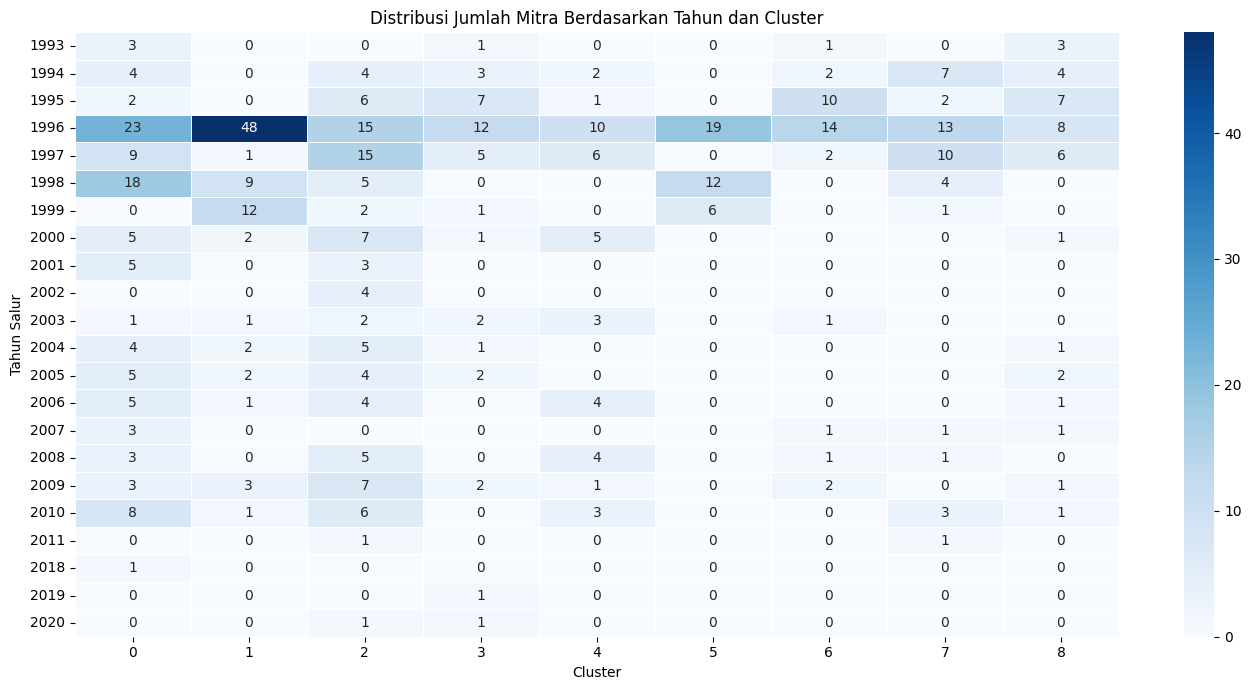

In [187]:
# ============================================================
# CELL 80 — HEATMAP CLUSTER BERDASARKAN TAHUN
# ============================================================

plt.figure(figsize=(14, 7)) # Membuat kanvas grafik baru berukuran 14x7 inci

sns.heatmap(                # Membuat peta panas (heatmap) sebaran mitra berdasarkan tahun dan kluster
    cluster_tahun,
    annot=True,           # Menampilkan angka jumlah data di dalam kotak sel
    fmt='d',              # Format angka bilangan bulat (integer)
    cmap='Blues',         # Palet warna gradasi biru
    linewidths=0.5        # Garis pemisah tipis antar sel
)

plt.title('Distribusi Jumlah Mitra Berdasarkan Tahun dan Cluster') # Memberikan judul utama grafik
plt.xlabel('Cluster')       # Memberikan label pada sumbu X
plt.ylabel('Tahun Salur')   # Memberikan label pada sumbu Y

plt.tight_layout()          # Menyesuaikan tata letak grafik
plt.show()                  # Menampilkan dan merender grafik ke layar

In [188]:
# ============================================================
# CELL 81 — MELENGKAPI TAHUN TANPA MITRA DENGAN NILAI 0
# ============================================================

# Membuat rentang tahun lengkap
tahun_lengkap = range(1993, 2021) # Mendefinisikan rentang urutan tahun lengkap dari tahun 1993 sampai 2020

# Rekonstruksi tabel tahun x cluster
cluster_tahun_lengkap = (   # Melakukan reindeksasi agar seluruh tahun dalam rentang muncul dan tahun kosong diisi angka 0
    cluster_tahun
    .reindex(tahun_lengkap, fill_value=0)
)

# Pastikan nilai berupa integer
cluster_tahun_lengkap = cluster_tahun_lengkap.astype(int) # Mengubah seluruh tipe data angka sel menjadi integer

# Tampilkan
display(cluster_tahun_lengkap) # Menampilkan tabel lengkap berisis angka 0 untuk tahun tanpa data ke layar

CLUSTER,0,1,2,3,4,5,6,7,8
TAHUN SALUR,,,,,,,,,
1993,3,0,0,1,0,0,1,0,3
1994,4,0,4,3,2,0,2,7,4
1995,2,0,6,7,1,0,10,2,7
1996,23,48,15,12,10,19,14,13,8
1997,9,1,15,5,6,0,2,10,6
1998,18,9,5,0,0,12,0,4,0
1999,0,12,2,1,0,6,0,1,0
2000,5,2,7,1,5,0,0,0,1
2001,5,0,3,0,0,0,0,0,0


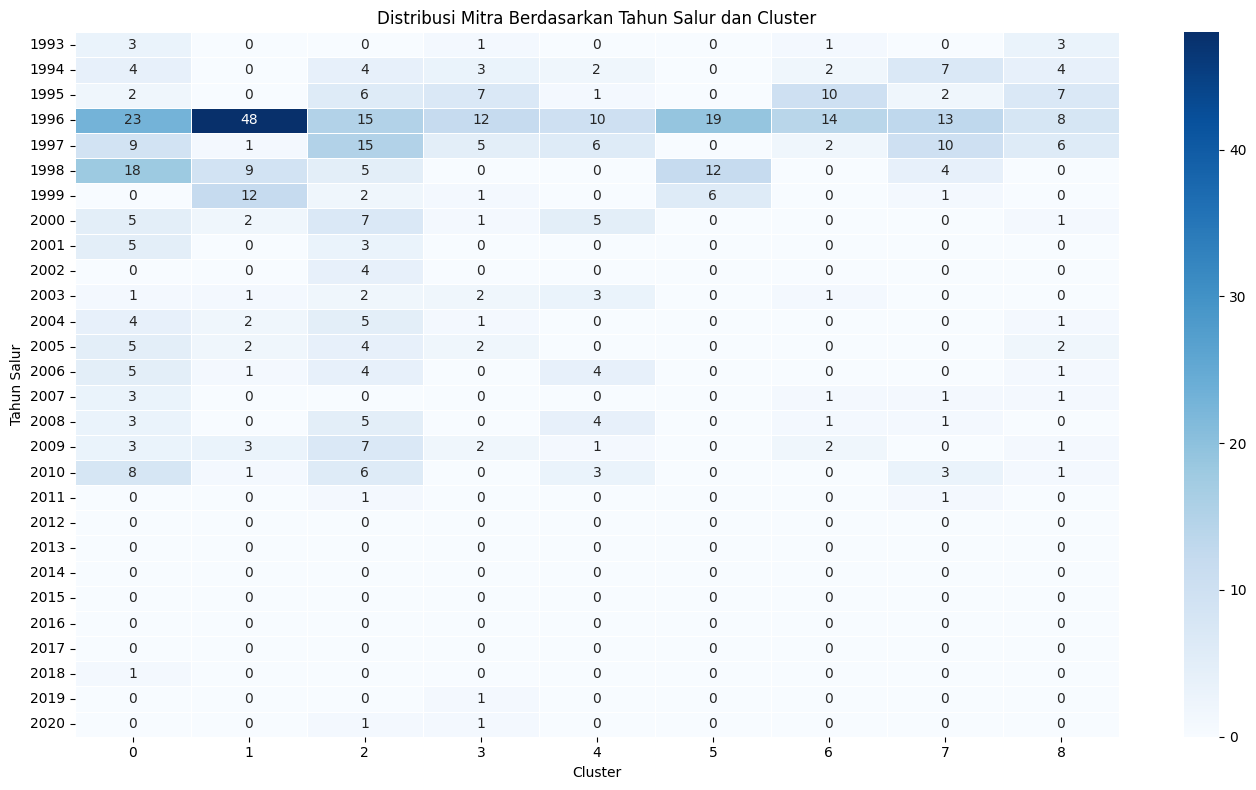

In [189]:
# ============================================================
# CELL 82 — HEATMAP TAHUN × CLUSTER LENGKAP
# ============================================================

plt.figure(figsize=(14, 8)) # Membuat kanvas grafik baru berukuran 14x8 inci

sns.heatmap(                # Membuat peta panas (heatmap) lengkap dengan rentang tahun penuh
    cluster_tahun_lengkap,
    annot=True,           # Menampilkan angka jumlah data di dalam sel
    fmt='d',              # Format angka bilangan bulat
    cmap='Blues',         # Palet warna gradasi biru
    linewidths=0.5        # Garis pemisah tipis antar sel
)

plt.title(                  # Memberikan judul utama grafik komprehensif
    'Distribusi Mitra Berdasarkan Tahun Salur dan Cluster'
)
plt.xlabel('Cluster')       # Memberikan label pada sumbu X
plt.ylabel('Tahun Salur')   # Memberikan label pada sumbu Y

plt.tight_layout()          # Menyesuaikan tata letak grafik
plt.show()                  # Menampilkan dan merender grafik ke layar

In [190]:
# ============================================================
# CELL 83 — NAMA / DESKRIPSI SETIAP CLUSTER
# ============================================================

# Membuat nama deskriptif berdasarkan karakteristik utama
nama_cluster = {            # Mendefinisikan kamus (dictionary) pemetaan nomor kluster ke nama segmen deskriptif
    0: 'Segmen Jasa - Unit Tersebar',
    1: 'Segmen Pertanian - UPK Lombok',
    2: 'Segmen Perdagangan - UPK Tambora',
    3: 'Segmen Industri - UP3 Bima',
    4: 'Segmen Perdagangan - UP3 Bima',
    5: 'Segmen Pertanian - UP3 Mataram',
    6: 'Segmen Industri - UPK Tambora',
    7: 'Segmen Jasa - UP3 Sumbawa',
    8: 'Segmen Jasa - UP3 Bima'
}

# Tambahkan nama cluster ke data hasil
df_segmentasi_final['NAMA_CLUSTER'] = ( # Menambahkan kolom baru berisi nama segmen berdasarkan pemetaan kamus di atas
    df_segmentasi_final['CLUSTER']
    .map(nama_cluster)
)

# Tampilkan beberapa data
display(df_segmentasi_final.head(20)) # Menampilkan 20 baris pertama DataFrame segmentasi final ke layar

,NAMA USAHA,SEKTOR_ANALISIS,UNIT_ANALISIS,LOKASI_ANALISIS,TAHUN SALUR,CLUSTER,NAMA_CLUSTER
0,KONVEKSI RINJANI INDAH,Sektor Industri,UP2D NTB,KOTA MATARAM,1996,0,Segmen Jasa - Unit Tersebar
1,LALU KERTAJAYA,Sektor Industri,UP2D NTB,KOTA MATARAM,2009,0,Segmen Jasa - Unit Tersebar
2,PENGRAJIN KAYU DEDY YUSUF,Sektor Industri,UP2D NTB,KOTA MATARAM,2010,0,Segmen Jasa - Unit Tersebar
3,CAP SIKAT,Sektor Industri,UP2D NTB,KOTA MATARAM,2010,0,Segmen Jasa - Unit Tersebar
4,PETI ANTIK PENIMBUNG,Sektor Industri,UP2D NTB,KOTA MATARAM,2010,0,Segmen Jasa - Unit Tersebar
5,KOPINKRA TUNGGAL ONJO,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0,Segmen Jasa - Unit Tersebar
6,PRESIDENT TAYLOR,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0,Segmen Jasa - Unit Tersebar
7,ALFA COMPUTER,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0,Segmen Jasa - Unit Tersebar
8,PERCETAKAN SOLWIN,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0,Segmen Jasa - Unit Tersebar
9,SERVICE DINAMO SENTRAL/ Service Diamon Sentral,Sektor Jasa,UP2D NTB,KOTA MATARAM,1996,0,Segmen Jasa - Unit Tersebar


In [191]:
# ============================================================
# CELL 84 — TABEL FINAL PROFIL CLUSTER
# ============================================================

# Salin tabel profil sebelumnya
tabel_cluster_final = profil_final.copy() # Menyalin DataFrame tabel profil final kluster sebelumnya

# Tambahkan nama/deskripsi cluster
tabel_cluster_final['Nama Segmen'] = ( # Menambahkan kolom nama segmen deskriptif ke tabel profil
    tabel_cluster_final['CLUSTER'].map(nama_cluster)
)

# Susun urutan kolom
tabel_cluster_final = tabel_cluster_final[ # Mengatur ulang susunan kolom agar kolom nama segmen berada di depan
    [
        'CLUSTER',
        'Nama Segmen',
        'Jumlah Mitra',
        'Persentase Cluster (%)',
        'Sektor Dominan',
        '% Sektor Dominan',
        'Unit Dominan',
        '% Unit Dominan',
        'Lokasi Dominan',
        '% Lokasi Dominan',
        'Tahun Min',
        'Tahun Maks',
        'Median Tahun'
    ]
]

# Tampilkan tabel
display(tabel_cluster_final) # Menampilkan tabel profil final lengkap ke layar

,CLUSTER,Nama Segmen,Jumlah Mitra,Persentase Cluster (%),Sektor Dominan,% Sektor Dominan,Unit Dominan,% Unit Dominan,Lokasi Dominan,% Lokasi Dominan,Tahun Min,Tahun Maks,Median Tahun
0,0,Segmen Jasa - Unit Tersebar,102,20.08,Sektor Jasa,94.12,UP2D NTB,29.41,KOTA MATARAM,33.33,1993,2018,1998.0
1,1,Segmen Pertanian - UPK Lombok,82,16.14,Sektor Pertanian,81.71,UPK LOMBOK,48.78,LOMBOK TENGAH,32.93,1996,2010,1996.0
2,2,Segmen Perdagangan - UPK Tambora,96,18.90,Sektor Perdagangan,96.88,UPK TAMBORA,40.62,KOTA MATARAM,26.04,1994,2020,2000.0
3,3,Segmen Industri - UP3 Bima,39,7.68,Sektor Industri,100.00,UP3 BIMA,76.92,BIMA,41.03,1993,2020,1996.0
4,4,Segmen Perdagangan - UP3 Bima,39,7.68,Sektor Perdagangan,100.00,UP3 BIMA,100.00,KOTA BIMA,79.49,1994,2010,2000.0
5,5,Segmen Pertanian - UP3 Mataram,37,7.28,Sektor Pertanian,100.00,UP3 MATARAM,100.00,LOMBOK BARAT,89.19,1996,1999,1996.0
6,6,Segmen Industri - UPK Tambora,34,6.69,Sektor Industri,100.00,UPK TAMBORA,100.00,DOMPU,41.18,1993,2009,1996.0
7,7,Segmen Jasa - UP3 Sumbawa,43,8.46,Sektor Jasa,100.00,UP3 SUMBAWA,100.00,SUMBAWA,100.00,1994,2011,1996.0
8,8,Segmen Jasa - UP3 Bima,36,7.09,Sektor Jasa,100.00,UP3 BIMA,100.00,KOTA BIMA,88.89,1993,2010,1996.0


In [192]:
# ============================================================
# CELL 85 — REKAP RINGKAS CLUSTER
# ============================================================

rekap_cluster = tabel_cluster_final[ # Menyaring kolom penting tertentu untuk membuat tabel rekap ringkas
    [
        'CLUSTER',
        'Nama Segmen',
        'Jumlah Mitra',
        'Persentase Cluster (%)',
        'Sektor Dominan',
        'Unit Dominan',
        'Lokasi Dominan'
    ]
].copy()

display(rekap_cluster)      # Menampilkan tabel rekap ringkas ke layar

,CLUSTER,Nama Segmen,Jumlah Mitra,Persentase Cluster (%),Sektor Dominan,Unit Dominan,Lokasi Dominan
0,0,Segmen Jasa - Unit Tersebar,102,20.08,Sektor Jasa,UP2D NTB,KOTA MATARAM
1,1,Segmen Pertanian - UPK Lombok,82,16.14,Sektor Pertanian,UPK LOMBOK,LOMBOK TENGAH
2,2,Segmen Perdagangan - UPK Tambora,96,18.90,Sektor Perdagangan,UPK TAMBORA,KOTA MATARAM
3,3,Segmen Industri - UP3 Bima,39,7.68,Sektor Industri,UP3 BIMA,BIMA
4,4,Segmen Perdagangan - UP3 Bima,39,7.68,Sektor Perdagangan,UP3 BIMA,KOTA BIMA
5,5,Segmen Pertanian - UP3 Mataram,37,7.28,Sektor Pertanian,UP3 MATARAM,LOMBOK BARAT
6,6,Segmen Industri - UPK Tambora,34,6.69,Sektor Industri,UPK TAMBORA,DOMPU
7,7,Segmen Jasa - UP3 Sumbawa,43,8.46,Sektor Jasa,UP3 SUMBAWA,SUMBAWA
8,8,Segmen Jasa - UP3 Bima,36,7.09,Sektor Jasa,UP3 BIMA,KOTA BIMA


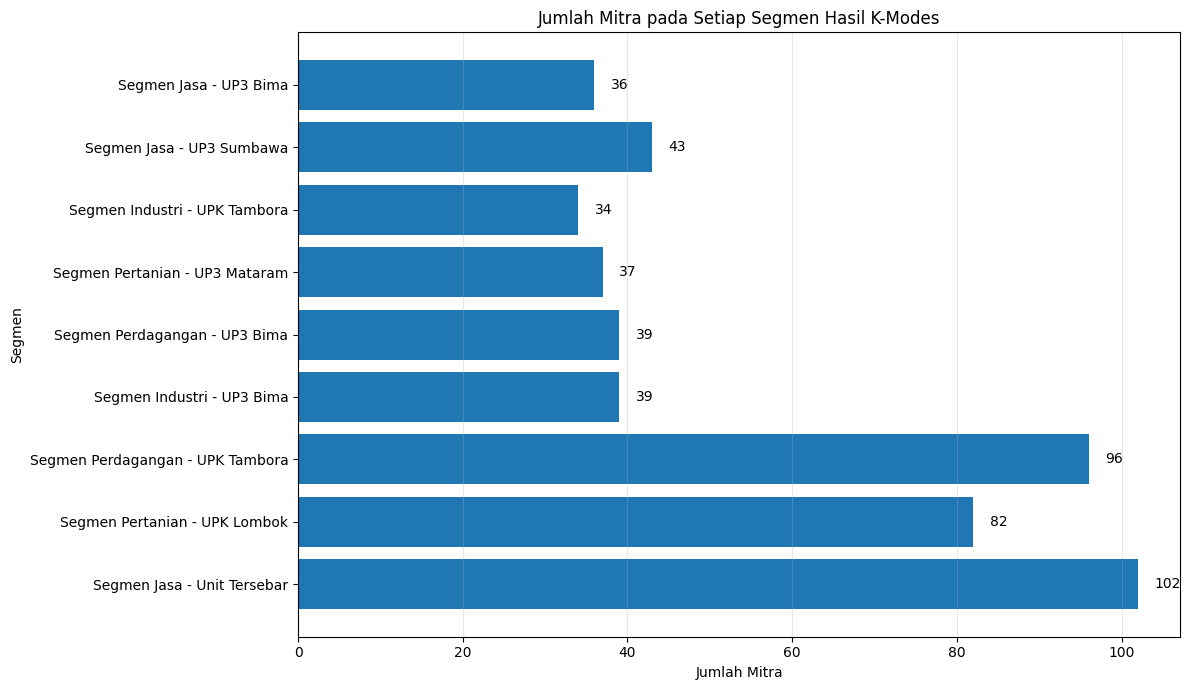

In [193]:
# ============================================================
# CELL 86 — VISUALISASI JUMLAH MITRA PER SEGMEN
# ============================================================

plt.figure(figsize=(12, 7)) # Membuat kanvas grafik horizontal baru berukuran 12x7 inci

bars = plt.barh(            # Membuat diagram batang horizontal (horizontal bar chart) untuk jumlah mitra per segmen
    rekap_cluster['Nama Segmen'],
    rekap_cluster['Jumlah Mitra']
)

plt.xlabel('Jumlah Mitra')  # Memberikan label keterangan pada sumbu X
plt.ylabel('Segmen')        # Memberikan label keterangan pada sumbu Y
plt.title('Jumlah Mitra pada Setiap Segmen Hasil K-Modes') # Memberikan judul utama grafik

# Tampilkan jumlah pada setiap batang
for bar in bars:            # Melakukan perulangan untuk menempatkan teks angka jumlah mitra di ujung batang horizontal
    lebar = bar.get_width()

    plt.text(
        lebar + 2,
        bar.get_y() + bar.get_height() / 2,
        str(int(lebar)),
        va='center'
    )

plt.grid(axis='x', alpha=0.3) # Menampilkan garis latar belakang grid vertikal dengan transparansi 0.3
plt.tight_layout()          # Menyesuaikan tata letak grafik
plt.show()                  # Menampilkan dan merender grafik ke layar

In [194]:
# ============================================================
# CELL 87 — EXPORT HASIL SEGMENTASI
# ============================================================

# Tambahkan nama cluster ke data utama
df_hasil_akhir = df_hasil_cluster.copy() # Membuat salinan DataFrame hasil kluster utama

df_hasil_akhir['NAMA_CLUSTER'] = ( # Menambahkan kolom nama kluster deskriptif
    df_hasil_akhir['CLUSTER']
    .map(nama_cluster)
)

# Kolom yang relevan untuk output penelitian
kolom_export = [            # Menentukan daftar kolom lengkap yang akan diekspor ke file Excel
    'NO URUT',
    'NO ID',
    'NAMA USAHA',
    'JENIS USAHA',
    'TAHUN SALUR',
    'UNIT',
    'LOKASI',
    'SEKTOR_ANALISIS',
    'UNIT_ANALISIS',
    'LOKASI_ANALISIS',
    'CLUSTER',
    'NAMA_CLUSTER'
]

df_export = df_hasil_akhir[kolom_export].copy() # Menyalin kolom yang akan diekspor

# Simpan ke Excel
nama_file = 'HASIL_SEGMENTASI_KMODES_PUMK.xlsx' # Menentukan nama file keluaran spreadsheet Excel

df_export.to_excel(         # Menyimpan DataFrame ke dalam file format Excel tanpa menyertakan indeks baris
    nama_file,
    index=False
)

print(f"File berhasil disimpan: {nama_file}") # Mencetak pesan konfirmasi keberhasilan penyimpanan file

File berhasil disimpan: HASIL_SEGMENTASI_KMODES_PUMK.xlsx


In [195]:
# ============================================================
# CELL 88 — PERBANDINGAN MODEL K-MODES
# ============================================================

# Ringkasan performa model yang sudah diuji
perbandingan_model = pd.DataFrame({ # Membuat DataFrame perbandingan performa antar Model A, Model B, dan Model C
    'Model': [
        'Model A',
        'Model B',
        'Model C'
    ],
    'Fitur': [
        'Sektor + Lokasi',
        'Sektor + Unit',
        'Sektor + Lokasi + Unit'
    ],
    'K': [
        4,
        9,
        10
    ],
    'Mean Silhouette': [
        0.3843,
        0.4487,
        0.5267
    ],
    'Std Silhouette': [
        0.0480,
        0.0391,
        0.0311
    ],
    'Mean Cost': [
        369.20,
        211.00,
        301.00
    ]
})

display(perbandingan_model) # Menampilkan tabel perbandingan model ke layar

,Model,Fitur,K,Mean Silhouette,Std Silhouette,Mean Cost
0,Model A,Sektor + Lokasi,4,0.3843,0.0480,369.2
1,Model B,Sektor + Unit,9,0.4487,0.0391,211.0
2,Model C,Sektor + Lokasi + Unit,10,0.5267,0.0311,301.0


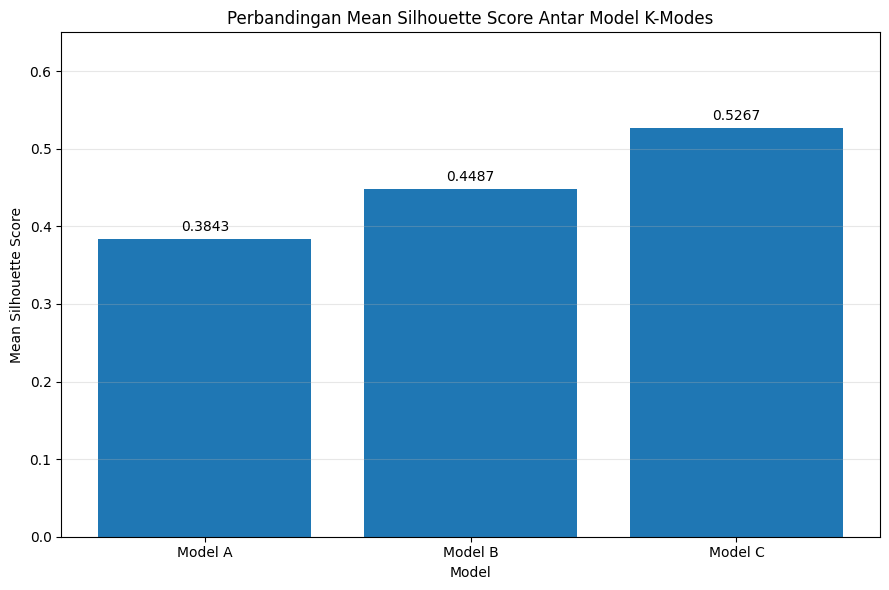

In [196]:
# ============================================================
# CELL 89 — PERBANDINGAN SILHOUETTE ANTAR MODEL
# ============================================================

plt.figure(figsize=(9, 6)) # Membuat kanvas grafik baru berukuran 9x6 inci

bars = plt.bar(             # Membuat diagram batang untuk membandingkan rata-rata skor siluet
    perbandingan_model['Model'],
    perbandingan_model['Mean Silhouette']
)

plt.xlabel('Model')         # Memberikan label pada sumbu X
plt.ylabel('Mean Silhouette Score') # Memberikan label pada sumbu Y
plt.title('Perbandingan Mean Silhouette Score Antar Model K-Modes') # Memberikan judul utama grafik

for bar in bars:            # Melakukan perulangan untuk menampilkan teks nilai desimal di atas batang
    tinggi = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        tinggi + 0.01,
        f'{tinggi:.4f}',
        ha='center'
    )

plt.ylim(0, 0.65)           # Mengatur batas rentang sumbu Y dari 0 sampai 0.65
plt.grid(axis='y', alpha=0.3) # Menampilkan garis grid horizontal
plt.tight_layout()          # Menyesuaikan tata letak grafik
plt.show()                  # Menampilkan dan merender grafik ke layar

In [197]:
# ============================================================
# CELL 90 — RINGKASAN PEMILIHAN MODEL
# ============================================================

print("RINGKASAN PEMILIHAN MODEL") # Mencetak teks judul laporan ringkasan pemilihan model ke konsol
print("=" * 60)             # Mencetak garis pemisah estetika

print("Model yang dipilih : Model B")
print("Fitur              : SEKTOR_ANALISIS + UNIT_ANALISIS")
print("Jumlah cluster     : K = 9")
print("Mean Silhouette     : 0.4487")
print("Std Silhouette      : 0.0391")
print("Mean Cost           : 211.00")
print("Silhouette final    : 0.4918")
print("Cost final          : 204.00")

print("\nAlasan utama:")
print("1. Model B memberikan segmentasi tanpa memasukkan")
print("   LOKASI dan UNIT secara bersamaan.")
print("2. LOKASI dan UNIT memiliki asosiasi sangat kuat")
print("   dengan Cramer's V = 0.8008.")
print("3. Model B memiliki mean silhouette 0.4487 dan")
print("   stabil pada pengujian beberapa random state.")

RINGKASAN PEMILIHAN MODEL
Model yang dipilih : Model B
Fitur              : SEKTOR_ANALISIS + UNIT_ANALISIS
Jumlah cluster     : K = 9
Mean Silhouette     : 0.4487
Std Silhouette      : 0.0391
Mean Cost           : 211.00
Silhouette final    : 0.4918
Cost final          : 204.00

Alasan utama:
1. Model B memberikan segmentasi tanpa memasukkan
   LOKASI dan UNIT secara bersamaan.
2. LOKASI dan UNIT memiliki asosiasi sangat kuat
   dengan Cramer's V = 0.8008.
3. Model B memiliki mean silhouette 0.4487 dan
   stabil pada pengujian beberapa random state.


In [198]:
# ============================================================
# CELL 91 — SINTESIS TREN TAHUNAN + CLUSTER
# ============================================================

# Jumlah mitra per tahun
jumlah_mitra_tahun = (      # Menghitung jumlah total mitra per tahun salur
    df_hasil_cluster
    .groupby('TAHUN SALUR')
    .size()
    .rename('Jumlah Mitra')
)

# Sektor paling dominan setiap tahun
sektor_dominan_tahun = (    # Mencari sektor usaha yang paling sering muncul di tiap tahun salur
    df_hasil_cluster
    .groupby('TAHUN SALUR')['SEKTOR_ANALISIS']
    .agg(lambda x: x.value_counts().idxmax())
    .rename('Sektor Dominan')
)

# Cluster paling dominan setiap tahun
cluster_dominan_tahun = (   # Mencari kluster yang paling dominan di tiap tahun salur
    df_hasil_cluster
    .groupby('TAHUN SALUR')['CLUSTER']
    .agg(lambda x: x.value_counts().idxmax())
    .rename('Cluster Dominan')
)

# Gabungkan hasil
sintesis_tahunan = pd.concat( # Menggabungkan ringkasan tahunan menjadi satu tabel DataFrame
    [
        jumlah_mitra_tahun,
        sektor_dominan_tahun,
        cluster_dominan_tahun
    ],
    axis=1
).reset_index()

# Urutkan berdasarkan tahun
sintesis_tahunan = sintesis_tahunan.sort_values( # Mengurutkan baris berdasarkan urutan tahun salur
    'TAHUN SALUR'
).reset_index(drop=True)

display(sintesis_tahunan)   # Menampilkan tabel sintesis tren tahunan ke layar

,TAHUN SALUR,Jumlah Mitra,Sektor Dominan,Cluster Dominan
0,1993,8,Sektor Jasa,8
1,1994,26,Sektor Jasa,7
2,1995,35,Sektor Industri,6
3,1996,162,Sektor Pertanian,1
4,1997,54,Sektor Jasa,2
5,1998,48,Sektor Jasa,0
6,1999,22,Sektor Pertanian,1
7,2000,21,Sektor Perdagangan,2
8,2001,8,Sektor Jasa,0
9,2002,4,Sektor Perdagangan,2


In [199]:
# ============================================================
# CELL 92 — RINGKASAN STATISTIK TREN
# ============================================================

# Tahun dengan jumlah mitra terbanyak
tahun_puncak = (            # Mencari baris data dengan jumlah mitra terbanyak
    sintesis_tahunan
    .loc[sintesis_tahunan['Jumlah Mitra'].idxmax()]
)

# Tahun dengan jumlah mitra paling sedikit
tahun_terendah = (          # Mencari baris data dengan jumlah mitra paling sedikit
    sintesis_tahunan
    .loc[sintesis_tahunan['Jumlah Mitra'].idxmin()]
)

# Jumlah tahun aktif
tahun_aktif = (             # Menghitung total variasi tahun penyaluran yang aktif
    df_hasil_cluster['TAHUN SALUR']
    .dropna()
    .nunique()
)

# Rentang tahun
tahun_min = int(df_hasil_cluster['TAHUN SALUR'].min()) # Mencari tahun awal (minimum)
tahun_max = int(df_hasil_cluster['TAHUN SALUR'].max()) # Mencari tahun akhir (maksimum)

print("RINGKASAN ANALISIS TREN") # Mencetak teks judul laporan tren ke konsol
print("=" * 60)
print(f"Total mitra              : {len(df_hasil_cluster)}")
print(f"Tahun pertama penyaluran : {tahun_min}")
print(f"Tahun terakhir penyaluran: {tahun_max}")
print(f"Jumlah tahun aktif       : {tahun_aktif}")

print("\nTahun dengan mitra terbanyak:")
print(f"Tahun  : {int(tahun_puncak['TAHUN SALUR'])}")
print(f"Jumlah : {int(tahun_puncak['Jumlah Mitra'])}")

print("\nTahun dengan mitra paling sedikit:")
print(f"Tahun  : {int(tahun_terendah['TAHUN SALUR'])}")
print(f"Jumlah : {int(tahun_terendah['Jumlah Mitra'])}")

RINGKASAN ANALISIS TREN
Total mitra              : 508
Tahun pertama penyaluran : 1993
Tahun terakhir penyaluran: 2020
Jumlah tahun aktif       : 22

Tahun dengan mitra terbanyak:
Tahun  : 1996
Jumlah : 162

Tahun dengan mitra paling sedikit:
Tahun  : 2018
Jumlah : 1


In [200]:
# ============================================================
# CELL 93 — HUBUNGAN SEKTOR DAN CLUSTER
# ============================================================

sektor_cluster = pd.crosstab( # Membuat tabel silang frekuensi hubungan antara sektor usaha dan nomor kluster
    df_hasil_cluster['SEKTOR_ANALISIS'],
    df_hasil_cluster['CLUSTER']
)

display(sektor_cluster)     # Menampilkan tabel silang sektor dan kluster ke layar

CLUSTER,0,1,2,3,4,5,6,7,8
SEKTOR_ANALISIS,,,,,,,,,
Sektor Industri,5,1,0,39,0,0,34,0,0
Sektor Jasa,96,0,0,0,0,0,0,43,36
Sektor Perdagangan,0,12,93,0,39,0,0,0,0
Sektor Perikanan,0,2,1,0,0,0,0,0,0
Sektor Perkebunan,1,0,0,0,0,0,0,0,0
Sektor Pertanian,0,67,0,0,0,37,0,0,0
Sektor Peternakan,0,0,2,0,0,0,0,0,0


In [201]:
# ============================================================
# CELL 94 — PROPORSI CLUSTER DALAM SETIAP SEKTOR
# ============================================================

proporsi_sektor_cluster = ( # Menghitung tabel proporsi persentase kluster di dalam masing-masing sektor usaha
    pd.crosstab(
        df_hasil_cluster['SEKTOR_ANALISIS'],
        df_hasil_cluster['CLUSTER'],
        normalize='index'
    ) * 100
)

display(proporsi_sektor_cluster.round(2)) # Menampilkan tabel proporsi persentase dengan pembulatan 2 desimal ke layar

CLUSTER,0,1,2,3,4,5,6,7,8
SEKTOR_ANALISIS,,,,,,,,,
Sektor Industri,6.33,1.27,0.00,49.37,0.00,0.00,43.04,0.00,0.00
Sektor Jasa,54.86,0.00,0.00,0.00,0.00,0.00,0.00,24.57,20.57
Sektor Perdagangan,0.00,8.33,64.58,0.00,27.08,0.00,0.00,0.00,0.00
Sektor Perikanan,0.00,66.67,33.33,0.00,0.00,0.00,0.00,0.00,0.00
Sektor Perkebunan,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sektor Pertanian,0.00,64.42,0.00,0.00,0.00,35.58,0.00,0.00,0.00
Sektor Peternakan,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00


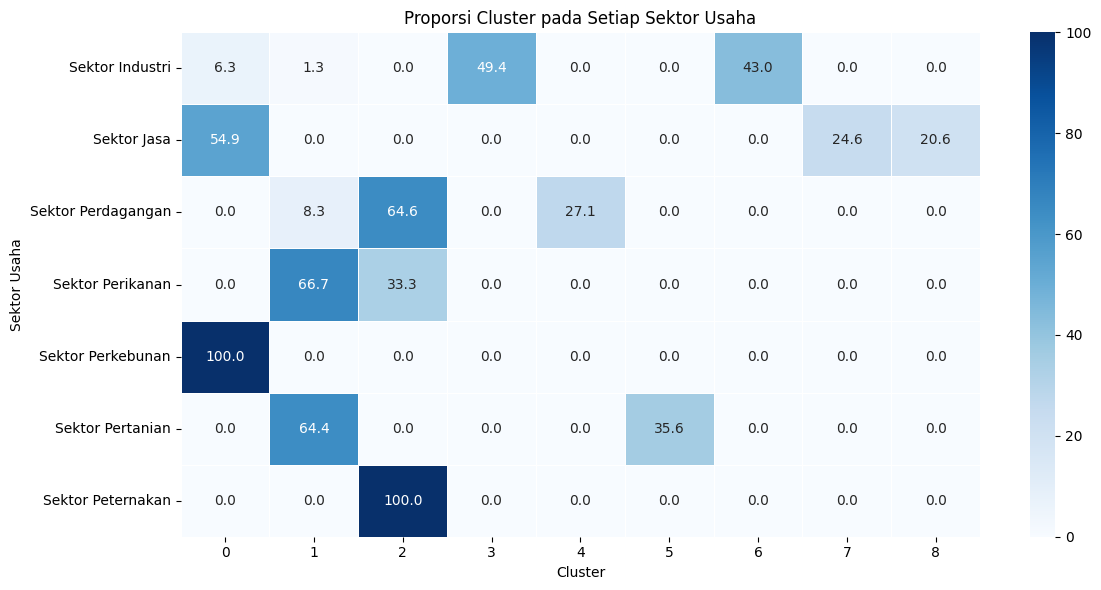

In [202]:
# ============================================================
# CELL 95 — HEATMAP SEKTOR × CLUSTER
# ============================================================

plt.figure(figsize=(12, 6)) # Membuat kanvas grafik baru berukuran 12x6 inci

sns.heatmap(                # Membuat peta panas (heatmap) proporsi sebaran kluster pada setiap sektor usaha
    proporsi_sektor_cluster,
    annot=True,           # Menampilkan angka nilai persentase di dalam sel
    fmt='.1f',            # Format angka desimal 1 digit
    cmap='Blues',         # Palet warna gradasi biru
    linewidths=0.5        # Garis pemisah tipis antar sel
)

plt.title('Proporsi Cluster pada Setiap Sektor Usaha') # Memberikan judul utama grafik
plt.xlabel('Cluster')       # Memberikan label pada sumbu X
plt.ylabel('Sektor Usaha')  # Memberikan label pada sumbu Y

plt.tight_layout()          # Menyesuaikan tata letak grafik
plt.show()                  # Menampilkan dan merender grafik ke layar